## 📊 Structural & Socioeconomic Analysis – Netherlands Dataset

### 💡 Introduction

This notebook presents an exploratory analysis of the Dutch residential building stock, combining **dwelling-level structural characteristics** from the VNG dataset with **PC6-level socioeconomic and energy indicators** from the CBS dataset.

The objective is to:

- Identify relationships between physical dwelling characteristics  
- Map internal dependencies within the housing stock  
- Align structural dwelling data with observed PC6-level electricity and gas consumption  
- Prepare a robust feature architecture for regression modelling of residential energy demand  

The workflow is structured in three stages:

- First, load and align the VNG structural dataset with CBS PC6 data  
- Then, analyze dwelling-level structural characteristics  
- Finally, construct PC6-level composition variables for regression modelling  

This combined approach enables a more comprehensive and interpretable modelling of residential energy demand across the Netherlands.

### 1️⃣ Environment Setup

We use:

- pandas for data handling

- numpy for numerical operations

- matplotlib and seaborn for visualization

In [1]:
import scipy
import statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster

sns.set(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

pandas: 3.0.1
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.0
statsmodels: 0.14.6


## 2️⃣ Read and Filter the National Dwelling Dataset and CBS PC6 Dataset

In this step, two datasets are loaded and prepared:

1. The national dwelling-level structural dataset from DEGO/VNG  
2. The CBS PC6 dataset containing socioeconomic indicators and average energy consumption values  

The VNG dataset is used only for dwelling-level structural characteristics. Electricity and gas consumption are not taken from the VNG dataset, because these variables are instead sourced from the CBS PC6 dataset.

The CBS dataset is used to provide:

- PC6-level socioeconomic and housing-context variables
- average electricity consumption per dwelling
- average gas consumption per dwelling

CBS placeholder values for missing, confidential, or unavailable observations are converted to missing values. Only PC6 areas with reported electricity and gas consumption values are retained in the CBS dataset.

The actual alignment between the VNG and CBS datasets is performed later in Chapter 3, after the dwelling-level structural dataset has been prepared.

### 2.1 National Dwelling Dataset (Structural Housing Data) - DEGO VNG

In this step, we load the national dwelling-level dataset and construct a residential-only structural dataset.

The filtering is applied at two levels:

- Row level: keep observations where  
  - `gebruiksdoelen == "woonfunctie"`  
  - `sbicode` is missing, indicating a residential-only building

- PC6 level: retain only postcode areas where all observations satisfy the residential condition  

This ensures that each retained PC6 represents a purely residential area, which is essential for consistent aggregation and interpretation in later stages.

Only structural dwelling variables are loaded from the VNG dataset. Electricity and gas consumption variables are deliberately excluded, because electricity and gas consumption are taken from the CBS PC6 dataset in Section 2.2.

In [2]:
# ----------------------------
# 2.1 Load and filter structural data (residential-only PC6)
# ----------------------------

file_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\dook_vng_gemeenten_csv\energiedata-match-gemeentecode_NL.csv"
)

sep = ";"

# --- Step 1: identify residential-only PC6 codes (fast pass)

pc6_df = pd.read_csv(
    file_path,
    sep=sep,
    usecols=["postcode", "gebruiksdoelen", "sbicode"],
    dtype=str,
    low_memory=False,
)

pc6_df["is_residential_row"] = (
    pc6_df["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & pc6_df["sbicode"].isna()
)

residential_pc6_mask = pc6_df.groupby("postcode")["is_residential_row"].all()
residential_pc6_codes = residential_pc6_mask[residential_pc6_mask].index

print("Residential-only PC6 codes:", len(residential_pc6_codes))


# --- Step 2: load structural variables for those PC6 only

usecols_structural = [
    "gemeentecode",
    "postcode",
    "sbicode",
    "gebruiksdoelen",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_productie_2023",
]

df_structural = pd.read_csv(
    file_path,
    sep=sep,
    usecols=usecols_structural,
    dtype=str,
    low_memory=False,
)

# keep only residential PC6
df_structural = df_structural[
    df_structural["postcode"].isin(residential_pc6_codes)
].copy()

# enforce residential definition at row level
df_structural = df_structural[
    df_structural["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & df_structural["sbicode"].isna()
].copy()

# --- Step 3: clean and rename to English

df_structural = df_structural.drop(columns=["gebruiksdoelen", "sbicode"])

df_structural = df_structural.rename(columns={
    "gemeentecode": "municipality_code",
    "postcode": "postcode",
    "woning_type": "dwelling_type",
    "oppervlakte": "floor_area",
    "pand_bouwjaar": "building_year",
    "energieklasse": "energy_label",
    "gas_ean_count": "gas_connection_count",
    "p6_kwh_productie_2023": "pc6_electricity_production_2023"
})

# convert numeric columns
df_structural["floor_area"] = pd.to_numeric(df_structural["floor_area"], errors="coerce")
df_structural["building_year"] = pd.to_numeric(df_structural["building_year"], errors="coerce")
df_structural["gas_connection_count"] = pd.to_numeric(df_structural["gas_connection_count"], errors="coerce")
df_structural["pc6_electricity_production_2023"] = pd.to_numeric(
    df_structural["pc6_electricity_production_2023"], errors="coerce"
)

# --- Step 4: keep final columns

final_columns = [
    "municipality_code",
    "postcode",
    "dwelling_type",
    "floor_area",
    "building_year",
    "energy_label",
    "gas_connection_count",
    "pc6_electricity_production_2023",
]

df_structural = df_structural[final_columns].copy()

# --- Output check

print("Residential-only structural dataset")
print("Rows:", len(df_structural))
print("Unique PC6:", df_structural["postcode"].nunique())

df_structural.head()

Residential-only PC6 codes: 261729
Residential-only structural dataset
Rows: 4881410
Unique PC6: 261729


,municipality_code,postcode,dwelling_type,floor_area,building_year,energy_label,gas_connection_count,pc6_electricity_production_2023
0,GM0014,9725CZ,Flatwoning (overig),166.0,2008,A,0,0.0
1,GM0014,9731HJ,NaN,135.0,1981,NaN,1,0.0
2,GM0014,9744BD,NaN,163.0,1912,NaN,1,0.0
3,GM0014,9736CS,Flatwoning (overig),47.0,1982,B,1,0.0
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.0,1970,A,1,0.0


### 2.2 CBS PC6 Dataset (Socioeconomic, Housing Context, Electricity and Gas Consumption)

In this step, we load and prepare the CBS dataset at PC6 level.

The dataset complements the dwelling-level structural data with contextual information on residents, households, housing characteristics, and social security. In addition, CBS provides average residential electricity and gas consumption per dwelling at PC6 level.

Due to the structure of the raw file, the correct header row is specified during loading and non-data rows are excluded. Only the relevant variables are selected in order to keep the dataset focused and computationally efficient.

In the raw CSV, some variables appear under generic labels such as `Totaal` and `Totaal.1`. Based on the CBS documentation, these are mapped to their official meanings.

The selected variables follow the official CBS definitions and naming:

- `Inwoners totaal` - total number of residents
- `Huishoudens totaal` - total number of private households
- `Gemiddelde huishoudgrootte` - average household size
- `Niet bewoonde woningen` - number of unoccupied dwellings
- `Gemiddelde WOZ-waarde woningen` - average WOZ value of dwellings
- `Gemiddeld elektriciteitsverbruik woning` - average electricity consumption per dwelling
- `Gemiddeld gasverbruik woning` - average gas consumption per dwelling
- `Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering` - residents receiving unemployment benefits, social assistance, and/or disability benefits

CBS data uses special placeholder values to encode missing or confidential information:

- `-99997`: 0 to 4 / secret / not present
- `-99995`: subject will be published in a later version

These values do not represent valid observations and are therefore treated as missing values (`NaN`) in the analysis.

Only PC6 areas with valid CBS electricity and gas consumption values are retained. This ensures that the final analysis sample contains only postcode areas for which the dependent energy variables are available from CBS.

In [3]:
# ----------------------------
# 2.2 Load and Prepare CBS PC6 Dataset
# ----------------------------

cbs_file_path = r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\2025-cbs_pc6_2023_v2\pc6_2023_v2.csv"

# use the actual CSV headers, then immediately map them to official CBS meanings
cbs_usecols = [
    "Postcode-6",
    "Totaal",
    "Totaal.1",
    "Huishoudgrootte",
    "Niet bewoond",
    "WOZ-waarde\nwoning",
    "Elektra \nverbruik",
    "Gas\nverbruik",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd"
]

df_cbs_pc6 = pd.read_csv(
    cbs_file_path,
    header=8,
    skiprows=[9],
    usecols=cbs_usecols
)

df_cbs_pc6 = df_cbs_pc6.rename(columns={
    "Postcode-6": "postcode",
    "Totaal": "number_of_inhabitants",
    "Totaal.1": "number_of_private_households",
    "Huishoudgrootte": "average_household_size",
    "Niet bewoond": "number_of_unoccupied_dwellings",
    "WOZ-waarde\nwoning": "average_woz_value_home",
    "Gas\nverbruik": "average_gas_consumption_home",
    "Elektra \nverbruik": "average_electricity_consumption_dwelling",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd":
        "number_of_people_receiving_benefits_below_pension_age"
})

# replace CBS placeholder values with NaN
df_cbs_pc6 = df_cbs_pc6.replace([-99997, -99995], np.nan)

# convert non-postcode columns to numeric
numeric_cols_cbs = [
    "number_of_inhabitants",
    "number_of_private_households",
    "average_household_size",
    "number_of_unoccupied_dwellings",
    "average_woz_value_home",
    "average_gas_consumption_home",
    "average_electricity_consumption_dwelling",
    "number_of_people_receiving_benefits_below_pension_age"
]

df_cbs_pc6[numeric_cols_cbs] = df_cbs_pc6[numeric_cols_cbs].apply(
    pd.to_numeric,
    errors="coerce"
)

print("CBS dataset before energy filtering")
print("Rows:", len(df_cbs_pc6))
print("Unique PC6:", df_cbs_pc6["postcode"].nunique())

# keep only PC6 with valid CBS electricity and gas consumption
df_cbs_pc6 = df_cbs_pc6.dropna(
    subset=[
        "average_electricity_consumption_dwelling",
        "average_gas_consumption_home"
    ]
).copy()

print("\nCBS dataset after filtering to valid electricity and gas values")
print("Rows:", len(df_cbs_pc6))
print("Unique PC6:", df_cbs_pc6["postcode"].nunique())

df_cbs_pc6.head()

CBS dataset before energy filtering
Rows: 464138
Unique PC6: 464138

CBS dataset after filtering to valid electricity and gas values
Rows: 390824
Unique PC6: 390824


,postcode,number_of_inhabitants,number_of_private_households,average_household_size,number_of_unoccupied_dwellings,average_woz_value_home,average_gas_consumption_home,average_electricity_consumption_dwelling,number_of_people_receiving_benefits_below_pension_age
1,1011AC,25.0,15.0,1.5,NaN,794.0,1260.0,2680.0,NaN
5,1011AH,30.0,20.0,1.7,NaN,362.0,810.0,1430.0,NaN
6,1011AJ,20.0,10.0,1.6,NaN,858.0,920.0,2140.0,NaN
9,1011AM,5.0,5.0,1.0,NaN,855.0,1050.0,1740.0,NaN
10,1011AN,40.0,25.0,1.6,NaN,622.0,580.0,2060.0,NaN


## 3️⃣ Preparation of the dwelling-level structural dataset

Before analysing the structural characteristics of the housing stock, the dwelling-level dataset must be prepared to ensure that key variables are consistently formatted, numerically interpretable, and free of obvious data issues.

This preparation step focuses on **structural dwelling features**, which will later be used for exploratory analysis and aggregation to postcode (PC6) level.

Electricity and gas consumption are not handled in this chapter, because these variables are sourced from the CBS PC6 dataset and enter the workflow later at PC6 level.

The preparation consists of four steps:

1. **Standardizing categorical variables**  
   Text-based categorical variables such as dwelling type (`dwelling_type`) and energy label (`energy_label`) are cleaned to ensure consistent formatting and avoid artificial category duplication caused by whitespace or inconsistent strings.

2. **Ensuring numeric variables are correctly formatted**  
   Structural characteristics such as floor area, construction year, gas connection count, and PV production are explicitly converted to numeric format.

3. **Removing implausible observations**  
   Basic plausibility checks are applied to remove clearly invalid structural values, such as missing or non-positive floor areas and construction years that exceed the current year.

4. **Handling categorical availability**  
   Dwellings without a registered energy label are retained and assigned to a dedicated category (`no_label`). Similarly, dwellings without a registered dwelling type are retained and assigned to a dedicated category (`unknown`). This preserves dataset completeness while making missing categorical information explicit.

### 3.1 Structural dataset preparation

In [4]:
# ----------------------------
# 3.1 Structural dataset preparation
# ----------------------------

df_dwelling = df_structural.copy()

# 1) standardize categorical strings
for c in ["dwelling_type", "energy_label"]:
    df_dwelling[c] = df_dwelling[c].astype(str).str.strip()

df_dwelling["dwelling_type"] = df_dwelling["dwelling_type"].replace({"nan": np.nan, "": np.nan})
df_dwelling["energy_label"] = df_dwelling["energy_label"].replace({"nan": np.nan, "": np.nan})

# 2) numeric conversions
num_cols = [
    "floor_area",
    "building_year",
    "gas_connection_count",
    "pc6_electricity_production_2023"
]

for c in num_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# 3) remove implausible structural values
df_dwelling = df_dwelling[df_dwelling["floor_area"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["floor_area"] > 0].copy()

df_dwelling = df_dwelling[df_dwelling["building_year"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["building_year"] <= 2026].copy()

# 4) treat missing categorical values as explicit structural categories
df_dwelling["energy_label"] = df_dwelling["energy_label"].fillna("no_label")
df_dwelling["dwelling_type"] = df_dwelling["dwelling_type"].fillna("unknown")

label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energy_label"] = pd.Categorical(
    df_dwelling["energy_label"],
    categories=label_order,
    ordered=False
)

print("Structural dwelling dataset prepared")
print("Number of dwelling observations:", len(df_dwelling))
print("Number of PC6 areas:", df_dwelling["postcode"].nunique())

df_dwelling.head()

Structural dwelling dataset prepared
Number of dwelling observations: 4881409
Number of PC6 areas: 261729


,municipality_code,postcode,dwelling_type,floor_area,building_year,energy_label,gas_connection_count,pc6_electricity_production_2023
0,GM0014,9725CZ,Flatwoning (overig),166.0,2008,A,0,0.0
1,GM0014,9731HJ,unknown,135.0,1981,no_label,1,0.0
2,GM0014,9744BD,unknown,163.0,1912,no_label,1,0.0
3,GM0014,9736CS,Flatwoning (overig),47.0,1982,B,1,0.0
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.0,1970,A,1,0.0


### 3.2 Alignment of VNG and CBS datasets at PC6 level

After preparing the structural dataset and filtering the CBS dataset to valid energy observations, the next step is to align both datasets at PC6 level.

Both datasets are defined at the PC6 (full postcode) level, but they originate from different sources and may not cover exactly the same set of postcode areas. Therefore, a consistent intersection must be constructed.

The alignment is performed in two steps:

1. **Identification of common PC6 areas**  
   The residential-only PC6 areas from the VNG structural dataset are compared with the PC6 areas available in the CBS dataset.

2. **Construction of a consistent analytical sample**  
   Both the VNG structural dataset and the CBS dataset are restricted to the same final set of PC6 areas.

This ensures that each postcode area used in the analysis contains both structural dwelling characteristics and valid CBS electricity and gas consumption data.

In [5]:
# ----------------------------
# 3.2 PC6 alignment VNG - CBS
# ----------------------------

# Ensure consistent postcode format
df_dwelling["postcode"] = df_dwelling["postcode"].astype(str).str.strip()
df_cbs_pc6["postcode"] = df_cbs_pc6["postcode"].astype(str).str.strip()

# ----------------------------
# 1. Identify common PC6s
# ----------------------------

pc6_vng = set(df_dwelling["postcode"].unique())
pc6_cbs = set(df_cbs_pc6["postcode"].unique())

pc6_common = pc6_vng.intersection(pc6_cbs)

print("PC6 in VNG after structural preparation:", len(pc6_vng))
print("PC6 in CBS after valid energy filtering:", len(pc6_cbs))
print("Common PC6:", len(pc6_common))

print("\nPC6 in VNG but not in CBS:", len(pc6_vng - pc6_cbs))
print("PC6 in CBS but not in VNG:", len(pc6_cbs - pc6_vng))

# ----------------------------
# 2. Restrict both datasets to common PC6s
# ----------------------------

df_dwelling = df_dwelling[
    df_dwelling["postcode"].isin(pc6_common)
].copy()

df_cbs_pc6 = df_cbs_pc6[
    df_cbs_pc6["postcode"].isin(pc6_common)
].copy()

# ----------------------------
# 3. Final consistency checks
# ----------------------------

pc6_vng_final = set(df_dwelling["postcode"].unique())
pc6_cbs_final = set(df_cbs_pc6["postcode"].unique())

print("\nAfter alignment")
print("VNG dwelling rows:", len(df_dwelling))
print("VNG unique PC6:", df_dwelling["postcode"].nunique())
print("CBS rows:", len(df_cbs_pc6))
print("CBS unique PC6:", df_cbs_pc6["postcode"].nunique())

print("\nPC6 sets identical:", pc6_vng_final == pc6_cbs_final)

PC6 in VNG after structural preparation: 261729
PC6 in CBS after valid energy filtering: 390824
Common PC6: 237000

PC6 in VNG but not in CBS: 24729
PC6 in CBS but not in VNG: 153824

After alignment
VNG dwelling rows: 4685285
VNG unique PC6: 237000
CBS rows: 237000
CBS unique PC6: 237000

PC6 sets identical: True


#### Interpretation of PC6 alignment results

The alignment between the VNG structural dataset and the CBS PC6 dataset results in a final analytical sample of **237,000 residential-only postcode areas (PC6)**.

A comparison of the initial datasets shows that not all PC6 areas are shared between the two sources:

- The VNG dataset contains **261,729 residential-only PC6 areas**, of which **24,729** are not present in the CBS dataset after filtering.  
  These PC6 areas are excluded because the CBS dataset does not provide usable energy consumption values for them.

- The CBS dataset contains **390,824 PC6 areas**, of which **153,824** are not present in the VNG dataset.  
  These areas typically correspond to non-residential or mixed-use postcode areas that were removed by the residential-only filtering applied to the VNG dataset.

In this context, **valid electricity and gas consumption values** refer to PC6 areas where:

- both electricity and gas consumption are reported by CBS  
- values are not missing (`NaN`)  
- values are not coded as confidential or unavailable, such as `-99997` or `-99995`, which were converted to missing values during preprocessing

Only PC6 areas satisfying these conditions are retained, ensuring that the dependent variables used in later modelling are observed and meaningful.

The intersection of both datasets yields a consistent sample of **237,000 PC6 areas**, for which:

- all dwellings belong to purely residential postcode areas  
- electricity and gas consumption are observed at PC6 level  
- structural and socioeconomic information can be jointly analysed  

At this stage, the dataset preparation is complete. The dwelling-level structural dataset and the CBS PC6 dataset have been aligned to a common set of postcode areas. Each PC6 included in the analysis satisfies the following conditions:

- it represents a purely residential postcode area  
- it contains valid electricity and gas consumption values from CBS  
- it is present in both the structural and socioeconomic datasets  

The dwelling-level dataset (`df_dwelling`) contains one row per dwelling, including structural characteristics such as dwelling type, floor area, construction year, energy label, and gas connection status.

The CBS dataset (`df_cbs_pc6`) contains one row per PC6 area, including electricity and gas consumption as well as socioeconomic indicators.

This step is critical for the validity of the analysis, as it guarantees that all subsequent analysis is performed on a harmonized and internally consistent spatial sample before dwelling-level exploration, aggregation, and modelling are introduced.

## 4️⃣ Structural-only exploratory analysis (dwelling features)

This section investigates the internal structure of the housing stock at dwelling level, before introducing energy consumption modelling or spatial aggregation.

The purpose is to:

- Quantify variation in structural dwelling features
- Identify distributional patterns
- Detect structural imbalances or anomalies
- Examine relationships between dwelling characteristics

At this stage, the analysis remains at the dwelling level. Electricity and gas consumption are not analysed here, because these variables are sourced from CBS at PC6 level and will be introduced later after postcode-level aggregation.

The analysis proceeds in four steps:

1. Descriptive statistics  
2. Distribution visualization  
3. Structural diagnostics  
4. Correlation analysis between dwelling features

### 4.1 Descriptive statistics

We begin with univariate descriptive statistics to characterize the structural distribution of dwelling features.

This step provides:

- Central tendency, such as mean and median
- Dispersion, such as standard deviation and interquartile range
- Preliminary insight into skewness and spread
- Structural composition across categorical classes

Extreme-value diagnostics are conducted separately in Section 4.3. Continuous and categorical variables are treated separately.

In [6]:
# ----------------------------
# 4.1A Continuous variables: descriptive statistics
# ----------------------------

summary_cont = df_dwelling[num_cols].describe(
    percentiles=[0.001, 0.25, 0.5, 0.75, 0.999]
).T

summary_cont

,count,mean,std,min,0.1%,25%,50%,75%,99.9%,max
floor_area,4685285.0,115.653175,809.622386,1.0,21.0,83.0,108.0,135.0,480.0,999999.0
building_year,4685285.0,1971.235763,96.106666,0.0,0.0,1963.0,1977.0,1994.0,2023.0,2024.0
gas_connection_count,4685285.0,0.872544,0.346021,0.0,0.0,1.0,1.0,1.0,2.0,18.0
pc6_electricity_production_2023,4685285.0,254.221819,522.832618,0.0,0.0,0.0,0.0,248.0,3593.0,17977.0


In [7]:
# ----------------------------
# 4.1B Categorical variables: energy label counts and shares
# ----------------------------

counts_label = (
    df_dwelling["energy_label"]
    .value_counts(sort=False)
    .reindex(label_order)
)

summary_label = pd.DataFrame({
    "count": counts_label,
    "share_%": (counts_label / len(df_dwelling) * 100).round(3)
})

summary_label

,count,share_%
energy_label,,
A++++,10799,0.230
A+++,35352,0.755
A++,21790,0.465
A+,50204,1.072
A,907677,19.373
B,518913,11.075
C,782098,16.693
D,295924,6.316
E,169322,3.614


In [8]:
# ----------------------------
# 4.1C Categorical variables: dwelling type counts and shares
# ----------------------------

counts_type = df_dwelling["dwelling_type"].value_counts(dropna=False)

summary_type = pd.DataFrame({
    "count": counts_type,
    "share_%": (counts_type / len(df_dwelling) * 100).round(3)
})

summary_type

,count,share_%
dwelling_type,,
unknown,1722656,36.767
Rijwoning tussen,934218,19.939
Flatwoning (overig),595545,12.711
Twee-onder-een-kap / rijwoning hoek,570946,12.186
Appartement,338795,7.231
Vrijstaande woning,217057,4.633
Rijwoning hoek,123983,2.646
Maisonnette,86162,1.839
Twee-onder-één-kap,57757,1.233


#### Interpretation of descriptive statistics

The descriptive statistics provide an overview of the structural characteristics of the Dutch residential building stock.

For continuous variables, the results indicate that typical dwellings have a floor area of around 108 m² (median), with most observations concentrated well below 500 m². However, the presence of extremely large values (up to 999,999 m²) and a high standard deviation reveal significant outliers in the dataset. Similarly, construction year is centered around the 1970s, but includes a small number of zero values, which represent administrative placeholders rather than valid observations. These extreme values are investigated further in the structural diagnostics (Section 4.3).

Gas connection counts show that the vast majority of dwellings have either zero or one connection, confirming that gas availability behaves effectively as a binary structural characteristic. Photovoltaic (PV) production is highly skewed, with a large share of dwellings reporting zero production, indicating that PV adoption is uneven across the housing stock.

For categorical variables, the distribution of energy labels shows a clear concentration in mid-efficiency classes (A–C), but also reveals that a substantial share of dwellings (approximately 37%) does not have a registered energy label (`no_label`). This reflects incomplete coverage of the energy label registry and is explicitly retained as a separate category in the analysis.

A similar pattern is observed for dwelling type. Approximately 37% of dwellings do not have a registered dwelling type and are therefore classified as `unknown`. Rather than excluding these observations, they are retained as a distinct category to preserve dataset completeness and avoid introducing selection bias.

Overall, the descriptive statistics confirm that the dataset captures realistic structural variation in the housing stock, while also highlighting data limitations and extreme values that require further diagnostic analysis before modelling.

### 4.2 Distribution visualization

Descriptive statistics are complemented with visual inspection to identify:

- Skewness
- Heavy tails
- Outliers
- Dominant categories
- Structural concentration

Visual inspection provides intuition about distribution shape, which is important before correlation analysis.

For variables with extreme outliers (e.g., floor area), we show both the full-scale distribution and a clipped view for readability.

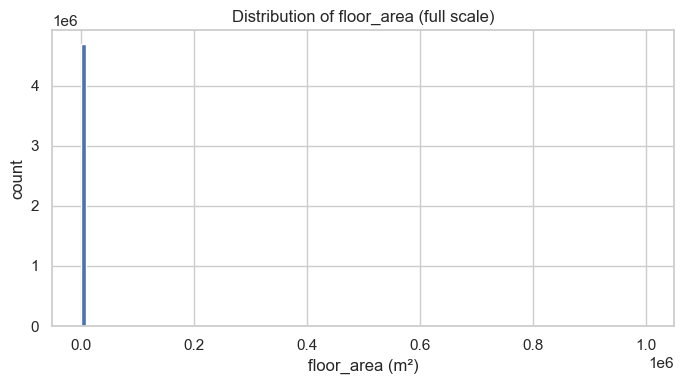

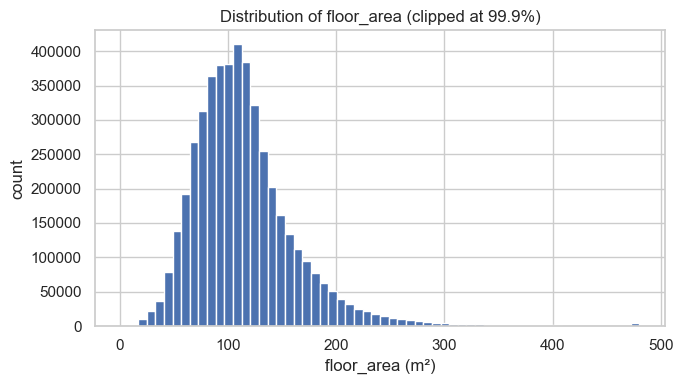

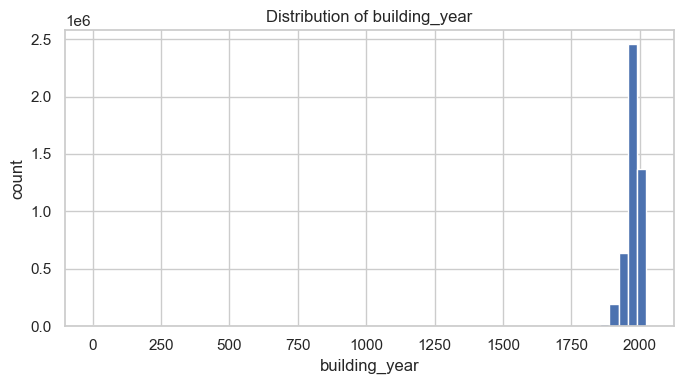

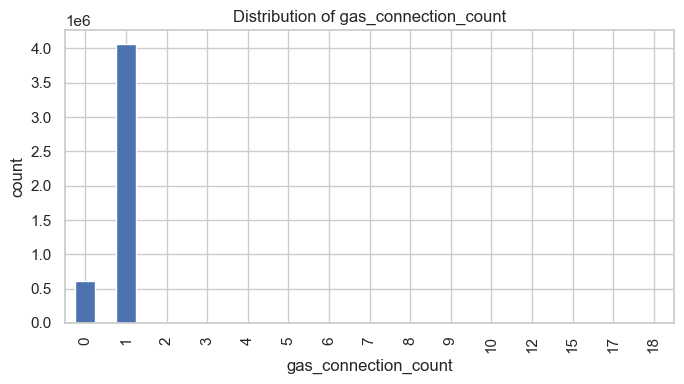

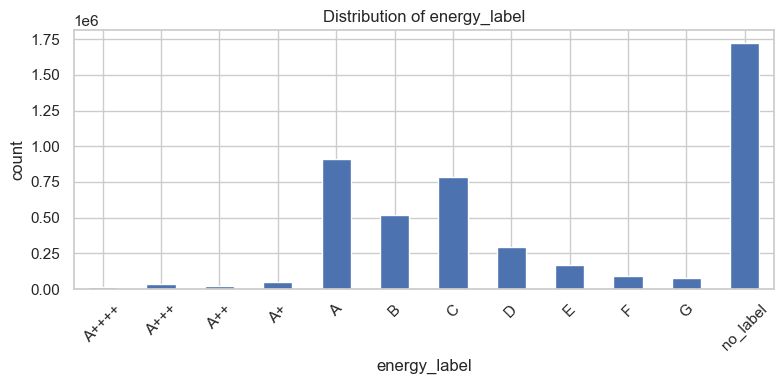

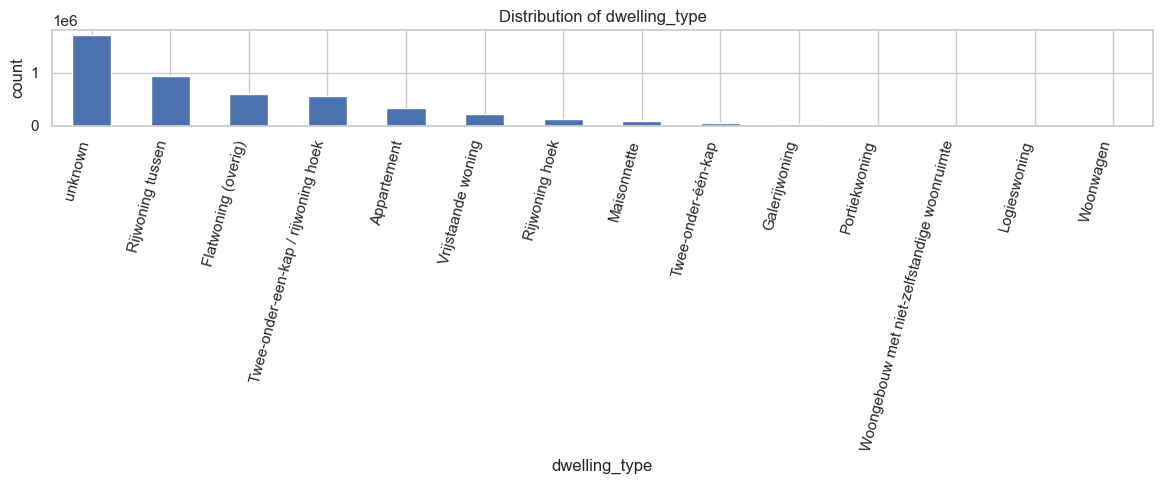

In [9]:
# ----------------------------
# 4.2A numeric distributions
# ----------------------------

# 1) floor_area: full scale
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["floor_area"].dropna(), bins=100)
plt.title("Distribution of floor_area (full scale)")
plt.xlabel("floor_area (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) floor_area: clipped view
upper_99 = df_dwelling["floor_area"].quantile(0.999)

plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["floor_area"].dropna().clip(upper=upper_99), bins=60)
plt.title("Distribution of floor_area (clipped at 99.9%)")
plt.xlabel("floor_area (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3) building_year
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["building_year"].dropna(), bins=60)
plt.title("Distribution of building_year")
plt.xlabel("building_year")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 4) gas_connection_count (discrete)
vc_gas = df_dwelling["gas_connection_count"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
vc_gas.plot(kind="bar")
plt.title("Distribution of gas_connection_count")
plt.xlabel("gas_connection_count")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# ----------------------------
# 4.2B categorical distributions
# ----------------------------

# energy_label
plt.figure(figsize=(8, 4))
df_dwelling["energy_label"].value_counts().reindex(label_order).plot(kind="bar")
plt.title("Distribution of energy_label")
plt.xlabel("energy_label")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# dwelling_type
plt.figure(figsize=(12, 5))
df_dwelling["dwelling_type"].value_counts().plot(kind="bar")
plt.title("Distribution of dwelling_type")
plt.xlabel("dwelling_type")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Interpretation of structural distributions

The distribution plots confirm several key structural properties of the dwelling dataset.

Floor area exhibits strong right-skewness, with most dwellings concentrated within a relatively narrow range and a small number of extreme values distorting the upper tail. Construction year is largely concentrated in the post-war period, with a small number of administrative artifacts (e.g. year = 0). Gas connection counts are heavily concentrated at values of 0 and 1, indicating that gas availability behaves effectively as a binary characteristic.

The categorical distributions show that energy labels are concentrated in mid-efficiency classes, while a substantial share of dwellings lacks a registered label. Dwelling type follows a realistic structural pattern but includes a large `unknown` category, reflecting incomplete classification in the source data.

These observations highlight the presence of skewness, extreme values, and category imbalances, which motivate the targeted structural diagnostics and cleaning steps performed in the next section.

### 4.3 Structural diagnostics

This subsection examines key structural properties of the dwelling-level dataset and applies transformations only when supported by clear empirical evidence.

The objective is to ensure that the structural variables used in later analysis are:

- consistent  
- interpretable  
- free from obvious artefacts  

The diagnostics focus on four aspects:

- 4.3A Gas connection structure (`gas_connection_count`)  
- 4.3B Rare housing type categories (`dwelling_type`)  
- 4.3C Floor area tail diagnostics and threshold decision (`floor_area`)  
- 4.3D Construction year diagnostics (`building_year`)  

Because energy variables are defined at **PC6 level (CBS averages per dwelling)**, all structural filtering decisions are applied at **PC6 level** to preserve consistency between structural composition and energy values.

### 4.3A Gas connection structure (`gas_connection_count`)

We examine the structural distribution of gas connections across dwellings.

The purpose of this analysis is to:

1. determine whether `gas_connection_count` behaves effectively as a binary variable  
2. assess variation within PC6 areas  
3. evaluate whether simplification improves interpretability  

This analysis focuses exclusively on the **structural variable**, since gas consumption is not available at dwelling level.

In [10]:
# ----------------------------
# 4.3A Gas connection diagnostics
# ----------------------------

# Step 1: Inspect overall distribution of gas connections
print("=== gas_connection_count distribution ===")
vc_gas = df_dwelling["gas_connection_count"].value_counts().sort_index()
display(vc_gas)

print("\nNumber of unique gas_connection_count values:")
print(df_dwelling["gas_connection_count"].nunique())

# Step 2: Check variation within PC6 areas
pc6_variation_gas = df_dwelling.groupby("postcode")["gas_connection_count"].nunique()

print("\nShare of PC6s with more than one unique gas_connection_count value:")
print((pc6_variation_gas > 1).mean())

print("\nDistribution of unique gas_connection_count values per PC6:")
display(pc6_variation_gas.value_counts().sort_index())

=== gas_connection_count distribution ===


gas_connection_count
0      613035
1     4059330
2       10498
3        2100
4         243
5          42
6           9
7          14
8           2
9           5
10          2
12          2
15          1
17          1
18          1
Name: count, dtype: int64


Number of unique gas_connection_count values:
15

Share of PC6s with more than one unique gas_connection_count value:
0.2200379746835443

Distribution of unique gas_connection_count values per PC6:


gas_connection_count
1    184851
2     46823
3      4741
4       542
5        38
6         3
7         1
8         1
Name: count, dtype: int64

In [11]:
# ----------------------------
# create binary gas connection indicator
# ----------------------------

df_dwelling["has_gas"] = df_dwelling["gas_connection_count"].fillna(0) > 0

print("share of dwellings with gas connection (has_gas=True):")
print(round(df_dwelling["has_gas"].mean(), 4))

share of dwellings with gas connection (has_gas=True):
0.8692


#### Interpretation and modelling decision

The distribution of `gas_connection_count` shows a very strong concentration at values **0 and 1**. The vast majority of dwellings have exactly one gas connection, while a smaller but still substantial group has no gas connection. Values above 1 exist but are extremely rare and represent only a negligible share of the dataset.

This confirms that the variable does not behave as a continuous quantity, but rather captures the **presence or absence of a gas connection**.

At PC6 level, approximately **22% of postcode areas exhibit variation** in gas connection counts across dwellings, while the majority of PC6 areas are structurally homogeneous. This indicates that mixed gas availability exists but is not dominant.

In total, **86.9% of dwellings have a gas connection**, while the remaining share corresponds to dwellings without gas.

Given this distribution, retaining the full numeric representation of `gas_connection_count` does not provide additional useful information. Instead, the structural characteristic is more clearly and robustly captured using a binary indicator.

Therefore, the variable is transformed into:

- `has_gas = True` if `gas_connection_count > 0`  
- `has_gas = False` if `gas_connection_count = 0`  

This transformation preserves the relevant structural information while improving interpretability and stability for subsequent analysis.

#### 4.3B Rare housing type categories (`woning_type`)

Very rare housing categories may create unstable estimates in later modelling stages.  
When PC6 compositions are computed, categories with extremely small sample sizes can produce noisy or unreliable shares.

To diagnose this, we first examine the structural characteristics and sample size of each housing type.

The objective of this step is to:

- understand structural differences between housing types
- detect extremely rare categories
- determine whether any categories should be removed from the modelling dataset

In [12]:
# ----------------------------
# 4.3B dwelling_type structural comparison
# ----------------------------

type_structure = (
    df_dwelling
    .groupby("dwelling_type")[["floor_area", "building_year"]]
    .agg(["mean", "median", "count"])
)

display(type_structure)

floor_area                  \
                                                   mean median    count   
dwelling_type                                                             
Appartement                                   73.671043   72.0   338795   
Flatwoning (overig)                           73.695672   72.0   595545   
Galerijwoning                                 67.273059   69.0    28221   
Logieswoning                                 106.320000   97.0       75   
Maisonnette                                   88.726991   86.0    86162   
Portiekwoning                                 69.015570   68.0     9698   
Rijwoning hoek                               110.925062  107.0   123983   
Rijwoning tussen                             109.885054  108.0   934218   
Twee-onder-een-kap / rijwoning hoek          128.670414  124.0   570946   
Twee-onder-één-kap                           137.241114  135.0    57757   
Vrijstaande woning                           190.894032  180.0   217057   
Woongebouw met niet-zelfstandige woonruimte   59.890244   33.0      164   
Woonwagen                                     96.125000   69.5        8   
unknown                                      129.772591  119.0  1722656   

                                            building_year                   
                                                     mean  median    count  
dwelling_type                                                               
Appartement                                   1971.905518  1974.0   338795  
Flatwoning (overig)                           1975.090576  1975.0   595545  
Galerijwoning                                 1982.381205  1980.0    28221  
Logieswoning                                  1973.866667  1976.0       75  
Maisonnette                                   1967.553399  1977.0    86162  
Portiekwoning                                 1964.425655  1962.0     9698  
Rijwoning hoek                                1972.427357  1974.0   123983  
Rijwoning tussen                              1976.700936  1978.0   934218  
Twee-onder-een-kap / rijwoning hoek           1979.740578  1981.0   570946  
Twee-onder-één-kap                            1975.983967  1977.0    57757  
Vrijstaande woning                            1979.397734  1988.0   217057  
Woongebouw met niet-zelfstandige woonruimte   1968.725610  1985.0      164  
Woonwagen                                     1727.625000  1987.0        8  
unknown                                       1962.756579  1977.0  1722656

In [13]:
# ----------------------------
# Diagnostic: PC6 affected by rare housing types
# ----------------------------

rare_types = [
    "Logieswoning",
    "Woongebouw met niet-zelfstandige woonruimte",
    "Woonwagen"
]

# PC6 that contain at least one rare type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["dwelling_type"].isin(rare_types),
    "postcode"
].unique()

n_pc6_with_rare = len(pc6_with_rare)
total_pc6 = df_dwelling["postcode"].nunique()

print("PC6 containing rare dwelling types:", n_pc6_with_rare)
print("Total PC6:", total_pc6)
print("Share of PC6 affected:", round(n_pc6_with_rare / total_pc6, 4))


# ----------------------------
# How many dwellings would be removed?
# ----------------------------

rows_in_pc6_with_rare = df_dwelling["postcode"].isin(pc6_with_rare).sum()
total_rows = len(df_dwelling)

print("\nDwellings located in those PC6:", rows_in_pc6_with_rare)
print("Total dwellings:", total_rows)
print("Share of dwellings affected:", round(rows_in_pc6_with_rare / total_rows, 4))


# ----------------------------
# How many rare dwellings themselves?
# ----------------------------

rare_rows = df_dwelling["dwelling_type"].isin(rare_types).sum()

print("\nRare dwelling rows only:", rare_rows)
print("Share of rare dwellings:", round(rare_rows / total_rows, 6))

PC6 containing rare dwelling types: 100
Total PC6: 237000
Share of PC6 affected: 0.0004

Dwellings located in those PC6: 2518
Total dwellings: 4685285
Share of dwellings affected: 0.0005

Rare dwelling rows only: 247
Share of rare dwellings: 5.3e-05


#### Final modelling decision

The structural comparison and diagnostics confirm that three housing types are extremely rare within the national dataset:

- **Logieswoning**  
- **Woongebouw met niet-zelfstandige woonruimte**  
- **Woonwagen**

These categories represent only **247 dwellings (≈0.005% of the dataset)** and occur across **100 PC6 areas (≈0.04% of all postcode areas)**. In total, the affected PC6 areas contain **2,518 dwellings (≈0.05% of the dataset)**.

This confirms that the presence of these categories has a **negligible impact on the overall structure of the housing stock**.

Because the energy variables in the dataset are defined at **PC6 level**, removing only individual dwelling observations would create an inconsistency between the structural composition of a postcode area and its associated energy values.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing these rare dwelling types are removed from the modelling dataset**.

Given the extremely small share of affected PC6 areas and dwellings, this exclusion does not materially affect the representativeness of the Dutch residential housing stock.

The analysis proceeds with the remaining PC6 areas, which represent virtually the entire residential building stock.

In [14]:
# ----------------------------
# remove PC6 areas containing extremely rare housing types
# ----------------------------

# identify PC6 that contain any rare dwelling type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["dwelling_type"].isin(rare_types),
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_rare)
].copy()

print("Remaining PC6:", df_dwelling["postcode"].nunique())
print("Remaining dwellings:", len(df_dwelling))

print("\nRemaining dwelling types:")
print(df_dwelling["dwelling_type"].value_counts())

Remaining PC6: 236900
Remaining dwellings: 4682767

Remaining dwelling types:
dwelling_type
unknown                                1721617
Rijwoning tussen                        934037
Flatwoning (overig)                     595230
Twee-onder-een-kap / rijwoning hoek     570865
Appartement                             338477
Vrijstaande woning                      216818
Rijwoning hoek                          123954
Maisonnette                              86143
Twee-onder-één-kap                       57741
Galerijwoning                            28203
Portiekwoning                             9682
Name: count, dtype: int64


#### Post-filtering dataset summary

After removing PC6 areas containing extremely rare dwelling types, the dataset is only marginally reduced.

- Remaining PC6 areas: **236,900**  
- Remaining dwelling observations: **4,682,767**  

The distribution of dwelling types remains effectively unchanged, confirming that the removed categories had a negligible impact on the overall structure of the housing stock.

This further supports the validity of the filtering step, as it improves consistency without affecting representativeness.

#### 4.3C Floor area tail diagnostics and threshold decision (`floor_area`)

The floor area distribution contains extreme values that strongly distort scale.  
We treat percentiles as diagnostic evidence, and we choose thresholds using a hybrid approach:

- Percentiles to understand where the bulk of the housing stock lies  
- Direct inspection to detect sentinel or implausible magnitudes  
- Candidate threshold testing to quantify how much data is affected  

Based on the diagnostics in Sections 4.3C1–4.3C5, floor area limits are defined to remove implausible observations while preserving realistic housing variability.

In [15]:
# 4.3C1 inspect upper tail values directly (structural plausibility check)

# --- extremely large values (>2000 m²)
extreme_threshold = 2000

extreme_values = (
    df_dwelling[df_dwelling["floor_area"] > extreme_threshold]["floor_area"]
    .value_counts()
    .head(20)
)

print(f"most frequent floor area values above {extreme_threshold} m²:")
display(extreme_values)


# --- large but potentially plausible band (1000–2000 m²)
large_band = (
    df_dwelling[
        (df_dwelling["floor_area"] > 1000) &
        (df_dwelling["floor_area"] <= 2000)
    ]["floor_area"]
    .value_counts()
    .head(20)
)

print("most frequent floor area values between 1000 and 2000 m²:")
display(large_band)


# --- diagnostic summary
n_above_1000 = (df_dwelling["floor_area"] > 1000).sum()
share_above_1000 = 100 * n_above_1000 / len(df_dwelling)

print(f"total dwellings above 1000 m²: {n_above_1000}")
print(f"share of dataset above 1000 m²: {share_above_1000:.6f}%")

most frequent floor area values above 2000 m²:


floor_area
999999.0    3
2003.0      3
99999.0     2
2993.0      2
6745.0      2
13388.0     2
110171.0    2
6214.0      1
9316.0      1
7440.0      1
117615.0    1
9288.0      1
3298.0      1
4920.0      1
4518.0      1
6191.0      1
2465.0      1
2335.0      1
2378.0      1
2011.0      1
Name: count, dtype: int64

most frequent floor area values between 1000 and 2000 m²:


floor_area
1009.0    3
1172.0    3
1019.0    3
1135.0    3
1128.0    3
1092.0    3
1081.0    3
1021.0    2
1031.0    2
1051.0    2
1010.0    2
1496.0    2
1138.0    2
1003.0    2
1244.0    2
1098.0    2
1372.0    2
1221.0    2
1490.0    2
1211.0    2
Name: count, dtype: int64

total dwellings above 1000 m²: 352
share of dataset above 1000 m²: 0.007517%


In [16]:
# 4.3C2 candidate upper limits and removal shares

candidate_upper_limits = [800, 1000, 1500, 2000]

print("removal share for candidate upper limits:")
for limit in candidate_upper_limits:
    removed_share = (df_dwelling["floor_area"] > limit).mean() * 100
    print(f"upper limit {limit} m² → {removed_share:.5f}% removed")

removal share for candidate upper limits:
upper limit 800 m² → 0.01416% removed
upper limit 1000 m² → 0.00752% removed
upper limit 1500 m² → 0.00269% removed
upper limit 2000 m² → 0.00156% removed


In [17]:
# 4.3C3 inspect lower tail values directly (structural plausibility check)

# --- extremely small values (<10 m²)
extreme_lower_threshold = 10

extreme_lower_values = (
    df_dwelling[df_dwelling["floor_area"] < extreme_lower_threshold]["floor_area"]
    .value_counts()
)

print(f"most frequent floor area values below {extreme_lower_threshold} m²:")
display(extreme_lower_values)


# --- small but potentially plausible band (10–20 m²)
small_band = (
    df_dwelling[
        (df_dwelling["floor_area"] >= 10) &
        (df_dwelling["floor_area"] < 20)
    ]["floor_area"]
    .value_counts()
)

print("most frequent floor area values between 10 and 20 m²:")
display(small_band)


# --- diagnostic summary
n_below_10 = (df_dwelling["floor_area"] < 10).sum()
share_below_10 = 100 * n_below_10 / len(df_dwelling)

print(f"total dwellings below 10 m²: {n_below_10}")
print(f"share of dataset below 10 m²: {share_below_10:.6f}%")

most frequent floor area values below 10 m²:


floor_area
1.0    139
9.0     12
5.0      3
8.0      2
2.0      1
7.0      1
Name: count, dtype: int64

most frequent floor area values between 10 and 20 m²:


floor_area
19.0    1410
18.0     708
15.0     664
17.0     414
16.0     301
14.0      73
13.0      55
11.0      45
12.0      31
10.0      23
Name: count, dtype: int64

total dwellings below 10 m²: 158
share of dataset below 10 m²: 0.003374%


In [18]:
# 4.3C4 candidate lower limits and removal shares

candidate_lower_limits = [5, 10, 15, 20]

print("removal share for candidate lower limits:")
for limit in candidate_lower_limits:
    removed_share = (df_dwelling["floor_area"] < limit).mean() * 100
    print(f"lower limit {limit} m² → {removed_share:.6f}% removed")

removal share for candidate lower limits:


lower limit 5 m² → 0.002990% removed
lower limit 10 m² → 0.003374% removed
lower limit 15 m² → 0.008222% removed
lower limit 20 m² → 0.082900% removed


In [19]:
# ----------------------------
# 4.3C5 diagnostic: effect of removing whole PC6 vs only outlier rows
# ----------------------------

lower_limit = 10
upper_limit = 1000

area_outlier_mask = (
    (df_dwelling["floor_area"] < lower_limit) |
    (df_dwelling["floor_area"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[area_outlier_mask, "postcode"].unique()

n_pc6_total = df_dwelling["postcode"].nunique()
n_rows_total = len(df_dwelling)

n_outlier_rows = area_outlier_mask.sum()
share_outlier_rows = n_outlier_rows / n_rows_total

n_pc6_with_outliers = len(pc6_with_area_outliers)
share_pc6_with_outliers = n_pc6_with_outliers / n_pc6_total

rows_in_affected_pc6 = df_dwelling["postcode"].isin(pc6_with_area_outliers).sum()
share_rows_in_affected_pc6 = rows_in_affected_pc6 / n_rows_total

print("=== Floor area outlier diagnostic ===")
print(f"Outlier dwellings only: {n_outlier_rows}")
print(f"Share of outlier dwellings: {share_outlier_rows:.6%}")

print(f"\nPC6 containing at least one area outlier: {n_pc6_with_outliers}")
print(f"Share of PC6 affected: {share_pc6_with_outliers:.6%}")

print(f"\nDwellings located in those affected PC6: {rows_in_affected_pc6}")
print(f"Share of dwellings affected if whole PC6 were removed: {share_rows_in_affected_pc6:.6%}")

=== Floor area outlier diagnostic ===
Outlier dwellings only: 510
Share of outlier dwellings: 0.010891%

PC6 containing at least one area outlier: 416
Share of PC6 affected: 0.175602%

Dwellings located in those affected PC6: 10857
Share of dwellings affected if whole PC6 were removed: 0.231850%


#### Final floor area threshold decision

The diagnostic analysis of the floor area distribution reveals the presence of extreme and implausible values in both tails, while the vast majority of dwellings lie within a well-defined central range.

Inspection of the upper tail shows the existence of clear sentinel and erroneous values, such as **99,999 m² and 999,999 m²**, alongside highly implausible dwelling sizes exceeding several thousand square meters. At the same time, values between **1000 and 2000 m²** are extremely sparse and do not represent a meaningful segment of the residential building stock. In total, only **352 dwellings (0.0075%)** exceed 1000 m².

Lower-tail inspection identifies a small number of dwellings with floor areas below **10 m²**, including repeated values such as **1 m²**, which are physically implausible for residential units and likely reflect data entry errors or misclassification. These observations account for only **158 dwellings (0.0034%)** of the dataset.

Evaluation of candidate thresholds confirms that removing observations outside the range **[10, 1000] m²** affects only a negligible fraction of the data. However, when accounting for the PC6 structure of the dataset, removing individual outlier dwellings would create inconsistencies between the structural composition of a postcode area and its associated energy values.

A PC6-level diagnostic shows that while only **510 dwellings (0.011%)** are direct outliers, they are distributed across **416 PC6 areas (0.18%)**, affecting a total of **10,857 dwellings (0.23%)** if entire postcode areas are removed.

To preserve consistency between structural variables and PC6-level energy data, the filtering is therefore applied at postcode level.

The adopted structural limits are:

- **Lower limit:** 10 m²  
- **Upper limit:** 1000 m²  

All PC6 areas containing dwellings outside this range are excluded from the dataset. This approach ensures structural consistency while removing only a very small fraction of the overall sample, and does not materially affect the representation of the Dutch residential housing stock.

In [20]:
# 4.3C6 final structural thresholds (PC6-consistent filtering)

lower_limit = 10
upper_limit = 1000

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one floor-area outlier
area_outlier_mask = (
    (df_dwelling["floor_area"] < lower_limit) |
    (df_dwelling["floor_area"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[
    area_outlier_mask, "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_area_outliers)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent floor area filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent floor area filtering
remaining PC6: 236484
remaining rows: 4671910

PC6 removed: 416
dwellings removed: 10857

share of PC6 removed: 0.17560%
share of dwellings removed: 0.23185%


#### Dataset after floor area filtering

After applying the PC6-consistent floor area thresholds, the dataset remains largely unchanged in size, confirming that extreme values are rare and concentrated in a small number of postcode areas.

A total of **416 PC6 areas (0.176%)** are removed, corresponding to **10,857 dwellings (0.232%)**. The resulting dataset contains:

- **236,484 PC6 areas**
- **4,671,910 dwellings**

This limited reduction indicates that the applied thresholds effectively remove implausible observations while preserving the overall structure and representativeness of the Dutch residential housing stock.

#### 4.3D Construction year diagnostics and threshold decision (`pand_bouwjaar`)

Construction year is retained during minimal cleaning so that lower-tail values can be diagnosed before applying a structural threshold.

We inspect the lower tail of `pand_bouwjaar` to identify clearly implausible or administrative values and then apply a final lower bound supported by the observed distribution.

In [21]:
# 4.3D1 construction year diagnostics

print("minimum building_year:", df_dwelling["building_year"].min())
print(df_dwelling["building_year"].describe(percentiles=[0.001, 0.01, 0.05]))

print("most frequent building_year values below 1700:")
display(
    df_dwelling.loc[df_dwelling["building_year"] < 1700, "building_year"]
    .value_counts()
    .head(20)
)

print("Construction year values between 1 and 999:")

display(
    df_dwelling.loc[
        (df_dwelling["building_year"] >= 1) &
        (df_dwelling["building_year"] < 1000),
        "building_year"
    ]
    .value_counts()
    .sort_index()
)

minimum building_year: 0
count    4.671910e+06
mean     1.971264e+03
std      9.596176e+01
min      0.000000e+00
0.1%     0.000000e+00
1%       1.897000e+03
5%       1.923000e+03
max      2.024000e+03
Name: building_year, dtype: float64
most frequent building_year values below 1700:


building_year
0       10101
1650      258
1600       95
1681       75
1450       70
1660       69
1625       54
1592       51
1631       51
1666       36
1675       34
1680       30
1005       29
1350       28
1670       26
1690       26
1659       24
1671       23
1616       22
1683       21
Name: count, dtype: int64

Construction year values between 1 and 999:


Series([], Name: count, dtype: int64)

#### Final construction year threshold decision

The diagnostic analysis of the construction year variable reveals a clear distinction between valid historical values and administrative artifacts.

The lower tail is dominated by entries with **building_year = 0**, which appear **10,101 times** and represent placeholder or missing values rather than actual construction years. These values do not correspond to real buildings and cannot be interpreted meaningfully.

In contrast, all other low construction years correspond to plausible historical buildings (e.g. 1400–1700 range), reflecting the presence of older structures in the Dutch housing stock. Importantly, no values are observed in the range **1–999**, confirming that the only problematic lower-tail value is the administrative zero.

Given this structure, a minimal and data-consistent threshold is applied:

- **Lower limit:** 1 (i.e. remove only `building_year = 0`)

This approach ensures that only clearly invalid entries are excluded, while preserving the full range of historically valid construction years. The resulting dataset maintains both accuracy and completeness in representing the temporal structure of the housing stock.

In [22]:
# 4.3D2 final construction year threshold 

year_lower_limit = 1

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one invalid construction year
pc6_with_invalid_building_year = df_dwelling.loc[
    df_dwelling["building_year"] < year_lower_limit,
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_invalid_building_year)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent construction year filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent construction year filtering
remaining PC6: 234882
remaining rows: 4627049

PC6 removed: 1602
dwellings removed: 44861

share of PC6 removed: 0.67742%
share of dwellings removed: 0.96023%


#### Dataset after construction year filtering

After removing PC6 areas containing invalid construction year values (`building_year = 0`), the dataset remains largely unchanged in overall structure, although the impact is slightly larger than in previous filtering steps.

A total of **1,602 PC6 areas (0.677%)** are removed, corresponding to **44,861 dwellings (0.960%)**. The resulting dataset contains:

- **234,882 PC6 areas**
- **4,627,049 dwellings**

This PC6-consistent filtering step ensures that all retained postcode areas contain valid construction year values, while preserving the structural integrity and representativeness of the Dutch residential housing stock.

### 4.4 Correlation analysis between dwelling features

This section quantifies statistical relationships between dwelling characteristics, building directly on the previous steps:

- **4.1 Descriptive statistics** confirmed that each feature has meaningful variation.
- **4.2 Distribution visualization** revealed skewness, heavy tails, and category imbalance.
- **4.3 Structural diagnostics** handled artifacts (especially in `floor_area`) and clarified how variables behave. In particular, the gas connection variable was shown to behave largely as a binary structural characteristic, so the derived indicator `has_gas` is used in the correlation analysis that follows.

Because the dataset includes mixed variable types, no single association measure is appropriate for all variable pairs. Therefore, associations are evaluated using measures matched to variable type:

- **Spearman correlation** for numeric-numeric relationships
- **Cramér’s V** for categorical-categorical relationships
- **Correlation ratio (η)** for categorical-numeric relationships

After evaluating each pair type separately, a **mixed-type association matrix** is constructed to provide a unified overview of all relationships between dwelling features.

Finally, a **Variance Inflation Factor (VIF)** diagnostic is performed to detect multicollinearity within the predictor set used later in regression modelling.

#### 4.4A Prepare analysis variables

The association analysis uses a set of structural dwelling variables describing building characteristics and energy-related attributes.

Numeric variables:

- `floor_area` – dwelling floor area  
- `building_year` – construction year  

Categorical variables:

- `energy_label` – energy performance label  
- `dwelling_type` – dwelling type  
- `has_gas` – indicator of gas connection presence  

Energy labels are treated as categorical variables, including the category `no_label`, which represents dwellings without a registered energy label.

The variable `has_gas` is derived from `gas_connection_count` and used as a binary structural indicator.

In [23]:
# ----------------------------
# 4.4A Prepare analysis variables
# ----------------------------

# numeric features used in association analysis
num_cols = ["floor_area", "building_year"]

# categorical features used in association analysis
cat_cols = ["energy_label", "dwelling_type", "has_gas"]

# ensure has_gas exists
if "has_gas" not in df_dwelling.columns:
    df_dwelling["has_gas"] = df_dwelling["gas_connection_count"].fillna(0) > 0

# ensure energy_label remains an explicit categorical variable
label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energy_label"] = pd.Categorical(
    df_dwelling["energy_label"],
    categories=label_order,
    ordered=False
)

# quick sanity checks
print("sanity checks")
print("rows:", len(df_dwelling))
print("unique pc6:", df_dwelling["postcode"].nunique())
print("share has_gas = true:", round(df_dwelling["has_gas"].mean(), 4))
print("share energy_label == 'no_label':",
      round((df_dwelling["energy_label"] == "no_label").mean(), 4))

print("\nenergy_label counts:")
display(df_dwelling["energy_label"].value_counts(dropna=False).sort_index())

sanity checks
rows: 4627049
unique pc6: 234882
share has_gas = true: 0.8733
share energy_label == 'no_label': 0.3662

energy_label counts:


energy_label
A++++          9896
A+++          32428
A++           20859
A+            49444
A            897072
B            516095
C            778247
D            293930
E            168037
F             92510
G             74011
no_label    1694520
Name: count, dtype: int64

#### Data consistency check

After structural diagnostics and PC6-consistent filtering, the dataset contains:

- **4,627,049 dwellings**
- **234,882 PC6 areas**

The gas connection indicator shows that **87.3% of dwellings have a gas connection**, confirming the dominance of gas-based heating in the current housing stock.

The energy label distribution reveals that **36.6% of dwellings do not have a registered energy label (`no_label`)**, indicating a substantial share of missing label information. This reinforces the importance of treating energy labels as categorical variables with an explicit `no_label` category.

Overall, the dataset remains large, structurally consistent, and suitable for correlation analysis.

#### 4.4B Numeric structural correlations: Spearman correlation

Relationships between numeric dwelling characteristics are evaluated using **Spearman rank correlation**.

Spearman correlation measures how strongly two variables move together in a **monotonic way**, meaning that as one variable increases, the other tends to either consistently increase or decrease.

Instead of using the raw values, Spearman correlation is based on the **rank ordering** of the data. This means that each observation is replaced by its position when the data are sorted.

For example, the smallest value receives rank 1, the second smallest rank 2, and so on, making the measure more robust to skewed distributions and extreme values.

Formally, Spearman correlation is defined as the Pearson correlation between the ranked variables:

$$
\rho_s = Corr(rank(X), rank(Y))
$$

where:

- $rank(X)$ and $rank(Y)$ are the ranks of the observations  
- $\rho_s$ ranges from **-1** to **1**  

Interpretation:

- **+1** → perfect increasing relationship  
- **-1** → perfect decreasing relationship  
- **0** → no monotonic relationship  

The analysis focuses on:

- `floor_area` – dwelling floor area  
- `building_year` – construction year  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

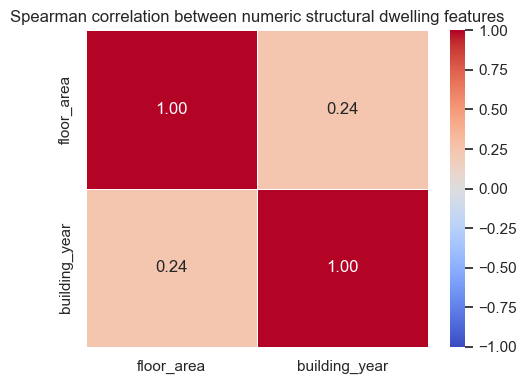

In [24]:
# ----------------------------
# 4.4B Spearman correlation heatmap
# ----------------------------

spearman_cols = ["floor_area", "building_year"]

corr_spearman = df_dwelling[spearman_cols].corr(method="spearman")

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Spearman correlation between numeric structural dwelling features")
plt.tight_layout()
plt.show()

#### 4.4C Categorical-categorical associations: Cramér’s V

Associations between categorical dwelling characteristics are measured using **Cramér’s V**.

Cramér’s V measures how strongly two categorical variables are related by comparing the **observed distribution of combinations** to what would be expected if the variables were independent.

For example, it evaluates whether certain dwelling types appear more frequently with specific energy labels than would occur by chance.

The measure is based on the chi-squared statistic computed from a contingency table, which summarizes how often each combination of categories occurs.

It is defined as:

$$
V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}}
$$

where:

- $\chi^2$ measures how far the observed category combinations deviate from independence  
- $n$ is the total number of observations  
- $r$ and $c$ are the number of categories in each variable  

Cramér’s V ranges from **0** to **1**:

- **0** indicates no association (variables are independent)  
- **1** indicates perfect association  

The categorical variables considered are:

- `energy_label` – energy performance label  
- `dwelling_type` – dwelling type  
- `has_gas` – gas connection indicator  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

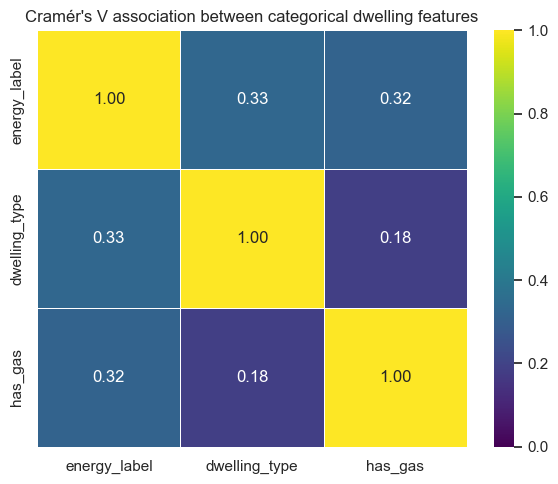

In [25]:
# ----------------------------
# 4.4C Cramér's V association heatmap
# ----------------------------

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Compute Cramér's V statistic for categorical-categorical association.
    """
    contingency_table = pd.crosstab(x, y)

    if contingency_table.size == 0:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    denom = min(r - 1, k - 1)

    if denom <= 0 or n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / denom)


cat_for_v = ["energy_label", "dwelling_type", "has_gas"]

V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)

for i in cat_for_v:
    for j in cat_for_v:
        if i == j:
            V.loc[i, j] = 1.0
        else:
            V.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

plt.figure(figsize=(6, 5))
sns.heatmap(
    V,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Cramér's V association between categorical dwelling features")
plt.tight_layout()
plt.show()

#### 4.4D Categorical-numeric associations: correlation ratio η

Relationships between categorical and numeric variables are evaluated using the **correlation ratio (η)**.

The correlation ratio measures how strongly a numeric variable differs across categories of a categorical variable.

In practical terms, it evaluates whether the **average value of a numeric variable changes systematically across groups**.

For example, it assesses whether different dwelling types have systematically different average floor areas.

The measure compares:

- variation **between category means**  
- relative to the **total variation in the data**

It is defined as:

$$
\eta = \sqrt{\frac{\sum_k n_k(\bar{y}_k - \bar{y})^2}{\sum_i (y_i - \bar{y})^2}}
$$

where:

- $k$ indexes the categories  
- $n_k$ is the number of observations in category $k$  
- $\bar{y}_k$ is the mean within category $k$  
- $\bar{y}$ is the overall mean  
- $y_i$ are individual observations  

Interpretation:

- **0** → category does not explain variation in the numeric variable  
- **1** → category perfectly determines the numeric variable  

In this analysis, it is used to evaluate how:

- `dwelling_type`  
- `energy_label`  
- `has_gas`  

relate to:

- `floor_area`  
- `building_year`  

Only the heatmap is shown here. The numerical values are later consolidated in the mixed association matrix.

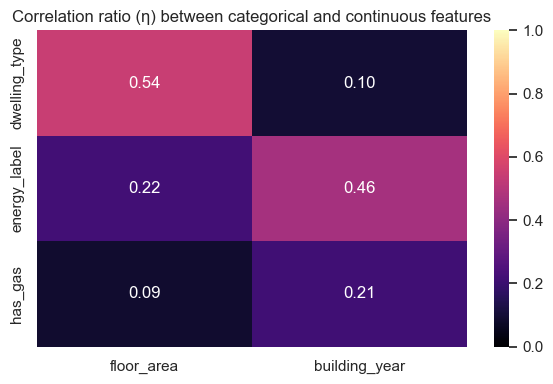

In [26]:
# ----------------------------
# 4.4D Correlation ratio (η) heatmap
# ----------------------------

def correlation_ratio(categories, measurements):
    """
    Compute correlation ratio (η) for categorical-continuous association.
    """
    valid = pd.notna(categories) & pd.notna(measurements)
    categories = pd.Series(categories)[valid]
    measurements = pd.Series(measurements)[valid].astype(float)

    if len(measurements) == 0:
        return np.nan

    codes, uniques = pd.factorize(categories)
    cat_num = len(uniques)

    if cat_num <= 1:
        return np.nan

    y_avg = np.zeros(cat_num)
    n = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[codes == i]
        n[i] = len(cat_measures)
        if len(cat_measures) > 0:
            y_avg[i] = np.mean(cat_measures)

    y_total = np.sum(y_avg * n) / np.sum(n)

    numerator = np.sum(n * (y_avg - y_total) ** 2)
    denominator = np.sum((measurements - y_total) ** 2)

    if denominator == 0:
        return np.nan

    return np.sqrt(numerator / denominator)


cont_vars = ["floor_area", "building_year"]
cat_vars = ["dwelling_type", "energy_label", "has_gas"]

eta_matrix = pd.DataFrame(index=cat_vars, columns=cont_vars)

for cat in cat_vars:
    for cont in cont_vars:
        eta_matrix.loc[cat, cont] = correlation_ratio(
            df_dwelling[cat],
            df_dwelling[cont]
        )

eta_matrix = eta_matrix.astype(float)

plt.figure(figsize=(6, 4))
sns.heatmap(
    eta_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    vmin=0,
    vmax=1
)
plt.title("Correlation ratio (η) between categorical and continuous features")
plt.tight_layout()
plt.show()

#### 4.4E Mixed association matrix

To provide a consolidated overview of dependencies between all dwelling characteristics, a mixed-type association matrix is constructed.

Different association measures are applied depending on the variable pair:

- **Spearman correlation** for numeric–numeric relationships  
- **Cramér’s V** for categorical–categorical relationships  
- **Correlation ratio (η)** for categorical–numeric relationships  

Because different statistics are used for different variable combinations, the resulting matrix does **not represent a single unified correlation coefficient**, but rather a collection of appropriate association measures.

The matrix therefore serves as an **exploratory diagnostic tool** to identify potentially strong dependencies between structural dwelling variables.

To avoid redundancy, detailed numerical outputs are not shown separately in previous sections, as all associations are consolidated in the matrix below.

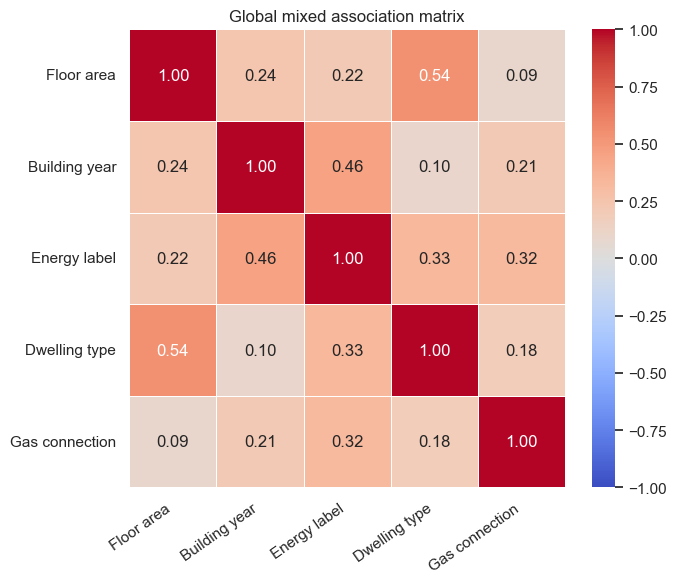

In [27]:
# ----------------------------
# 4.4E Mixed association matrix
# ----------------------------

num_vars = ["floor_area", "building_year"]
cat_vars = ["energy_label", "dwelling_type", "has_gas"]

all_vars = num_vars + cat_vars

mixed_matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for i in all_vars:
    for j in all_vars:

        if i == j:
            mixed_matrix.loc[i, j] = 1.0

        elif i in num_vars and j in num_vars:
            mixed_matrix.loc[i, j] = df_dwelling[[i, j]].corr(method="spearman").iloc[0, 1]

        elif i in cat_vars and j in cat_vars:
            mixed_matrix.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

        else:
            cat_var = i if i in cat_vars else j
            cont_var = j if i in cat_vars else i
            mixed_matrix.loc[i, j] = correlation_ratio(
                df_dwelling[cat_var],
                df_dwelling[cont_var]
            )

label_map = {
    "floor_area": "Floor area",
    "building_year": "Building year",
    "energy_label": "Energy label",
    "dwelling_type": "Dwelling type",
    "has_gas": "Gas connection"
}

mixed_matrix_plot = mixed_matrix.rename(index=label_map, columns=label_map)

plt.figure(figsize=(7, 6))
sns.heatmap(
    mixed_matrix_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Global mixed association matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation of structural associations

The mixed association matrix summarizes the strength of relationships between structural dwelling characteristics using appropriate measures for each variable type.

The strongest association is observed between **floor area and dwelling type (0.54)**, indicating that housing typology is the primary determinant of dwelling size. This reflects clear structural differences between dwelling categories, such as apartments and detached houses.

A second strong relationship is found between **building year and energy label (0.46)**, suggesting that energy performance is closely linked to the age of the building stock. Newer buildings tend to exhibit higher energy efficiency, while older buildings are more likely to have lower energy labels.

Moderate associations are observed between **energy label and dwelling type (0.33)** and between **energy label and gas connection (0.32)**. These relationships indicate that energy performance is influenced both by building characteristics and by infrastructure availability.

The association between **building year and gas connection (0.21)** suggests a gradual structural transition in heating systems over time, while the relationship between **dwelling type and gas connection (0.18)** remains relatively weak.

Finally, the association between **floor area and gas connection (0.09)** is very low, indicating that gas availability is largely independent of dwelling size.

Overall, the results show that while meaningful relationships exist between structural variables, no pair exhibits extremely high association. This indicates that the variables capture **complementary dimensions** of the housing stock rather than redundant information.

Because the matrix combines different association measures (Spearman correlation, Cramér’s V, and correlation ratio η), the values should be interpreted as **relative indicators of association strength** rather than directly comparable coefficients within a single statistical scale.

## 5️⃣ PC6-level structural composition and energy analysis

The previous chapter examined structural dwelling characteristics at dwelling level and evaluated the internal relationships between these variables.

The next step is to move from the **dwelling level** to the **PC6 level**, since the final modelling stage is based on postcode areas rather than individual dwellings.

This requires constructing a new dataset with **one row per PC6**, where:

- dwelling-level structural information is aggregated into postcode-level composition variables
- CBS energy variables are represented consistently at PC6 level
- socioeconomic and housing-context variables are merged with the structural composition data

The workflow proceeds in structured steps:

1. Examine within-PC6 structural dispersion  
2. Construct a clean PC6 base dataset  
3. Examine PC6 energy scaling as a diagnostic  
4. Compute PC6 structural composition variables  
5. Construct average per-dwelling PC6 energy indicators  
6. Analyse associations between PC6 composition and energy intensity

### 5.1 Within-PC6 structural dispersion

Before aggregating dwelling-level variables to postcode level, it is useful to examine how heterogeneous dwellings are within each PC6 area. If dwellings inside a postcode area are structurally homogeneous, postcode-level averages provide a reliable representation of the housing stock. If large internal variation exists, aggregation may hide important structural differences.

To evaluate this, we measure the **coefficient of variation (CV)** of key dwelling characteristics within each PC6. The coefficient of variation is defined as:

$$
CV = \frac{\sigma}{\mu}
$$

where:

- $\sigma$ is the standard deviation within a PC6  
- $\mu$ is the mean value within the PC6  

The CV measures **relative dispersion**, meaning the amount of variation compared to the typical level of the variable. For example:

- CV = 0.10 means variation equals about 10% of the mean  
- CV = 0.25 means variation equals about 25% of the mean  

This metric is useful because it allows dispersion to be compared across variables with different units and scales.

The analysis focuses on two structural dwelling characteristics:

- `floor_area` — dwelling floor area  
- `building_year` — construction year  

For each PC6 area, the coefficient of variation is computed and the distribution of these values is examined across postcode areas.

Number of PC6 areas: 234882

Summary statistics of within-PC6 dispersion (Coefficient of Variation):


,cv_floor_area,cv_building_year
count,234880.000000,234880.000000
mean,0.170170,0.002270
std,0.138666,0.005814
min,0.000000,0.000000
1%,0.000000,0.000000
5%,0.000000,0.000000
25%,0.073119,0.000000
50%,0.141118,0.000000
75%,0.234315,0.001143
95%,0.423324,0.013845


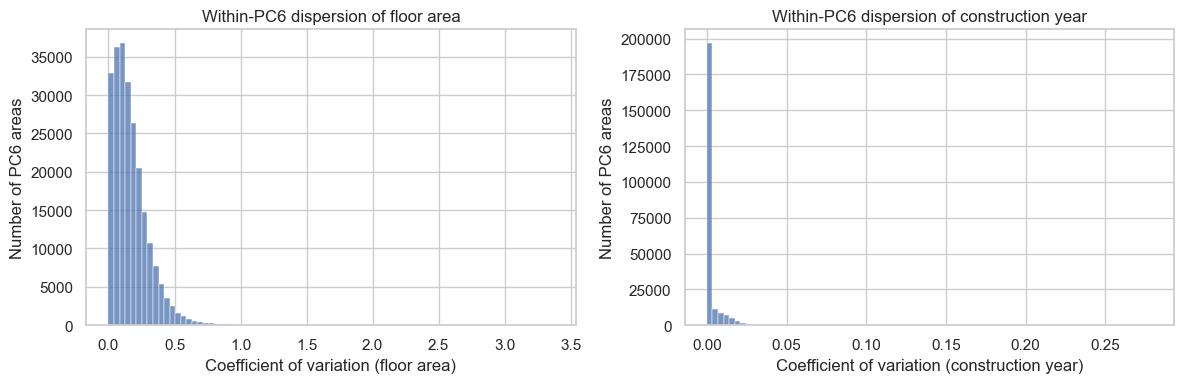

In [28]:
# ----------------------------
# 5.1 Within-PC6 structural dispersion (Coefficient of Variation)
# ----------------------------

# variables of interest
dispersion_vars = ["floor_area", "building_year"]

# compute mean and standard deviation within each PC6
pc6_mean = df_dwelling.groupby("postcode")[dispersion_vars].mean()
pc6_std = df_dwelling.groupby("postcode")[dispersion_vars].std()

# compute coefficient of variation
pc6_cv = pd.DataFrame({
    "cv_floor_area": pc6_std["floor_area"] / pc6_mean["floor_area"],
    "cv_building_year": pc6_std["building_year"] / pc6_mean["building_year"]
})

print("Number of PC6 areas:", len(pc6_cv))

print("\nSummary statistics of within-PC6 dispersion (Coefficient of Variation):")
display(
    pc6_cv.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

# ----------------------------
# visualization
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(pc6_cv["cv_floor_area"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("Within-PC6 dispersion of floor area")
axes[0].set_xlabel("Coefficient of variation (floor area)")
axes[0].set_ylabel("Number of PC6 areas")

sns.histplot(pc6_cv["cv_building_year"].dropna(), bins=80, ax=axes[1])
axes[1].set_title("Within-PC6 dispersion of construction year")
axes[1].set_xlabel("Coefficient of variation (construction year)")
axes[1].set_ylabel("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Interpretation

The coefficient of variation indicates that postcode areas exhibit **moderate internal variation in dwelling size but extremely low variation in construction year**.

For floor area, the median coefficient of variation is approximately **0.14**, meaning that the standard deviation of dwelling size within a typical PC6 area is about **14% of the mean dwelling size**. The interquartile range (0.07–0.23) confirms that most postcode areas contain dwellings of broadly similar size. However, the right tail of the distribution extends beyond **0.4**, indicating that a small number of PC6 areas contain a more heterogeneous mix of dwelling sizes.

In contrast, construction year shows **negligible dispersion within PC6 areas**. The median coefficient of variation is **0**, and even at the 75th percentile the value remains extremely small (≈0.001). This indicates that most postcode areas consist of dwellings built within the same development period. Only a very small fraction of PC6 areas exhibit noticeable variation in construction year.

Overall, these results suggest that:

- PC6 areas are **structurally homogeneous in terms of construction period**
- PC6 areas are **moderately homogeneous in terms of dwelling size**

This supports the use of postcode-level averages such as:

- `mean_oppervlakte`
- `mean_bouwjaar`

as representative indicators of the housing stock in each PC6 area, since aggregation does not obscure substantial internal variation.

### 5.2 Construct PC6 base dataset

We construct a dataset with **one observation per PC6 area**, which will serve as the basis for all subsequent PC6-level analysis.

The dwelling-level dataset contains multiple rows per postcode, since each row corresponds to an individual dwelling. In contrast, the CBS dataset is already defined at PC6 level and contains one row per postcode.

To combine these sources consistently, the dwelling-level dataset is aggregated to postcode level and then merged with CBS variables using postcode as the common key.

For each PC6 area, the base dataset includes:

- `n_dwellings` — number of dwellings in the PC6  
- `kwh_avg_per_dwelling_pc6` — average electricity consumption per dwelling  
- `gas_avg_per_dwelling_pc6` — average gas consumption per dwelling  
- `pv_avg_per_dwelling_pc6` — average electricity production per dwelling  
- `kwh_total_pc6` — total electricity consumption in the PC6  
- `gas_total_pc6` — total gas consumption in the PC6  
- `pv_total_pc6` — total electricity production in the PC6  

CBS socioeconomic and housing-context variables:

- `population_total`
- `private_households_total`
- `avg_household_size`
- `unoccupied_dwellings`
- `avg_woz_value`
- `population_on_benefits`

Electricity and gas consumption are obtained from CBS as **average values per dwelling at PC6 level**. Total electricity and gas consumption are reconstructed by multiplying these average values by the number of dwellings in each PC6.

PV production is obtained from the structural dataset as a PC6-level total. For consistency, an average-per-dwelling PV production variable is also computed.

In [29]:
# ----------------------------
# 5.2 Construct PC6 base dataset
# ----------------------------

# 1. Aggregate dwelling-level structural data to one row per PC6
pc6_base = (
    df_dwelling
    .groupby("postcode")
    .agg(
        municipality_code=("municipality_code", "first"),
        n_dwellings=("postcode", "size"),
        pv_total_pc6=("pc6_electricity_production_2023", "sum")
    )
    .reset_index()
)

# 2. Keep relevant CBS PC6 variables
cbs_cols_for_base = [
    "postcode",
    "number_of_inhabitants",
    "number_of_private_households",
    "average_household_size",
    "number_of_unoccupied_dwellings",
    "average_woz_value_home",
    "average_gas_consumption_home",
    "average_electricity_consumption_dwelling",
    "number_of_people_receiving_benefits_below_pension_age"
]

df_cbs_pc6_model = df_cbs_pc6.loc[
    df_cbs_pc6["postcode"].isin(pc6_base["postcode"]),
    cbs_cols_for_base
].copy()

# 3. Merge CBS PC6-level variables into PC6 base dataset
pc6_base = pc6_base.merge(
    df_cbs_pc6_model,
    on="postcode",
    how="left",
    validate="one_to_one"
)

# 4. Rename variables clearly and consistently
pc6_base = pc6_base.rename(columns={
    "number_of_inhabitants": "population_total",
    "number_of_private_households": "private_households_total",
    "average_household_size": "avg_household_size",
    "number_of_unoccupied_dwellings": "unoccupied_dwellings",
    "average_woz_value_home": "avg_woz_value",
    "average_gas_consumption_home": "gas_avg_per_dwelling_pc6",
    "average_electricity_consumption_dwelling": "kwh_avg_per_dwelling_pc6",
    "number_of_people_receiving_benefits_below_pension_age": "population_on_benefits"
})

# 5. Reconstruct total PC6 energy consumption from CBS average-per-dwelling values
pc6_base["kwh_total_pc6"] = (
    pc6_base["kwh_avg_per_dwelling_pc6"] * pc6_base["n_dwellings"]
)

pc6_base["gas_total_pc6"] = (
    pc6_base["gas_avg_per_dwelling_pc6"] * pc6_base["n_dwellings"]
)

# 6. Construct average PV production per dwelling from PC6 total PV production
pc6_base["pv_avg_per_dwelling_pc6"] = (
    pc6_base["pv_total_pc6"] / pc6_base["n_dwellings"]
)

# 7. Keep columns in a clear order
pc6_base = pc6_base[
    [
        "postcode",
        "municipality_code",
        "n_dwellings",
        "kwh_avg_per_dwelling_pc6",
        "gas_avg_per_dwelling_pc6",
        "pv_avg_per_dwelling_pc6",
        "kwh_total_pc6",
        "gas_total_pc6",
        "pv_total_pc6",
        "population_total",
        "private_households_total",
        "avg_household_size",
        "unoccupied_dwellings",
        "avg_woz_value",
        "population_on_benefits"
    ]
].copy()

# ----------------------------
# Diagnostics
# ----------------------------

print("PC6 base dataset")
print("rows:", len(pc6_base))
print("unique PC6:", pc6_base["postcode"].nunique())

print("\nMissing values in key variables:")
display(
    pc6_base[
        [
            "population_total",
            "private_households_total",
            "avg_household_size",
            "unoccupied_dwellings",
            "avg_woz_value",
            "kwh_avg_per_dwelling_pc6",
            "gas_avg_per_dwelling_pc6",
            "pv_avg_per_dwelling_pc6",
            "population_on_benefits"
        ]
    ].isna().sum()
)

pc6_base.head()

PC6 base dataset
rows: 234882
unique PC6: 234882

Missing values in key variables:


population_total              1118
private_households_total      2433
avg_household_size            2433
unoccupied_dwellings        232875
avg_woz_value                  151
kwh_avg_per_dwelling_pc6         0
gas_avg_per_dwelling_pc6         0
pv_avg_per_dwelling_pc6          0
population_on_benefits      176377
dtype: int64

,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,private_households_total,avg_household_size,unoccupied_dwellings,avg_woz_value,population_on_benefits
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,25.0,1.6,NaN,622.0,NaN
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,15.0,2.1,5.0,870.0,NaN
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,10.0,1.4,NaN,559.0,NaN
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,15.0,1.3,NaN,647.0,NaN
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,15.0,1.8,NaN,623.0,NaN


### Methodological Note

The PC6 base dataset contains one row per postcode area and combines structural dwelling information with CBS socioeconomic and energy variables.

Electricity and gas consumption are complete for all retained PC6 areas and are represented as average-per-dwelling variables:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`

The corresponding total energy variables are reconstructed as:

$$
E_{total,pc6} = E_{avg,pc6} \cdot N_{pc6}
$$

where:

- $E_{total,pc6}$ is total energy consumption in the PC6  
- $E_{avg,pc6}$ is average consumption per dwelling in the PC6  
- $N_{pc6}$ is the number of dwellings in the PC6  

PV production is available from the structural dataset as a PC6-level total (`pv_total_pc6`). The corresponding average-per-dwelling variable (`pv_avg_per_dwelling_pc6`) is computed by dividing total PV production by the number of dwellings.

Some CBS socioeconomic and housing-context variables still contain missing values. These missing values are not filtered out at this stage, because they reflect CBS confidentiality and suppression rules. They are handled explicitly later through variable-specific missingness diagnostics.

### 5.3 Compute PC6 composition variables

We now compute composition indicators describing the housing stock within each postcode area.

These variables summarize the dwelling-level structural dataset at PC6 level and are combined with selected contextual variables from the CBS dataset.

Two types of indicators are constructed.

**Average variables**

- mean floor area (`mean_floor_area`)
- mean construction year (`mean_building_year`)
- average household size (`avg_household_size`)
- average WOZ value (`avg_woz_value`)

**Composition shares**

- share of dwellings with gas connection (`share_has_gas`)
- share of each dwelling type (`dwelling_type`)
- share of each energy label (`energy_label`)
- share of unoccupied dwellings (`share_unoccupied`)
- share of population receiving benefits (`share_population_on_benefits`)

These variables describe the structural and socioeconomic composition of the housing stock within each postcode and will later be used to examine how postcode composition relates to average per-dwelling energy consumption.

In [30]:
# ----------------------------
# 5.3 Compute PC6 composition variables
# ----------------------------

df_dwelling["floor_area"] = pd.to_numeric(df_dwelling["floor_area"], errors="coerce")
df_dwelling["building_year"] = pd.to_numeric(df_dwelling["building_year"], errors="coerce")
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

# 1. Basic structural averages / shares
pc6_structure_basic = (
    df_dwelling
    .groupby("postcode")
    .agg(
        mean_floor_area=("floor_area", "mean"),
        mean_building_year=("building_year", "mean"),
        share_has_gas=("has_gas", "mean")
    )
    .reset_index()
)

# 2. Dwelling type shares
pc6_dwelling_type = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["dwelling_type"],
    normalize="index"
)

pc6_dwelling_type.columns = [
    f"share_dwelling_type_{c}" for c in pc6_dwelling_type.columns
]
pc6_dwelling_type = pc6_dwelling_type.reset_index()

# 3. Energy label shares
pc6_energy_label = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["energy_label"],
    normalize="index"
)

present_labels = [c for c in label_order if c in pc6_energy_label.columns]
pc6_energy_label = pc6_energy_label.reindex(columns=present_labels)

pc6_energy_label.columns = [
    f"share_energy_label_{c}" for c in pc6_energy_label.columns
]
pc6_energy_label = pc6_energy_label.reset_index()

# 4. Merge into temporary PC6 dataset
pc6_temp = (
    pc6_base
    .merge(pc6_structure_basic, on="postcode", how="left")
    .merge(pc6_dwelling_type, on="postcode", how="left")
    .merge(pc6_energy_label, on="postcode", how="left")
)

# 5. Construct CBS-based share variables
pc6_temp["share_unoccupied"] = (
    pc6_temp["unoccupied_dwellings"] / pc6_temp["n_dwellings"]
)

pc6_temp["share_population_on_benefits"] = (
    pc6_temp["population_on_benefits"] / pc6_temp["population_total"]
)

# avoid division issues
pc6_temp.loc[pc6_temp["n_dwellings"] == 0, "share_unoccupied"] = np.nan
pc6_temp.loc[pc6_temp["population_total"] == 0, "share_population_on_benefits"] = np.nan

# fill only structural composition shares
share_cols_structural = (
    ["share_has_gas"] +
    [c for c in pc6_temp.columns if c.startswith("share_dwelling_type_")] +
    [c for c in pc6_temp.columns if c.startswith("share_energy_label_")]
)

pc6_temp[share_cols_structural] = pc6_temp[share_cols_structural].fillna(0)

# 6. Keep only variables needed later
composition_cols = [
    "postcode",
    "municipality_code",
    "n_dwellings",
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6",
    "population_total",
    "private_households_total",
    "avg_household_size",
    "avg_woz_value",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "share_unoccupied",
    "share_population_on_benefits",
]

composition_cols += [c for c in pc6_temp.columns if c.startswith("share_dwelling_type_")]
composition_cols += [c for c in pc6_temp.columns if c.startswith("share_energy_label_")]

pc6_dataset = pc6_temp[composition_cols].copy()

print("PC6 composition dataset")
print("rows:", len(pc6_dataset))
print("columns:", len(pc6_dataset.columns))

print("\nMissing values in CBS-derived variables:")
display(
    pc6_dataset[
        [
            "avg_household_size",
            "avg_woz_value",
            "share_unoccupied",
            "share_population_on_benefits"
        ]
    ].isna().sum()
)

pc6_dataset.head()

PC6 composition dataset
rows: 234882
columns: 41

Missing values in CBS-derived variables:


avg_household_size                2433
avg_woz_value                      151
share_unoccupied                232875
share_population_on_benefits    176377
dtype: int64

,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,...,share_energy_label_A++,share_energy_label_A+,share_energy_label_A,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_G,share_energy_label_no_label
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,...,0.0,0.0,0.346154,0.038462,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,...,0.0,0.0,0.444444,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,...,0.0,0.0,0.000000,0.000000,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,...,0.0,0.0,0.000000,0.000000,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538


### Methodological Note

For certain CBS count variables, the code **-99997** indicates values between 0 and 4 or suppressed observations due to confidentiality constraints.

These values are therefore not interpreted as true zeros and are not imputed when constructing share variables. Instead, they are treated as missing values and carried forward in the dataset.

As a result, some CBS-derived variables (such as `share_unoccupied` and `share_population_on_benefits`) contain a substantial fraction of missing observations. These missing values are not handled at this stage, but are explicitly examined in a later diagnostic step to determine appropriate treatment in correlation analysis and regression modelling.

### 5.4 Association between PC6 composition and average energy

We now investigate how **structural and socioeconomic composition** relates to energy consumption per dwelling across postcode areas.

Because energy variables are expressed as **average consumption per dwelling**, the mechanical influence of postcode size is already removed. The analysis therefore directly focuses on how differences in housing composition and socioeconomic context explain variation in **energy intensity** across PC6 areas.

Before computing the correlation heatmaps, we first evaluate how missing CBS-derived variables should be handled. In particular, we test whether missingness itself carries predictive information and whether some variables should be supplemented with a **binary missing indicator**.

The analysis proceeds in two steps:

1. **Diagnostic 5.4A**: determine how CBS variables with missing values should be treated  
2. **Correlation analysis 5.4B**: evaluate the relationship between PC6 composition and average energy consumption  

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`  
- `gas_avg_per_dwelling_pc6`  
- `pv_avg_per_dwelling_pc6`

### 5.4A Diagnostic: Checking which CBS variables need a missingness indicator

Some CBS variables contain missing or suppressed values (`NaN`). Before running correlation analysis or regression models, it is important to determine whether the missingness itself carries predictive information.

For each candidate variable $X$:

1. **Filled variable** (replace missing values with 0):  
$$
X_{\text{filled}} =
\begin{cases}
X & \text{if observed} \\
0 & \text{if missing}
\end{cases}
$$

2. **Binary missing indicator**:  
$$
\text{missing} =
\begin{cases}
1 & \text{if } X \text{ is missing} \\
0 & \text{otherwise}
\end{cases}
$$

We regress the average energy variables on both `filled` and `missing`:

$$
Y_{\text{avg}} = \alpha + \beta X_{\text{filled}} + \gamma \,\text{missing} + \varepsilon
$$

The diagnostic compares three approaches:

1. **Dropna**: use only PC6 areas with observed values  
2. **Filled**: replace missing values with 0  
3. **Filled + missing indicator**: replace missing values with 0 and include a binary indicator  

The table also reports the missing fraction of each variable, together with the corresponding correlations and regression results under the three specifications (dropna, filled, and filled with a missingness indicator). Specifically, it includes:

- Spearman correlations between each variable and the energy indicators under each specification  
- The correlation between the missingness indicator and energy  
- The number of observations used in each case  
- Adjusted $R^2$ values from regression models  
- Estimated coefficients and significance levels for both the filled variable and the missingness indicator  

These results are used to determine which CBS-derived variables should be excluded, which should be kept as filled variables only, and which should be kept together with a binary missing indicator.

In [31]:
# ----------------------------
# 5.4A Diagnostic: Missing indicator check
# ----------------------------

import statsmodels.api as sm

# average energy variables
energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]

# CBS-derived variables to test
cbs_vars = [
    "avg_woz_value",
    "avg_household_size",
    "share_unoccupied",
    "share_population_on_benefits"
]

results = []

for var in cbs_vars:

    tmp = pc6_dataset.copy()

    # missing fraction
    missing_frac = tmp[var].isna().mean()

    # create filled + missing indicator
    tmp["filled"] = tmp[var].fillna(0)
    tmp["missing"] = tmp[var].isna().astype(int)

    for energy in energy_vars:

        # ----------------------------
        # Dropna correlation
        # ----------------------------
        tmp_drop = tmp[[var, energy]].dropna()
        corr_drop = (
            tmp_drop.corr(method="spearman").iloc[0, 1]
            if len(tmp_drop) > 1 else np.nan
        )

        # ----------------------------
        # Filled correlation
        # ----------------------------
        corr_filled = tmp[["filled", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # Missing indicator correlation
        # ----------------------------
        corr_missing = tmp[["missing", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # Regression models
        # ----------------------------

        # Model 1: dropna
        if len(tmp_drop) > 10:
            X1 = sm.add_constant(tmp_drop[[var]])
            y1 = tmp_drop[energy]
            m1 = sm.OLS(y1, X1).fit()
            r2_drop = m1.rsquared_adj
            n_drop = int(m1.nobs)
        else:
            r2_drop = np.nan
            n_drop = 0

        # Model 2: filled only
        X2 = sm.add_constant(tmp[["filled"]])
        y2 = tmp[energy]
        m2 = sm.OLS(y2, X2).fit()

        # Model 3: filled + missing
        X3 = sm.add_constant(tmp[["filled", "missing"]])
        y3 = tmp[energy]
        m3 = sm.OLS(y3, X3).fit()

        results.append({
            "variable": var,
            "energy": energy,
            "missing_fraction": missing_frac,
            "corr_dropna": corr_drop,
            "corr_filled": corr_filled,
            "corr_missing": corr_missing,
            "N_dropna": n_drop,
            "N_full": len(tmp),
            "R2_dropna": r2_drop,
            "R2_filled": m2.rsquared_adj,
            "R2_filled+ind": m3.rsquared_adj,
            "coef_filled": m2.params["filled"],
            "p_filled": m2.pvalues["filled"],
            "coef_missing": m3.params["missing"],
            "p_missing": m3.pvalues["missing"]
        })

results_df = pd.DataFrame(results).round(4)
display(results_df)

,variable,energy,missing_fraction,corr_dropna,corr_filled,corr_missing,N_dropna,N_full,R2_dropna,R2_filled,R2_filled+ind,coef_filled,p_filled,coef_missing,p_missing
0,avg_woz_value,kwh_avg_per_dwelling_pc6,0.0006,0.5752,0.5746,-0.0080,234731,234882,0.3732,0.3718,0.3725,2.5393,0.0,862.2823,0.0000
1,avg_woz_value,gas_avg_per_dwelling_pc6,0.0006,0.3405,0.3406,-0.0132,234731,234882,0.1851,0.1849,0.1850,0.8176,0.0,120.1109,0.0000
2,avg_woz_value,pv_avg_per_dwelling_pc6,0.0006,0.2109,0.2109,-0.0063,234731,234882,0.0316,0.0316,0.0316,0.4995,0.0,120.8869,0.0054
3,avg_household_size,kwh_avg_per_dwelling_pc6,0.0104,0.6653,0.6525,-0.0134,232449,234882,0.3913,0.3347,0.3837,737.1549,0.0,1879.8428,0.0000
4,avg_household_size,gas_avg_per_dwelling_pc6,0.0104,0.3150,0.3080,-0.0001,232449,234882,0.0506,0.0422,0.0498,119.4313,0.0,339.3511,0.0000
5,avg_household_size,pv_avg_per_dwelling_pc6,0.0104,0.1769,0.1732,-0.0001,232449,234882,0.0427,0.0359,0.0421,162.9021,0.0,454.2899,0.0000
6,share_unoccupied,kwh_avg_per_dwelling_pc6,0.9915,0.0492,-0.0560,0.0561,2007,234882,-0.0002,0.0004,0.0024,-240.8314,0.0,434.1395,0.0000
7,share_unoccupied,gas_avg_per_dwelling_pc6,0.9915,0.2114,-0.0585,0.0586,2007,234882,0.0043,0.0003,0.0033,-103.7805,0.0,241.6359,0.0000
8,share_unoccupied,pv_avg_per_dwelling_pc6,0.9915,-0.0504,-0.0290,0.0290,2007,234882,-0.0003,0.0001,0.0006,-80.8413,0.0,147.4227,0.0000
9,share_population_on_benefits,kwh_avg_per_dwelling_pc6,0.7509,-0.4403,-0.3272,0.3008,58505,234882,0.1474,0.0989,0.1002,-2620.2128,0.0,123.5482,0.0000


### 5.4A Interpretation and variable decisions

The missingness diagnostic indicates four different cases.

- **`avg_woz_value`** has very limited missingness (**0.06%**). The correlation values are almost identical between the dropna and filled approaches (e.g. electricity: **0.5752 vs 0.5746**), and the addition of a missingness indicator does not materially improve explanatory power ($R^2$: **0.3732 vs 0.3718 vs 0.3725**). It is therefore retained as a **filled variable only**, without a missingness indicator.

- **`avg_household_size`** has low missingness (**1.04%**), but the filled-only approach reduces explanatory power compared with the dropna specification, especially for electricity consumption. For example, the correlation decreases from **0.6653 (dropna)** to **0.6525 (filled)**, while $R^2$ drops from **0.3913 to 0.3347**. Adding a missingness indicator recovers most of this loss ($R^2$ increases to **0.3837**). Similar patterns are observed for gas and PV. It is therefore retained with both:
  - a **filled version**
  - a **binary missing indicator**

- **`share_unoccupied`** has extreme missingness (**99.15%**) and is observed for only **2,007 PC6 areas**. Its explanatory power is negligible across the average energy variables ($R^2 \approx 0.000$–**0.002** across specifications). It is therefore excluded from subsequent correlation analysis and regression modelling.

- **`share_population_on_benefits`** has substantial missingness (**75.09%**) but shows meaningful negative associations with average energy consumption, especially electricity. For example, the correlation changes from **−0.4403 (dropna)** to **−0.3272 (filled)**, while the missingness indicator is positively correlated (**+0.3008**), indicating systematic differences in missing observations. However, the addition of the indicator yields only a small improvement in explanatory power ($R^2$: **0.0989 → 0.1002**). It is therefore retained as a **filled variable only**, without a missingness indicator.

The resulting modelling decisions are summarized below.

| Variable | Missing fraction | Keep in analysis? | Use filled version? | Add missing indicator? |
|----------|------------------|-------------------|---------------------|------------------------|
| `avg_woz_value` | 0.06% | Yes | Yes | No |
| `avg_household_size` | 1.04% | Yes | Yes | Yes |
| `share_unoccupied` | 99.15% | No | No | No |
| `share_population_on_benefits` | 75.09% | Yes | Yes | No |

These decisions are applied below to construct the final PC6 analysis dataset used in the correlation analysis and later regression modelling.

In [32]:
# ----------------------------
# 5.4A Apply variable decisions
# ----------------------------

pc6_analysis = pc6_dataset.copy()

# 1. Remove variable with extreme missingness and negligible explanatory power
pc6_analysis = pc6_analysis.drop(columns=["share_unoccupied"])

# 2. Create filled versions and missing indicators for selected variables

# avg_woz_value → filled only (indicator NOT used later, but safe to create if needed)
pc6_analysis["avg_woz_value_filled"] = pc6_analysis["avg_woz_value"].fillna(0)

# avg_household_size → filled + missing indicator
pc6_analysis["avg_household_size_filled"] = pc6_analysis["avg_household_size"].fillna(0)
pc6_analysis["avg_household_size_missing"] = pc6_analysis["avg_household_size"].isna().astype(int)

# share_population_on_benefits → filled only
pc6_analysis["share_population_on_benefits_filled"] = (
    pc6_analysis["share_population_on_benefits"].fillna(0)
)

# 3. Drop original CBS variables that are replaced
pc6_analysis = pc6_analysis.drop(columns=[
    "avg_woz_value",
    "avg_household_size",
    "share_population_on_benefits"
])

print("PC6 analysis dataset")
print("rows:", len(pc6_analysis))
print("columns:", len(pc6_analysis.columns))

display(pc6_analysis.head())

PC6 analysis dataset
rows: 234882
columns: 41


,postcode,municipality_code,n_dwellings,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_total_pc6,gas_total_pc6,pv_total_pc6,population_total,...,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_G,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1011AN,GM0363,26,2060.0,580.0,0.0,53560.0,15080.0,0.0,40.0,...,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231,622.0,1.6,0,0.0
1,1011AX,GM0363,16,3320.0,1270.0,0.0,53120.0,20320.0,0.0,30.0,...,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500,870.0,2.1,0,0.0
2,1011BA,GM0363,9,1790.0,550.0,43.0,16110.0,4950.0,387.0,15.0,...,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556,559.0,1.4,0,0.0
3,1011BR,GM0363,12,2130.0,1040.0,0.0,25560.0,12480.0,0.0,15.0,...,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667,647.0,1.3,0,0.0
4,1011CW,GM0363,13,2090.0,670.0,162.0,27170.0,8710.0,2106.0,25.0,...,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538,623.0,1.8,0,0.0


In [33]:
# ----------------------------
# Sanity checks before 5.4B
# ----------------------------

print("Check key variables exist:")
check_cols = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]
print([c for c in check_cols if c in pc6_analysis.columns])


print("\nCheck no unwanted variables remain:")
print("share_unoccupied in dataset:", "share_unoccupied" in pc6_analysis.columns)


print("\nCheck missingness after filling:")
print(pc6_analysis[[
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "share_population_on_benefits_filled"
]].isna().sum())


print("\nCheck missing indicator distribution:")
print(pc6_analysis["avg_household_size_missing"].value_counts(normalize=True))


print("\nCheck energy variables basic stats:")
display(pc6_analysis[[
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]].describe())

Check key variables exist:
['kwh_avg_per_dwelling_pc6', 'gas_avg_per_dwelling_pc6', 'pv_avg_per_dwelling_pc6', 'avg_woz_value_filled', 'avg_household_size_filled', 'avg_household_size_missing', 'share_population_on_benefits_filled']

Check no unwanted variables remain:
share_unoccupied in dataset: False

Check missingness after filling:
avg_woz_value_filled                   0
avg_household_size_filled              0
share_population_on_benefits_filled    0
dtype: int64

Check missing indicator distribution:
avg_household_size_missing
0    0.989642
1    0.010358
Name: proportion, dtype: float64

Check energy variables basic stats:


,kwh_avg_per_dwelling_pc6,gas_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6
count,234882.000000,234882.000000,234882.000000
mean,2521.628520,855.864860,268.952460
std,802.443824,366.322565,541.717694
min,530.000000,0.000000,0.000000
25%,1970.000000,690.000000,0.000000
50%,2450.000000,850.000000,0.000000
75%,2930.000000,1030.000000,306.000000
max,8640.000000,4690.000000,17977.000000


### Example: interpretation of missing-indicator specification

To illustrate how missing indicators work, consider the specification used for variables where missingness is informative, such as `avg_household_size`.

The model for PC6 average electricity consumption is:

$\text{kwh\_avg\_per\_dwelling\_pc6} = \beta_0 + \beta_{\text{filled}} \cdot \text{HH\_size\_filled} + \beta_{\text{missing}} \cdot \text{missing\_indicator} + \varepsilon$

Where:

- `HH_size_filled` = actual household size if available, else 0  
- `missing_indicator` = 1 if household size is missing, 0 otherwise  

---

#### Example PC6s

| PC6  | Household size | HH_size_filled | missing_indicator | Predicted contribution |
|------|----------------|----------------|------------------|------------------------|
| A    | 2.0            | 2.0            | 0                | $\beta_{\text{filled}} \cdot 2.0$ |
| B    | NaN            | 0              | 1                | $\beta_{\text{missing}}$ |

---

#### Interpretation

1. **Without a missing indicator**: PC6 B would be treated as having household size = 0, which is not meaningful and leads to biased predictions. In this case, the model cannot distinguish between:
   - a genuinely small household size  
   - a missing value that was artificially set to 0  

2. **With a missing indicator**: the model separates:
   - the effect of household size (when observed), captured by $\beta_{\text{filled}}$  
   - the effect of missingness itself, captured by $\beta_{\text{missing}}$  

   This works because the two variables enter the regression independently:
   - For observed values:  
     - `missing_indicator = 0`, so the prediction depends only on $\beta_{\text{filled}} \cdot \text{HH\_size\_filled}$  
   - For missing values:  
     - `HH_size_filled = 0`, so the prediction depends only on $\beta_{\text{missing}}$  

   As a result, the model effectively assigns:
   - one relationship for PC6s with valid data  
   - a separate adjustment for PC6s with missing data  

3. This allows the model to correct for the artificial zero introduced by filling and prevents systematic under- or overestimation, because missing observations are no longer forced to behave like real low values.

In contrast, for variables such as `avg_woz_value`, where missingness is extremely limited, the missing indicator does not improve explanatory power and is therefore not included.

### 5.4B Association between PC6 composition and average energy

After applying the variable decisions from Diagnostic 5.4A, we compute the association between PC6 composition variables and average energy consumption per dwelling.

The composition variables include:

- postcode size:
  - `n_dwellings`

- structural averages:
  - `mean_floor_area`
  - `mean_building_year`

- structural shares:
  - `share_has_gas`
  - dwelling type shares
  - energy label shares

- CBS-derived variables:
  - `avg_woz_value_filled`
  - `avg_household_size_filled`
  - `avg_household_size_missing`
  - `share_population_on_benefits_filled`

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear. Including `n_dwellings` allows us to check whether average per-dwelling energy indicators remain associated with postcode size.

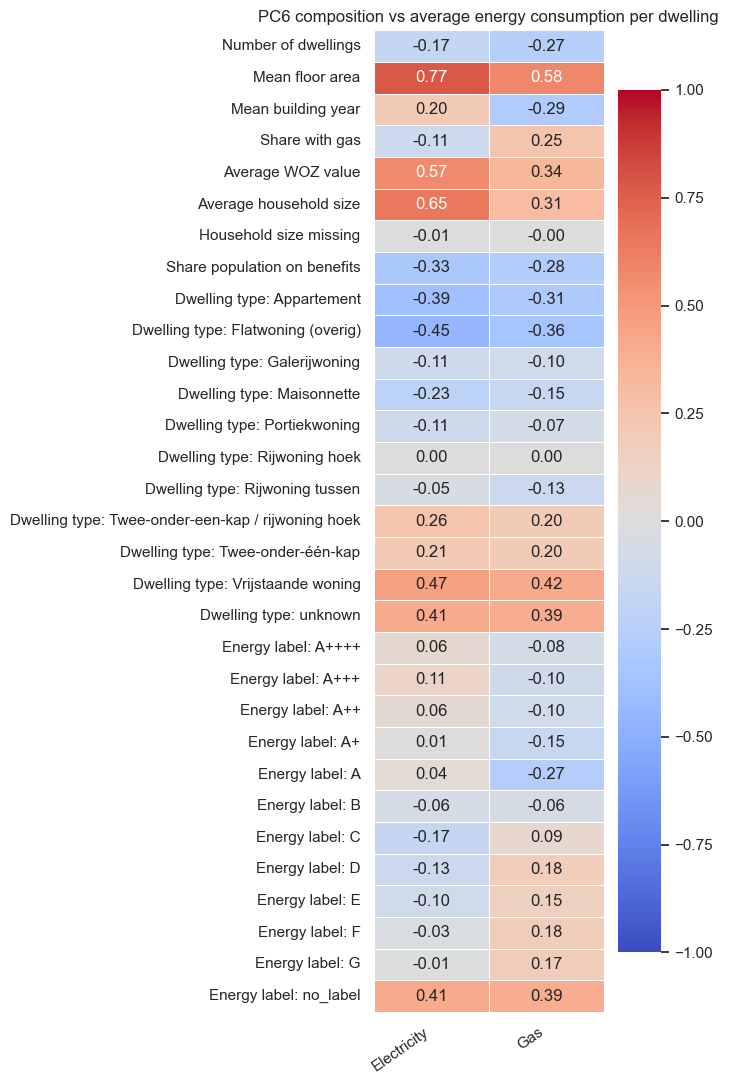

In [100]:
# ----------------------------
# 5.4B PC6 composition vs average energy
# ----------------------------

# Remove PV from energy outcomes
energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# Add dwelling-type shares
composition_vars += [
    c for c in pc6_analysis.columns
    if c.startswith("share_dwelling_type_")
]

# Add energy-label shares
composition_vars += [
    c for c in pc6_analysis.columns
    if c.startswith("share_energy_label_")
]

# Compute correlation block
corr_block = (
    pc6_analysis[
        composition_vars + energy_vars
    ]
    .corr(method="spearman")
    .loc[composition_vars, energy_vars]
)

# Readable labels
row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_block_plot = corr_block.rename(
    index=row_label_map
)

corr_block_plot.index = (
    corr_block_plot.index
    .str.replace(
        "share_dwelling_type_",
        "Dwelling type: ",
        regex=False
    )
    .str.replace(
        "share_energy_label_",
        "Energy label: ",
        regex=False
    )
)

# Rename x-axis labels
corr_block_plot = corr_block_plot.rename(
    columns={
        "kwh_avg_per_dwelling_pc6": "Electricity",
        "gas_avg_per_dwelling_pc6": "Gas"
    }
)

# Plot
plt.figure(figsize=(7, 11))

ax = sns.heatmap(
    corr_block_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.title(
    "PC6 composition vs average energy consumption per dwelling"
)

plt.tight_layout()
plt.show()

### Interpretation of Association between PC6 composition and average energy

The correlation matrix highlights how PC6 composition relates to average energy consumption per dwelling.

**Postcode size**

- `n_dwellings` shows weak correlations (electricity: -0.17, gas: -0.27), indicating that average energy largely removes the mechanical size effect.
- Larger postcode areas tend to have slightly lower consumption per dwelling, consistent with denser urban areas.

**Structural characteristics**

- `mean_floor_area` is the strongest driver (electricity: 0.77, gas: 0.58), indicating that larger dwellings consume more energy per unit.
- `mean_building_year` is negatively related to gas (-0.29), suggesting newer buildings rely less on gas.
- `share_has_gas` is positively related to gas consumption (0.25), reflecting heating system dependence.

**Socioeconomic characteristics**

- `avg_woz_value` (0.57 electricity, 0.34 gas) and `avg_household_size` (0.65 electricity, 0.31 gas) show strong positive associations with energy use.
- `share_population_on_benefits` is negatively related to energy (-0.33 electricity, -0.28 gas), indicating lower consumption in lower-income areas.
- The missing indicator has near-zero correlations, confirming its purely technical role.

**Dwelling type composition**

- High-density housing (e.g. apartments: -0.39 electricity, -0.31 gas) is associated with lower energy use.
- Low-density housing (e.g. detached: 0.47 electricity, 0.42 gas) is associated with higher energy use.
- This confirms that housing typology is a key determinant of energy intensity.

**Energy labels**

- Energy label shares show relatively weak and mixed relationships.


**Conclusion**

Average energy consumption per dwelling is primarily driven by dwelling size, housing type, and household composition. Socioeconomic factors contribute, but less strongly. The weak correlation with postcode size confirms that average energy successfully captures structural variation rather than scale effects.

### 5.4C Association between PC6 composition and total energy

As a comparison to the average per-dwelling energy analysis, we also examine how PC6 composition relates to **total energy demand** at postcode level.

The total energy indicators are:

- `kwh_total_pc6`
- `gas_total_pc6`
- `pv_total_pc6`

Unlike average energy per dwelling, total energy is expected to be strongly influenced by postcode size. Therefore, `n_dwellings` is included in the correlation matrix to make the role of PC6 scale explicit.

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear.

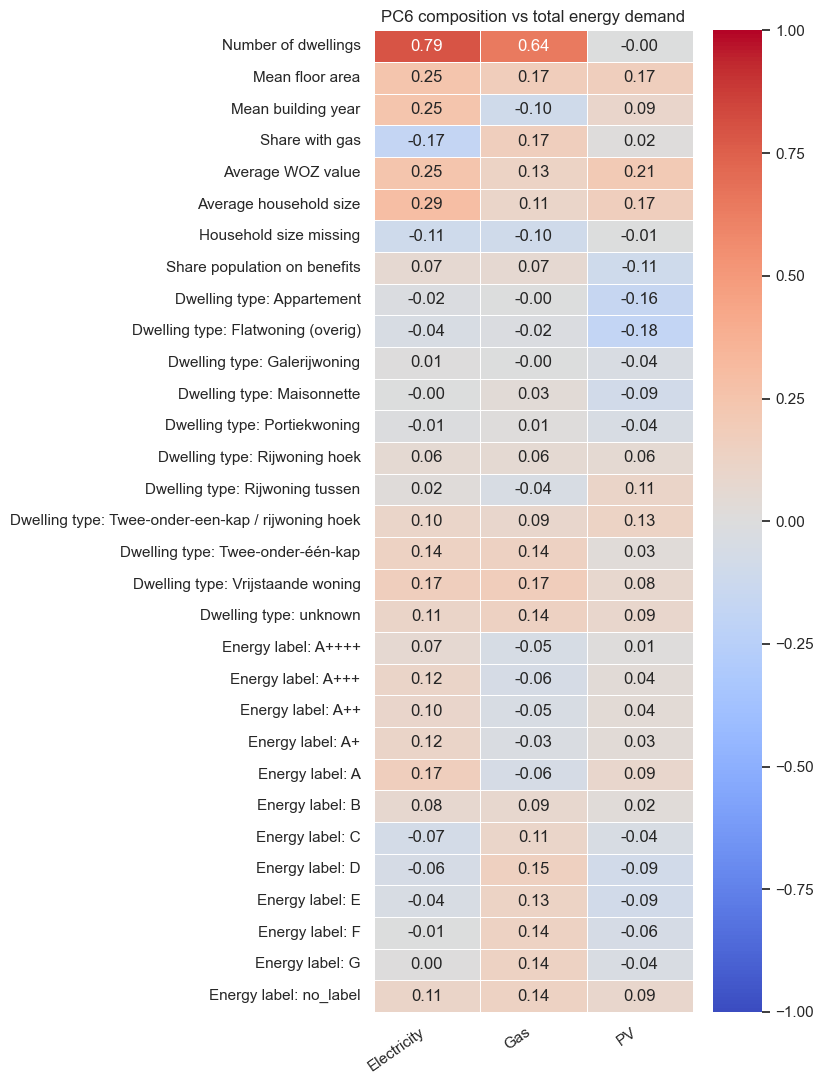

In [35]:
# ----------------------------
# 5.4C PC6 composition vs total energy
# ----------------------------

energy_total_vars = [
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_dwelling_type_")
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_energy_label_")
]

corr_total_block = (
    pc6_analysis[composition_vars + energy_total_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_total_vars]
)

row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_total_plot = corr_total_block.rename(index=row_label_map)

corr_total_plot.index = (
    corr_total_plot.index
    .str.replace("share_dwelling_type_", "Dwelling type: ", regex=False)
    .str.replace("share_energy_label_", "Energy label: ", regex=False)
)

corr_total_plot = corr_total_plot.rename(columns={
    "kwh_total_pc6": "Electricity",
    "gas_total_pc6": "Gas",
    "pv_total_pc6": "PV"
})

plt.figure(figsize=(8, 11))

ax = sns.heatmap(
    corr_total_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("PC6 composition vs total energy demand")
plt.tight_layout()
plt.show()

### Interpretation: PC6 composition vs total energy demand

The correlation patterns for total energy demand differ substantially from those observed for average energy per dwelling, primarily due to the dominant role of postcode size.

- **Postcode size dominates total energy**
  - Number of dwellings shows a very strong positive correlation with:
    - Electricity: **0.79**
    - Gas: **0.64**
  - This confirms that total energy consumption is largely driven by how many dwellings are present in a PC6 area.

- **Structural variables appear weaker**
  - Mean floor area:
    - Electricity: **0.25** (vs ~0.77 in average energy)
  - Average household size:
    - Electricity: **0.29** (vs ~0.65)
  - Average WOZ value:
    - Electricity: **0.25** (vs ~0.57)
  - These relationships are substantially attenuated, indicating that their strong effects in the previous analysis were mainly related to **energy intensity per dwelling**, not total consumption.

- **Housing typology effects are largely muted**
  - Apartment share:
    - Electricity: **−0.02**
  - Detached housing:
    - Electricity: **0.17**
  - Compared to the average-energy analysis (e.g. −0.39 for apartments, +0.47 for detached), these effects are much smaller, showing that typology mainly affects **how much each dwelling consumes**, rather than total demand at PC6 level.

- **Socioeconomic variables lose explanatory power**
  - Share population on benefits:
    - Electricity: **0.07** (previously −0.33)
  - The relationship becomes weak and even changes sign, indicating that socioeconomic effects are largely obscured when using total energy.

- **Gas infrastructure behaves differently**
  - Share with gas:
    - Gas: **0.17**
  - This remains moderately correlated, reflecting a direct link between gas connection and gas consumption, independent of postcode size.

- **PV production remains weakly related**
  - Most variables show small correlations with PV (generally |ρ| < 0.2)
  - PV appears less structurally tied to composition variables at PC6 level.

### Overall interpretation

Total energy demand primarily reflects **postcode size**, with structural and socioeconomic variables playing a secondary role. 

In contrast to average energy per dwelling:
- Relationships that previously appeared strong are largely diluted  
- Differences between housing types and socioeconomic groups become much less visible  

This confirms that total energy combines:
- a **mechanical size effect** (number of dwellings)  
- and a **structural intensity effect** (energy use per dwelling)  

As a result, total energy is less suitable for identifying underlying drivers of energy demand, while average energy per dwelling provides a clearer representation of structural and behavioral differences across PC6 areas.

## 6️⃣ PC6-level regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to electricity demand. These analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint influence of multiple housing characteristics simultaneously.

The purpose of this chapter is to estimate statistical models that relate postcode-level electricity demand to the structural and socioeconomic composition of the housing stock. Two objectives are pursued.

First, regression models are used to quantify how average dwelling size, construction year, gas availability, dwelling type composition, energy label composition, and selected CBS socioeconomic variables are associated with electricity consumption across postcode areas.

Second, the predictive performance of the preferred regression specification is evaluated out of sample and compared with a nonlinear machine-learning benchmark. This makes it possible to assess both the interpretability of the regression framework and the potential predictive gains from a more flexible nonlinear method.

The unit of analysis is the PC6 postcode area. Each observation represents one postcode area and combines information on electricity consumption, housing structure, and socioeconomic characteristics.

The dependent variable is defined as:

- `kwh_avg_per_dwelling_pc6` — average annual electricity consumption per dwelling within each PC6 area

This variable is used instead of total electricity consumption because total consumption is strongly influenced by the number of dwellings in a postcode area. By focusing on average consumption per dwelling, the analysis isolates differences in electricity intensity across postcode areas, rather than differences in postcode size.

The explanatory variables are grouped into three categories.

**Structural variables**
- average dwelling floor area  
- average construction year  
- share of dwellings connected to gas  

**Compositional variables**
- dwelling type shares at postcode level  
- energy label shares at postcode level  

**Socioeconomic variables (CBS)**
- average WOZ value  
- average household size (with missingness indicator where relevant)  
- share of population receiving social benefits  

To avoid perfect multicollinearity, one category is omitted from each set of compositional shares and serves as a reference group in the regression models.

The analysis proceeds in five steps:

1. construct the regression dataset and define the predictor matrix  
2. assess multicollinearity among explanatory variables  
3. estimate alternative regression specifications  
4. select a preferred model based on fit and residual diagnostics  
5. evaluate predictive performance and compare with a nonlinear benchmark  

This structure ensures analytical coherence. Model specification and selection are addressed first, followed by inference diagnostics for the preferred model. Finally, predictive performance is evaluated out of sample.

The results are interpreted as conditional statistical associations. They do not imply causal effects, as housing characteristics and socioeconomic variables may be jointly determined and may also reflect unobserved behavioural, technical, or local factors.

### 6.1 Regression dataset construction

In this section, the regression dataset is constructed at the PC6 level. The dataset includes postcode areas with valid electricity consumption values and all explanatory variables defined in the previous section.

The dependent variable is:

- `kwh_avg_per_dwelling_pc6` — average annual electricity consumption per dwelling

The explanatory variables include:

- structural variables (`mean_floor_area`, `mean_building_year`, `share_has_gas`)
- dwelling type shares (`share_dwelling_type_*`)
- energy label shares (`share_energy_label_*`)
- CBS socioeconomic variables (`avg_woz_value_filled`, `avg_household_size_filled`, `avg_household_size_missing`, `share_population_on_benefits_filled`)

To avoid perfect multicollinearity, one category is omitted from each set of compositional share variables and used as the reference group.

This is necessary because the dwelling type shares and energy label shares are **compositional variables**. Within each PC6, the shares across all dwelling types sum to one:

$$
\sum_j share\_dwelling\_type_{j,pc6} = 1
$$

Similarly, the energy label shares also sum to one:

$$
\sum_k share\_energy\_label_{k,pc6} = 1
$$

If all categories are included in the regression together with an intercept, one category can be perfectly predicted from the others. For example, if the shares of all dwelling types except apartments are known, then the apartment share is automatically determined as the remaining share. This creates perfect multicollinearity, also known as the dummy variable trap.

To prevent this, one category is removed from each compositional group. The omitted category becomes the **reference category**. Coefficients for the included categories are then interpreted relative to this omitted group.

For dwelling type, the omitted reference category is:

- `share_dwelling_type_Appartement`

This means that dwelling type coefficients describe how electricity consumption changes as the share of a given dwelling type increases relative to apartments.

For energy label, the omitted reference category is:

- `share_energy_label_G`

This means that energy label coefficients describe how electricity consumption changes as the share of a given energy label increases relative to label G, the lowest efficiency class.

These reference categories are chosen for interpretational convenience, but it is important to note that the specific choice of reference does not affect the overall fit or predictive performance of the regression model. Any category could be omitted without changing the model’s explanatory power, as the information contained in the full set of shares remains the same.

The choice of reference only affects how coefficients are interpreted. Each estimated coefficient measures the effect of increasing the share of a given category relative to the omitted category, holding all other variables constant.

In this analysis, the reference categories are selected to provide a meaningful and intuitive baseline for comparison. For dwelling types, `share_woning_type_Appartement` is used as the reference, representing a common and well-defined housing type. For energy labels, `share_energieklasse_G` is used as the reference, representing the least energy-efficient category.

As a result, the coefficients of the included categories can be interpreted as the change in electricity consumption associated with replacing the reference category with the given category, while keeping the overall composition fixed.

The regression matrix is constructed below.

In [68]:
# ----------------------------
# 6.1 Construct regression dataset
# ----------------------------
import statsmodels.api as sm

# Keep only valid electricity observations
reg_data = pc6_analysis[
    pc6_analysis["kwh_avg_per_dwelling_pc6"] > 0
].copy()

# ----------------------------
# Dependent variable
# ----------------------------
y = reg_data["kwh_avg_per_dwelling_pc6"]

# ----------------------------
# Identify compositional variables
# ----------------------------
dwelling_cols_full = [
    c for c in reg_data.columns if c.startswith("share_dwelling_type_")
]

label_cols_full = [
    c for c in reg_data.columns if c.startswith("share_energy_label_")
]

# ----------------------------
# Reference categories
# ----------------------------
ref_dwelling = "share_dwelling_type_Appartement"
ref_label = "share_energy_label_G"

dwelling_cols = [c for c in dwelling_cols_full if c != ref_dwelling]
label_cols = [c for c in label_cols_full if c != ref_label]

# ----------------------------
# CBS variables
# ----------------------------
cbs_vars = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# Structural variables
# ----------------------------
structural_vars = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

# ----------------------------
# Construct X matrix
# ----------------------------
X = reg_data[
    structural_vars
    + dwelling_cols
    + label_cols
    + cbs_vars
].copy()

# Add intercept
X = sm.add_constant(X)

# ----------------------------
# Diagnostics
# ----------------------------
print("Regression dataset:")
print("Observations:", X.shape[0])
print("Predictors:", X.shape[1])

display(X.head())

Regression dataset:
Observations: 234882
Predictors: 29


,const,mean_floor_area,mean_building_year,share_has_gas,share_dwelling_type_Flatwoning (overig),share_dwelling_type_Galerijwoning,share_dwelling_type_Maisonnette,share_dwelling_type_Portiekwoning,share_dwelling_type_Rijwoning hoek,share_dwelling_type_Rijwoning tussen,...,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1.0,75.615385,1789.923077,0.730769,0.307692,0.0,0.038462,0.0,0.0,0.0000,...,0.038462,0.076923,0.076923,0.153846,0.0000,0.269231,622.0,1.6,0,0.0
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.0,0.000000,0.0,0.0,0.0625,...,0.000000,0.000000,0.000000,0.000000,0.0625,0.937500,870.0,2.1,0,0.0
2,1.0,58.111111,1975.555556,0.666667,0.222222,0.0,0.111111,0.0,0.0,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.555556,559.0,1.4,0,0.0
3,1.0,85.333333,1818.750000,0.750000,0.000000,0.0,0.000000,0.0,0.0,0.0000,...,0.000000,0.166667,0.000000,0.166667,0.0000,0.666667,647.0,1.3,0,0.0
4,1.0,83.384615,1673.769231,1.000000,0.384615,0.0,0.076923,0.0,0.0,0.0000,...,0.000000,0.076923,0.000000,0.461538,0.0000,0.461538,623.0,1.8,0,0.0


### 6.2 Regression specifications

Before comparing alternative functional forms, it is useful to justify the selection of explanatory variables included in the regression framework.

The regression models combine two complementary sources of information:

1. CBS socioeconomic variables, describing demographic and socioeconomic characteristics at postcode level  
2. DEGO/VNG housing-stock variables, describing the physical composition and structural characteristics of the dwelling stock  

To assess whether the inclusion of these variable groups is empirically justified, three alternative linear specifications are estimated:

1. a model using only CBS socioeconomic variables  
2. a model using only DEGO/VNG housing-stock variables  
3. a combined model using both domains simultaneously  

The objective of this exercise is not to identify a causal hierarchy between variable groups, but rather to evaluate whether the inclusion of additional explanatory variables is supported by improvements in model performance.

The comparison is based on:

- adjusted $R^2$  
- Akaike Information Criterion (AIC)  
- Bayesian Information Criterion (BIC)  

Adjusted $R^2$ evaluates explanatory performance while accounting for model complexity. AIC and BIC additionally evaluate whether improvements in fit justify the inclusion of additional predictors.

This comparison provides a justification for the explanatory-variable framework used in the subsequent regression specifications.

In [69]:
# ----------------------------
# 6.2.1 Explanatory-variable comparison
# Contribution of CBS and DEGO/VNG variable domains
# Linear electricity models
# ----------------------------

# ----------------------------
# 1. Define variable groups
# ----------------------------

# CBS socioeconomic variables
cbs_only_vars = cbs_vars

# DEGO/VNG housing-stock variables
vng_only_vars = (
    [
        "mean_floor_area",
        "mean_building_year",
        "share_has_gas"
    ]
    + dwelling_cols
    + label_cols
)

# Combined model
combined_vars = (
    cbs_only_vars
    + vng_only_vars
)

# ----------------------------
# 2. Define dependent variable
# ----------------------------

y_domain = reg_data["kwh_avg_per_dwelling_pc6"].copy()

# ----------------------------
# 3. Construct predictor matrices
# ----------------------------

X_cbs = sm.add_constant(
    reg_data[cbs_only_vars],
    has_constant="add"
)

X_vng = sm.add_constant(
    reg_data[vng_only_vars],
    has_constant="add"
)

X_combined = sm.add_constant(
    reg_data[combined_vars],
    has_constant="add"
)

# ----------------------------
# 4. Estimate models
# ----------------------------

model_cbs = sm.OLS(y_domain, X_cbs).fit()
model_vng = sm.OLS(y_domain, X_vng).fit()
model_combined = sm.OLS(y_domain, X_combined).fit()

# ----------------------------
# 5. Build comparison table
# ----------------------------

domain_models = [
    {
        "Model": "M1",
        "Description": "CBS socioeconomic variables only",
        "Model_object": model_cbs,
        "X": X_cbs
    },
    {
        "Model": "M2",
        "Description": "DEGO/VNG housing-stock variables only",
        "Model_object": model_vng,
        "X": X_vng
    },
    {
        "Model": "M3",
        "Description": "Combined CBS and DEGO/VNG variables",
        "Model_object": model_combined,
        "X": X_combined
    }
]

domain_comparison = pd.DataFrame({
    "Model": [item["Model"] for item in domain_models],
    "Description": [item["Description"] for item in domain_models],
    "Observations": [int(item["Model_object"].nobs) for item in domain_models],
    "Predictors_including_intercept": [item["X"].shape[1] for item in domain_models],
    "Predictors_excluding_intercept": [item["X"].shape[1] - 1 for item in domain_models],
    "Adj_R2": [item["Model_object"].rsquared_adj for item in domain_models],
    "AIC": [item["Model_object"].aic for item in domain_models],
    "BIC": [item["Model_object"].bic for item in domain_models]
})

domain_comparison = domain_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Contribution of CBS and DEGO/VNG variable domains:")
display(domain_comparison)

Contribution of CBS and DEGO/VNG variable domains:


,Model,Description,Observations,Predictors_including_intercept,Predictors_excluding_intercept,Adj_R2,AIC,BIC
0,M1,CBS socioeconomic variables only,234882,5,4,0.5464,3622500.3,3622552.2
1,M2,DEGO/VNG housing-stock variables only,234882,25,24,0.6583,3556026.9,3556286.1
2,M3,Combined CBS and DEGO/VNG variables,234882,29,28,0.7177,3511173.4,3511474.0


### Interpretation of explanatory-variable comparison

The comparison indicates that both explanatory-variable domains are associated with postcode-level differences in electricity consumption.

The model using only CBS socioeconomic variables achieves an adjusted $R^2$ of approximately 0.55, suggesting that socioeconomic differences between postcode areas are related to variation in electricity consumption.

The model using only DEGO/VNG housing-stock variables performs better, achieving an adjusted $R^2$ of approximately 0.66. This suggests that housing-stock composition and structural dwelling characteristics are strongly associated with electricity demand patterns at postcode level.

The combined specification performs best across all evaluation metrics, achieving:

- an adjusted $R^2$ of approximately 0.72  
- the lowest AIC value  
- the lowest BIC value  

The improvement in adjusted $R^2$, together with the lower AIC and BIC values, indicates that the additional variables improve model fit sufficiently to justify the increase in model complexity.

These results suggest that the two variable domains contain complementary information:

- CBS variables describe socioeconomic and demographic characteristics  
- DEGO/VNG variables describe structural and housing-stock characteristics  

The combined specification is therefore retained as the explanatory-variable framework for the subsequent regression specifications.

### 6.2.2 Alternative functional-form specifications

Having established the explanatory-variable framework, the next step is to determine the most appropriate functional form for modelling postcode-level electricity demand.

The relationship between electricity consumption and the explanatory variables is not necessarily linear in absolute terms. In particular, postcode-level electricity consumption exhibits right-skewness, with a relatively small number of postcode areas displaying substantially higher consumption levels than the majority of observations.

To assess whether functional-form transformations improve model behaviour, three alternative Ordinary Least Squares (OLS) specifications are estimated:

1. a linear model estimated in levels  
2. a log-level model with a logarithmic dependent variable  
3. a log-log model with both the dependent variable and average floor area expressed in logarithmic form  

The three specifications are estimated using the same explanatory-variable framework and the same set of postcode areas, ensuring direct comparability between models.

The specifications differ in how they represent the relationship between electricity consumption and the explanatory variables:

- The **linear model** estimates relationships in absolute units and provides a directly interpretable baseline specification.  
- The **log-level model** transforms the dependent variable to reduce skewness and place greater emphasis on proportional rather than absolute differences.  
- The **log-log model** additionally transforms average floor area, allowing the relationship between dwelling size and electricity consumption to be interpreted in elasticity terms.  

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
\begin{equation*}
\begin{split}
kwh_{avg,pc6} &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6} \\
&\quad + \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1$–$\beta_3$ are coefficients on structural and infrastructure variables  
- $\beta_{4j}$ and $\beta_{5k}$ are coefficients on dwelling-type and energy-label shares  
- $\beta_6$–$\beta_9$ are coefficients on CBS socioeconomic variables  
- $\varepsilon_{pc6}$ is the error term  



Estimation in levels provides a straightforward, interpretable baseline. Right-skewed dependent variables may require transformations, motivating the alternative specifications.

In [70]:
# ----------------------------
# 6.2.2 Linear OLS specification
# ----------------------------

y_linear = y.copy()
X_linear = X.copy()

model_linear = sm.OLS(y_linear, X_linear).fit()

print("Linear model (levels) results:")
print(model_linear.summary())

Linear model (levels) results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.718
Model:                                  OLS   Adj. R-squared:                  0.718
Method:                       Least Squares   F-statistic:                 2.132e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              01:35:38   Log-Likelihood:            -1.7556e+06
No. Observations:                    234882   AIC:                         3.511e+06
Df Residuals:                        234853   BIC:                         3.511e+06
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.

#### 6.2.3 Log-level OLS specification

The dependent variable `kwh_avg_per_dwelling_pc6` is right-skewed, meaning that some postcode areas have substantially higher average electricity consumption than the majority. Estimating in levels may overweight these observations.

The second model transforms the dependent variable using the natural logarithm:

$$
\begin{equation*}
\begin{split}
\log(kwh\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

The dependent variable is logarithmically transformed in order to improve the symmetry of the electricity-consumption distribution and, more importantly, the symmetry of the regression residuals.

In [71]:
# ----------------------------
# 6.2.3 Log-level OLS specification
# ----------------------------

y_log = np.log(y)
X_log = X.copy()

model_log = sm.OLS(y_log, X_log).fit()

print("Log-level model results:")
print(model_log.summary())

Log-level model results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.712
Model:                                  OLS   Adj. R-squared:                  0.712
Method:                       Least Squares   F-statistic:                 2.074e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              01:35:39   Log-Likelihood:                 85858.
No. Observations:                    234882   AIC:                        -1.717e+05
Df Residuals:                        234853   BIC:                        -1.714e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
-

Inspection of the residual behaviour of the log-level specification is also useful for guiding further model development. If systematic structure remains after log-transforming the dependent variable, this may indicate that one or more explanatory variables still enter the model in an empirically restrictive functional form.

#### 6.2.4 Log-log OLS specification with logarithmic floor area


The third model logs both average electricity consumption per dwelling and average floor area:

$$
\begin{equation*}
\begin{split}
\log(kwh\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 \log(mean\_floor\_area_{pc6})
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

In this specification, average floor area is additionally logarithmically transformed in order to allow for non-linear scaling relationships between dwelling size and residential electricity consumption. This transformation reflects the expectation that increases in dwelling floor area may not correspond to constant absolute increases in electricity demand across the full range of dwelling sizes. Instead, the relationship may scale proportionally, particularly between smaller and larger residential dwellings.

In [72]:
# ----------------------------
# 6.2.4 Log-log OLS specification
# ----------------------------

y_loglog = np.log(y)

X_loglog = X.copy()
X_loglog["log_mean_floor_area"] = np.log(X_loglog["mean_floor_area"])
X_loglog = X_loglog.drop(columns=["mean_floor_area"])

model_loglog = sm.OLS(y_loglog, X_loglog).fit()

print("Log-log model results:")
print(model_loglog.summary())

Log-log model results:
                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.720
Model:                                  OLS   Adj. R-squared:                  0.720
Method:                       Least Squares   F-statistic:                 2.159e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              01:35:39   Log-Likelihood:                 89214.
No. Observations:                    234882   AIC:                        -1.784e+05
Df Residuals:                        234853   BIC:                        -1.781e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---

### 6.3 Comparison and selection of the preferred regression specification

The three candidate specifications estimated in Section 6.2 are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand.

The comparison is based on four complementary diagnostic dimensions.

**1. Model fit**

Model fit is assessed using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ evaluates explanatory power while accounting for model complexity. AIC and BIC assess the trade-off between model fit and parsimony, with lower values indicating a more favourable balance.

It is important to note that AIC and BIC depend on the scale of the dependent variable. Since the linear model is estimated in levels and the alternative specifications are estimated in logarithmic form, these criteria are not directly comparable across all models. They are reported for completeness, but are primarily used to compare the log-based specifications.

**2. Residual distribution**

Residual histograms are used to assess whether the specification reduces skewness and the influence of extreme observations. Both the full residual range and the central 98\% of the residual distribution are examined to distinguish overall tail behaviour from the dominant error structure.

**3. Residual patterns**

Residuals are plotted against fitted values to examine whether the variance of the residuals remains approximately stable across the prediction range and whether systematic misspecification remains visible.

Because the dataset contains a very large number of postcode observations, standard scatter plots may become visually dense and suffer from overplotting. Therefore, hexbin residual-density plots are additionally used. These plots aggregate observations into hexagonal bins and visualize the local density of residuals across the fitted-value range, allowing systematic patterns and heteroskedasticity to be identified more clearly.

To ensure comparability between specifications estimated on the same scale, residual-versus-fitted plots and hexbin density plots are displayed using consistent axis limits.

**4. Observed versus fitted values**

Observed-versus-fitted plots are additionally used to evaluate how closely predicted electricity consumption aligns with observed postcode-level electricity demand.

Both scatter plots and hexbin density plots are presented. The 45-degree reference line represents perfect prediction. Deviations from this line indicate prediction error. As with the residual diagnostics, hexbin plots provide a clearer visualization of model behaviour in dense regions of the data.

Taken together, these diagnostics are used to guide the selection of a preferred regression specification.

Model comparison:


,Model,Observations,Adj_R2,AIC,BIC
0,Linear,234882,0.7177,3511173.4,3511474.0
1,Log-level,234882,0.7120,-171657.3,-171356.6
2,Log-log,234882,0.7202,-178370.8,-178070.2


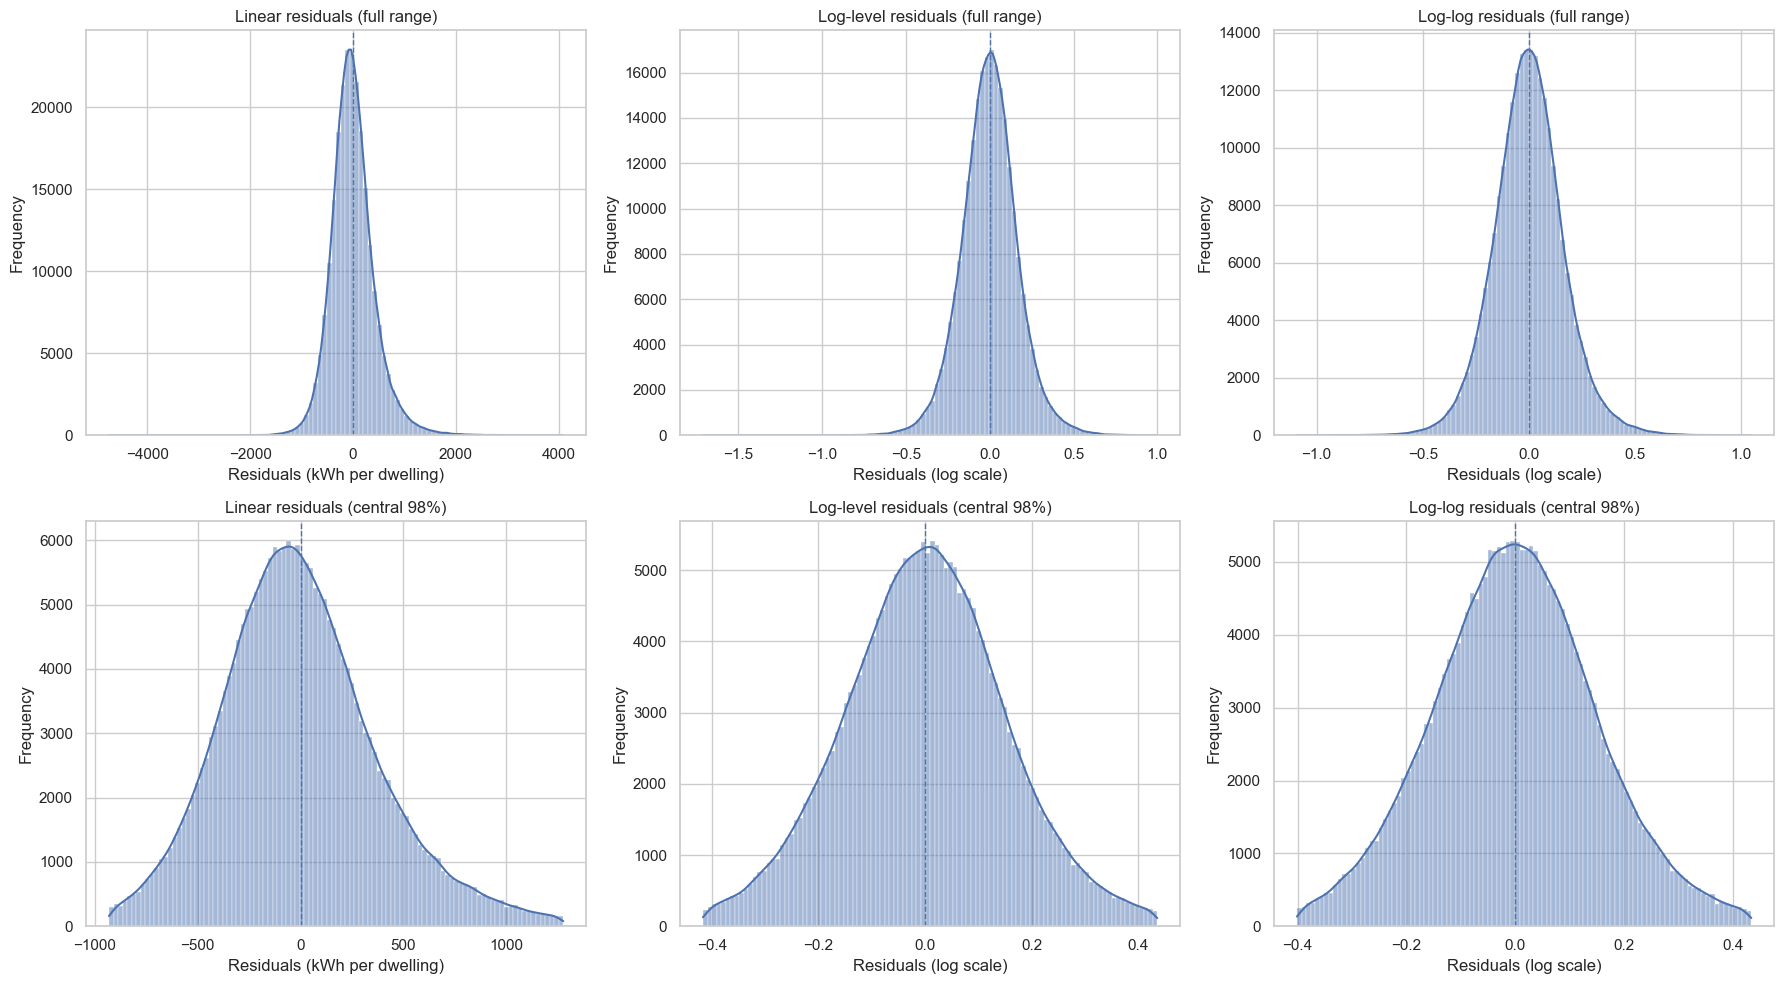

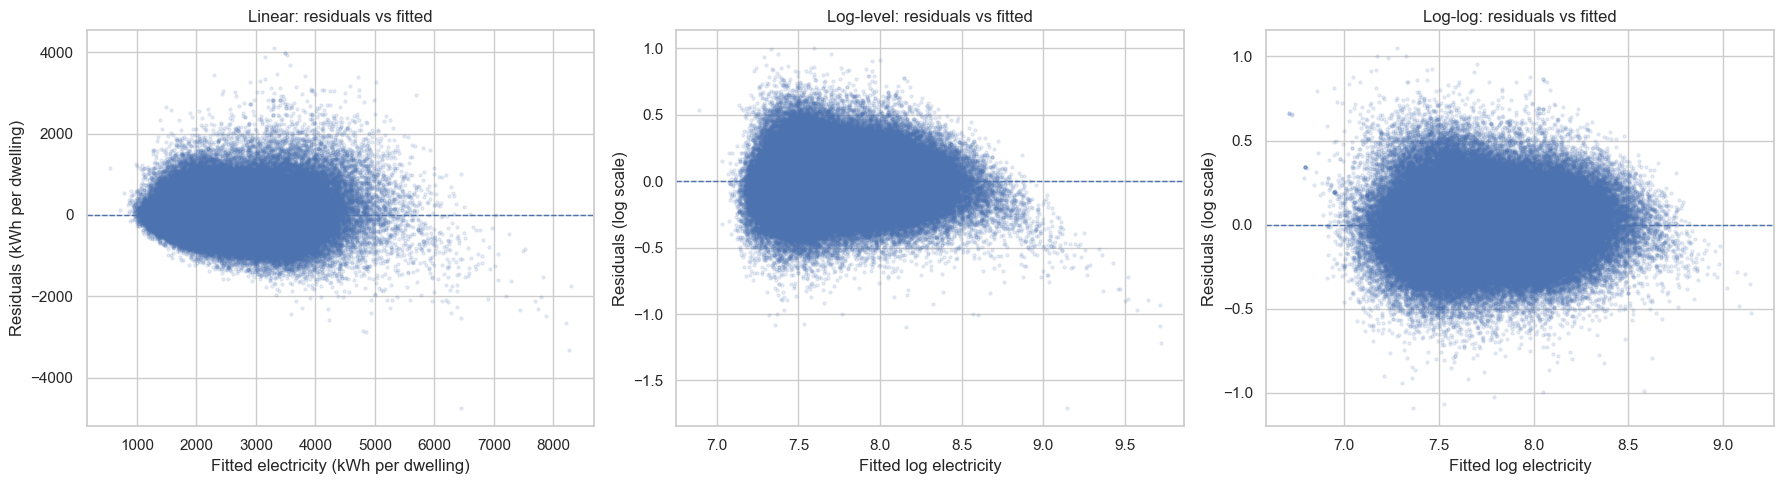

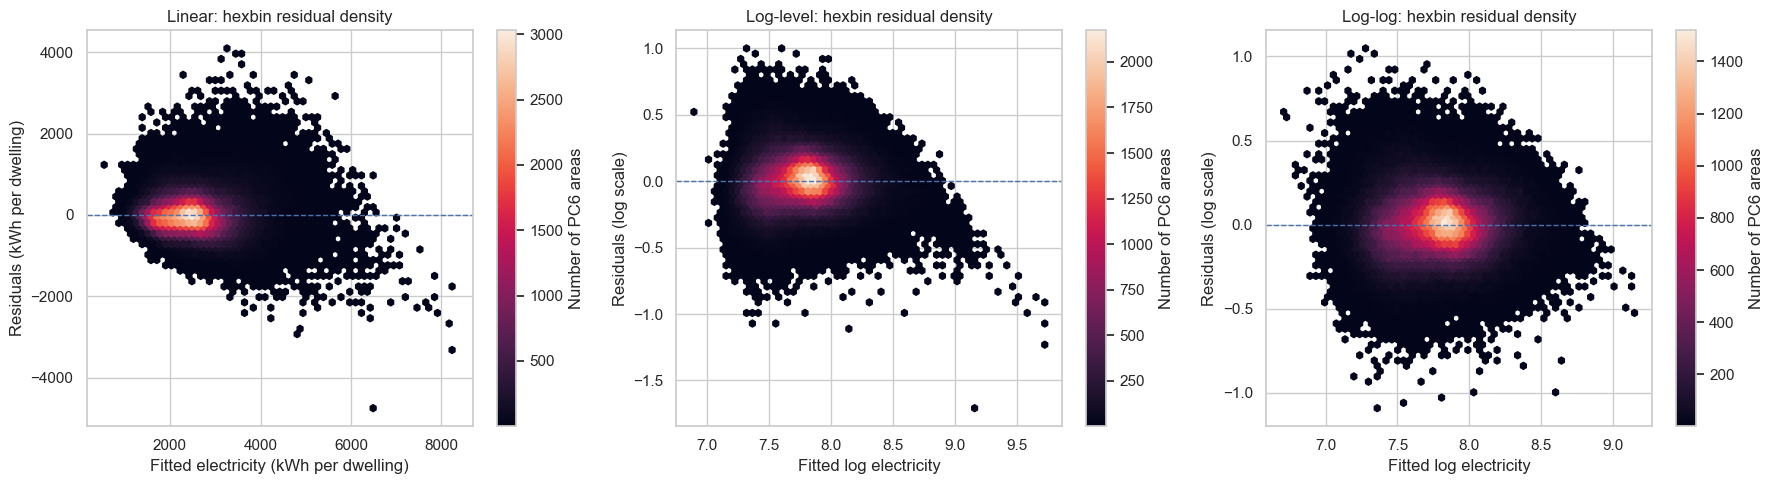

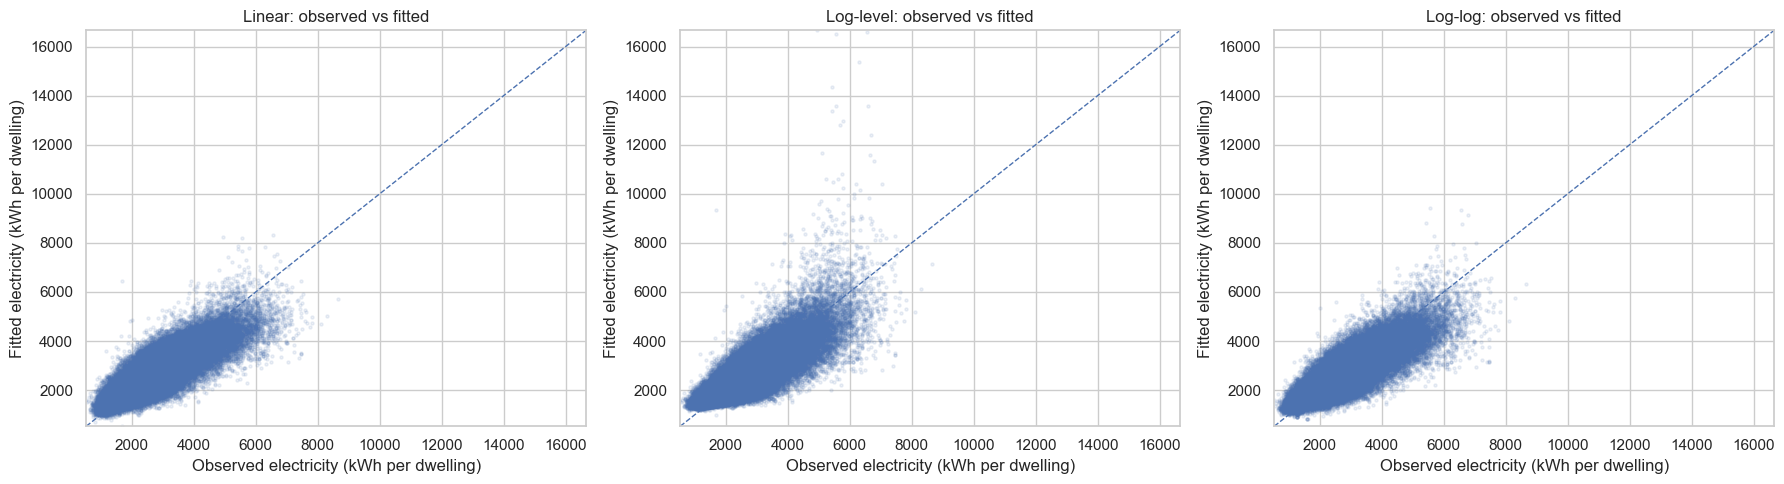

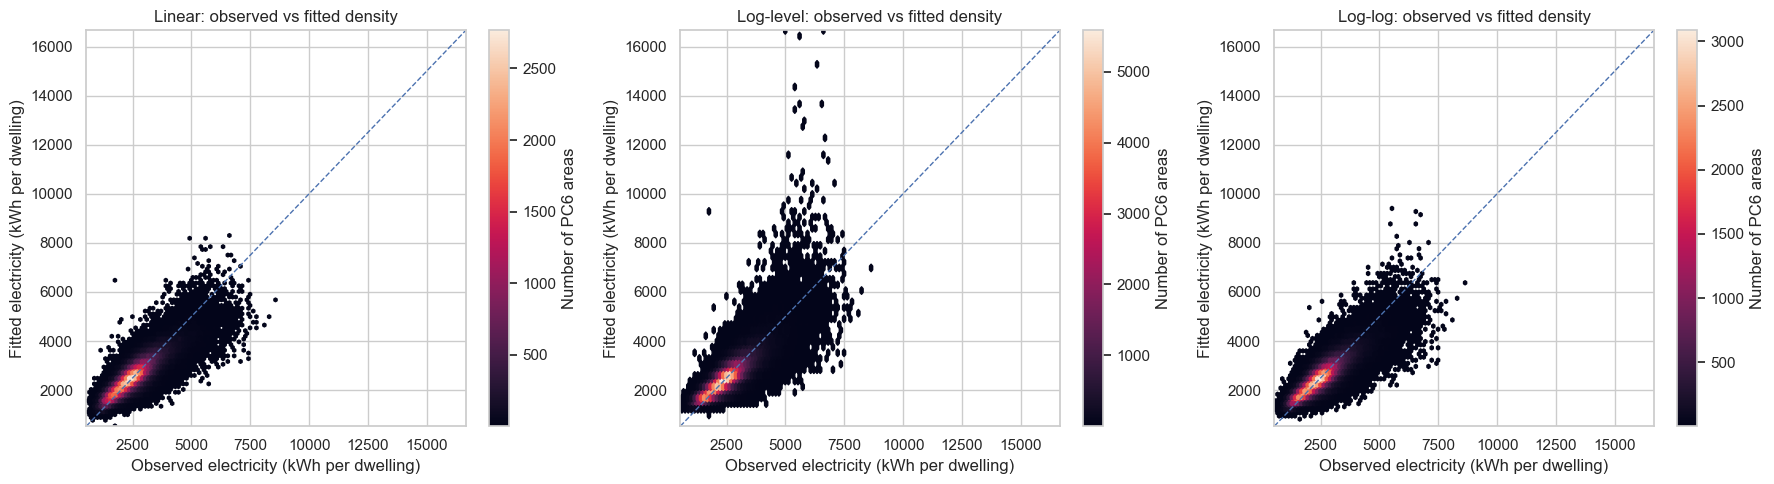

In [73]:
# ----------------------------
# 6.3 Model comparison and residual diagnostics
# ----------------------------

# ----------------------------
# 1. Model comparison table
# ----------------------------

comparison_stats = pd.DataFrame({
    "Model": ["Linear", "Log-level", "Log-log"],
    "Observations": [
        int(model_linear.nobs),
        int(model_log.nobs),
        int(model_loglog.nobs)
    ],
    "Adj_R2": [
        model_linear.rsquared_adj,
        model_log.rsquared_adj,
        model_loglog.rsquared_adj
    ],
    "AIC": [
        model_linear.aic,
        model_log.aic,
        model_loglog.aic
    ],
    "BIC": [
        model_linear.bic,
        model_log.bic,
        model_loglog.bic
    ]
})

comparison_stats = comparison_stats.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Model comparison:")
display(comparison_stats)

# ----------------------------
# 2. Store model metadata
# ----------------------------

models = [
    {
        "name": "Linear",
        "model": model_linear,
        "scale": "levels",
        "resid_label": "Residuals (kWh per dwelling)",
        "fitted_label": "Fitted electricity (kWh per dwelling)"
    },
    {
        "name": "Log-level",
        "model": model_log,
        "scale": "log",
        "resid_label": "Residuals (log scale)",
        "fitted_label": "Fitted log electricity"
    },
    {
        "name": "Log-log",
        "model": model_loglog,
        "scale": "log",
        "resid_label": "Residuals (log scale)",
        "fitted_label": "Fitted log electricity"
    }
]

# ----------------------------
# 3. Residual histograms: full range and central 98%
# ----------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, item in enumerate(models):

    residuals = item["model"].resid

    # Full range
    sns.histplot(
        residuals,
        bins=100,
        kde=True,
        ax=axes[0, i]
    )

    axes[0, i].axvline(0, linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{item['name']} residuals (full range)")
    axes[0, i].set_xlabel(item["resid_label"])
    axes[0, i].set_ylabel("Frequency")

    # Central 98%
    r_min = residuals.quantile(0.01)
    r_max = residuals.quantile(0.99)

    sns.histplot(
        residuals[
            (residuals >= r_min)
            & (residuals <= r_max)
        ],
        bins=100,
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].axvline(0, linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{item['name']} residuals (central 98%)")
    axes[1, i].set_xlabel(item["resid_label"])
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# ----------------------------
# 4. Residuals vs fitted values
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, models):

    fitted = item["model"].fittedvalues
    residuals = item["model"].resid

    ax.scatter(
        fitted,
        residuals,
        s=5,
        alpha=0.12
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: residuals vs fitted")
    ax.set_xlabel(item["fitted_label"])
    ax.set_ylabel(item["resid_label"])

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Hexbin residual density plots
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, models):

    fitted = item["model"].fittedvalues
    residuals = item["model"].resid

    hb = ax.hexbin(
        fitted,
        residuals,
        gridsize=60,
        mincnt=1
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: hexbin residual density")
    ax.set_xlabel(item["fitted_label"])
    ax.set_ylabel(item["resid_label"])

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Observed vs fitted values
# Original electricity models
# ----------------------------

observed_fitted_models = [
    {
        "name": "Linear",
        "y_true": y_linear,
        "y_pred": model_linear.fittedvalues
    },
    {
        "name": "Log-level",
        "y_true": y_linear,
        "y_pred": np.exp(model_log.fittedvalues)
    },
    {
        "name": "Log-log",
        "y_true": y_linear,
        "y_pred": np.exp(model_loglog.fittedvalues)
    }
]

# Common axis limits
all_true = np.concatenate([
    np.asarray(m["y_true"])
    for m in observed_fitted_models
])

all_pred = np.concatenate([
    np.asarray(m["y_pred"])
    for m in observed_fitted_models
])

axis_min = min(all_true.min(), all_pred.min())
axis_max = max(all_true.max(), all_pred.max())

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, observed_fitted_models):

    ax.scatter(
        item["y_true"],
        item["y_pred"],
        s=5,
        alpha=0.10
    )

    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

    ax.set_title(f"{item['name']}: observed vs fitted")
    ax.set_xlabel("Observed electricity (kWh per dwelling)")
    ax.set_ylabel("Fitted electricity (kWh per dwelling)")

plt.tight_layout()
plt.show()

# Hexbin observed vs fitted plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, observed_fitted_models):

    hb = ax.hexbin(
        item["y_true"],
        item["y_pred"],
        gridsize=60,
        mincnt=1
    )

    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

    ax.set_title(f"{item['name']}: observed vs fitted density")
    ax.set_xlabel("Observed electricity (kWh per dwelling)")
    ax.set_ylabel("Fitted electricity (kWh per dwelling)")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Model Comparison Interpretation

The three regression specifications are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand. The comparison is based on four complementary dimensions:

1. model fit metrics  
2. residual distributions  
3. residual patterns  
4. observed-versus-fitted behaviour  

#### 6.3.1 Model fit: Adjusted $R^2$, AIC and BIC

| Model | Adj $R^2$ | AIC | BIC |
|-------|----------|-----|-----|
| Linear | 0.7177 | 3.511e+06 | 3.511e+06 |
| Log-level | 0.7120 | -1.717e+05 | -1.714e+05 |
| Log-log | 0.7202 | -1.784e+05 | -1.781e+05 |

The three metrics capture different aspects of model performance.

- **Adjusted $R^2$** measures the proportion of variation in electricity consumption explained by the model, while accounting for the number of predictors. Higher values indicate better explanatory power.  
- **AIC (Akaike Information Criterion)** evaluates the trade-off between model fit and complexity. Lower values indicate a more efficient model.  
- **BIC (Bayesian Information Criterion)** is similar to AIC but penalizes model complexity more strongly.  

The results show that all three models achieve similar explanatory power, with adjusted $R^2$ values around 0.71–0.72. The log-log model performs slightly better in terms of adjusted $R^2$.

AIC and BIC are substantially lower for the log-based models compared to the linear model. However, these values are not directly comparable across different dependent-variable transformations. Therefore, AIC and BIC comparisons are primarily meaningful between the log-level and log-log specifications. Within this group, the log-log model provides the best fit.

Overall, based on model fit alone, differences between the specifications are relatively modest, and additional diagnostics are required.

#### 6.3.2 Residual distributions

Residuals represent the difference between observed and predicted electricity consumption:

$$
\varepsilon = y_{\text{observed}} - y_{\text{predicted}}
$$

They provide insight into how the model makes errors.

- A **positive residual** indicates that the model underestimates consumption  
- A **negative residual** indicates that the model overestimates consumption  

The distribution of residuals reveals whether errors are balanced and whether extreme observations dominate the model.

The **linear model** exhibits a relatively wide and skewed residual distribution. Even when focusing on the central range, the distribution shows a longer right tail, indicating that the model frequently underestimates high-consumption postcode areas.

The **log-level model** substantially improves the residual distribution. Residuals become more concentrated around zero and more symmetric, indicating that the logarithmic transformation reduces the influence of extreme observations.

The **log-log model** provides the most symmetric and tightly concentrated residual distribution. The shape is closer to a bell curve, indicating smaller and more balanced prediction errors.

This improvement occurs because logarithmic transformations shift the model from absolute errors toward proportional errors, treating low- and high-consumption postcode areas more consistently.

#### 6.3.3 Residual patterns

Residuals are also examined against fitted values to assess whether model errors depend systematically on the level of predicted consumption.

Two types of visualizations are considered:

- **Scatter plots**, where each point represents a postcode area  
- **Hexbin (density) plots**, where observations are aggregated into hexagonal bins and color indicates local density  

With approximately 235,000 observations, scatter plots suffer from substantial overplotting. Many points overlap, especially in dense regions, making it difficult to distinguish whether a region contains hundreds or tens of thousands of observations. As a result, important patterns such as heteroskedasticity or clustering can become visually obscured.

Hexbin plots address this limitation by aggregating observations and revealing data density explicitly. Darker regions correspond to areas with a high concentration of postcode areas, allowing the main residual structure to become more visible.

The **linear model** shows a clear increase in residual spread as fitted values increase. In the scatter plot, this appears as a diffuse cloud, while the hexbin plot reveals a widening fan shape. This indicates heteroskedasticity, meaning that prediction errors increase for higher electricity-consumption levels.

The **log-level model** reduces this effect. The residual spread becomes more stable across the fitted range, indicating improved model behaviour relative to the linear specification.

The **log-log model** shows the most stable residual structure. In the hexbin plot, residuals form a tighter and more symmetric pattern around zero, with a more constant spread across fitted values. This suggests that the log-log specification captures proportional relationships more effectively and reduces systematic error patterns.

#### 6.3.4 Observed-versus-fitted behaviour

Observed-versus-fitted plots provide an additional diagnostic by directly comparing predicted electricity consumption with observed electricity consumption.

A perfectly calibrated model would place all observations on the 45-degree line:

$$
y_{\text{predicted}} = y_{\text{observed}}
$$

The **linear model** follows the overall structure of the data reasonably well, but prediction dispersion increases at higher electricity-consumption levels.

The **log-level model** produces several extreme fitted values substantially above the observed range. Inspection of these observations shows that they are associated with postcode areas exhibiting extremely large average dwelling floor areas.

Because the log-level specification includes floor area in levels rather than logarithmic form, unusually large floor-area values can generate disproportionately large fitted values after exponentiation back to the original electricity-consumption scale.

The **log-log model** substantially mitigates this issue. By modelling floor area logarithmically, the influence of extreme floor-area observations is compressed, resulting in more stable fitted-value behaviour and fewer unrealistic high-consumption predictions.

The observed-versus-fitted diagnostics therefore provide additional empirical support for selecting the log-log specification as the preferred model.

#### Overall assessment

The comparison leads to several conclusions:

1. All models achieve broadly similar explanatory power in terms of adjusted $R^2$  
2. The log-log model performs best among the log-based specifications in terms of AIC and BIC  
3. Residual distributions improve substantially when moving from linear to log-based models  
4. The log-log model produces the most symmetric and concentrated residual distributions  
5. Residual patterns indicate that logarithmic transformations reduce heteroskedasticity and improve model stability  
6. Hexbin plots provide a substantially clearer representation of residual structure than scatter plots in very large datasets  
7. Observed-versus-fitted diagnostics reveal that the log-level specification is sensitive to extreme floor-area observations, while the log-log model remains substantially more stable  

While the linear model is straightforward to interpret in absolute terms, it struggles to capture variation consistently across low- and high-consumption postcode areas. The log-level specification improves residual behaviour but remains sensitive to extreme structural observations.

The log-log model therefore provides the strongest overall balance between explanatory power, residual behaviour, stability, and interpretability. It is consequently selected as the preferred specification for the remainder of the analysis.

### 6.4 Multicollinearity assessment

Multicollinearity arises when explanatory variables are strongly correlated with each other. In such cases, it becomes difficult to isolate the individual effect of each variable, and the variance of the estimated coefficients may increase.

Importantly, multicollinearity does **not bias** the estimated coefficients or affect the overall fit of the model. However, it can lead to:

- inflated standard errors  
- unstable coefficient estimates  
- sensitivity to small changes in the data  

This issue is particularly relevant in the present analysis due to the inclusion of **compositional variables**, such as dwelling-type shares and energy-label shares. By construction, these variables are interdependent, as their sum within each postcode area is equal to one.

To quantify the severity of multicollinearity, **Variance Inflation Factors (VIF)** are computed for the explanatory variables.

The VIF for a predictor $x_j$ is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is obtained by regressing $x_j$ on all other predictors.

The VIF measures how much the variance of a coefficient is inflated due to correlation with other variables. Common thresholds are:

- VIF < 5 → limited multicollinearity  
- 5 ≤ VIF < 10 → moderate multicollinearity  
- VIF ≥ 10 → strong multicollinearity  

In the following, VIF values are computed for the explanatory variables of the preferred log-log model.

---

The VIF diagnostic is computed using the explanatory-variable matrix of the preferred log-log model, `X_loglog`.

This matrix already contains the final regression variables exactly as used in the preferred model. Therefore, the VIF analysis is applied to the same predictors used in estimation.

No additional dummy-variable creation is required at this stage. The categorical dwelling type and energy label variables have already been transformed into postcode-level composition shares:

- `share_dwelling_type_*`
- `share_energy_label_*`

These variables behave like dummy-derived composition variables at PC6 level. For example, instead of a dwelling-level dummy indicating whether one dwelling is detached, the regression uses the share of detached dwellings within the PC6 area.

Because dwelling-type shares sum to one and energy-label shares also sum to one, one category from each group was omitted before regression:

- dwelling type reference: `share_dwelling_type_Appartement`
- energy label reference: `share_energy_label_G`

This avoids perfect multicollinearity, also known as the dummy variable trap. However, remaining share variables may still be correlated with each other, so VIF is still useful for assessing the severity of multicollinearity.

The intercept column `const` is excluded from the VIF table because VIF is interpreted for explanatory variables, not for the constant term.

VIF is deterministic. It does not depend on a random seed, because it is calculated from auxiliary regressions using the fixed predictor matrix. Therefore, the VIF values will be the same every time as long as the input data and selected variables remain unchanged.

In [74]:
# ----------------------------
# 6.4 VIF diagnostics for preferred log-log model
# ----------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the predictor matrix from the preferred log-log model
X_vif = X_loglog.copy()

# Remove intercept because VIF is interpreted for explanatory variables only
X_vif_no_const = X_vif.drop(columns=["const"], errors="ignore")

# Safety check: keep only numeric columns
X_vif_no_const = X_vif_no_const.select_dtypes(include=[np.number])

# Compute VIF for all explanatory variables
vif_results = pd.DataFrame({
    "Variable": X_vif_no_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_no_const.values, i)
        for i in range(X_vif_no_const.shape[1])
    ]
})

# Add variable group for interpretation
def classify_vif_variable(var):
    if var == "log_mean_floor_area":
        return "Structural"
    elif var == "mean_building_year":
        return "Structural"
    elif var == "share_has_gas":
        return "Infrastructure"
    elif var.startswith("share_dwelling_type_"):
        return "Dwelling type share"
    elif var.startswith("share_energy_label_"):
        return "Energy label share"
    elif var in [
        "avg_woz_value_filled",
        "avg_household_size_filled",
        "avg_household_size_missing",
        "share_population_on_benefits_filled"
    ]:
        return "CBS socioeconomic"
    else:
        return "Other"

vif_results["Group"] = vif_results["Variable"].apply(classify_vif_variable)

# Sort by VIF, highest first
vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

# Round for readability
vif_results["VIF"] = vif_results["VIF"].round(2)

display(vif_results)

,Variable,VIF,Group
0,share_energy_label_no_label,1085.62,Energy label share
1,share_dwelling_type_unknown,1004.37,Dwelling type share
2,mean_building_year,825.20,Structural
3,log_mean_floor_area,676.91,Structural
4,share_energy_label_A,38.17,Energy label share
5,share_energy_label_C,27.36,Energy label share
6,avg_household_size_filled,26.78,CBS socioeconomic
7,share_energy_label_B,15.09,Energy label share
8,share_has_gas,14.60,Infrastructure
9,share_energy_label_D,8.61,Energy label share


### Interpretation Multicollinearity assessment (VIF)

Variance Inflation Factors (VIF) are used to assess the degree of multicollinearity among the explanatory variables in the preferred log-log specification. High multicollinearity can inflate the variance of coefficient estimates and make individual coefficients difficult to interpret.

The VIF results reveal three distinct patterns.

First, several variables exhibit extremely high VIF values. In particular, `share_energy_label_no_label` and `share_dwelling_type_unknown` have VIF values above 1000, while structural variables such as `mean_building_year` and `log_mean_floor_area` also display very high values. These large VIFs are primarily driven by the compositional structure of the data. Energy label shares and dwelling type shares sum to one within each postcode area, meaning that the included categories are mechanically dependent on each other. Even after omitting a reference category, strong linear relationships remain between the included shares, leading to inflated VIF values.

Second, moderate to high VIF values are observed for several energy label variables (`A`, `B`, `C`) and for variables such as `avg_household_size_filled` and `share_has_gas`. These values reflect genuine correlation between housing characteristics and socioeconomic conditions. For example, larger households tend to be associated with specific dwelling types and energy labels, which creates correlation across explanatory variables.

Third, most remaining variables exhibit low VIF values (below 5), indicating limited multicollinearity and stable coefficient estimation for these predictors.

Importantly, the presence of high VIF values in this context does not invalidate the regression model. Multicollinearity does not bias coefficient estimates, but it can increase their variance and reduce the precision of individual coefficient estimates. Given the compositional nature of dwelling type and energy label shares, high VIF values are expected and unavoidable.

As a result, coefficients on highly collinear variables should be interpreted with caution at the individual level. However, the overall model fit and the combined effect of related variables remain informative. The regression model therefore remains suitable for identifying general patterns in electricity consumption, while avoiding overly precise interpretation of individual compositional coefficients.

### 6.5 Out-of-sample predictive assessment of the preferred regression model

The previous sections evaluated model adequacy primarily using in-sample criteria such as Adjusted $R^2$, AIC, BIC, and residual diagnostics. These metrics are useful for comparing candidate specifications, but they do not directly indicate how well the preferred model generalizes to unseen data.

To assess out-of-sample predictive performance, the preferred regression specification is evaluated using **10-fold cross-validation**. In this procedure, the dataset is partitioned into ten approximately equal folds. For each iteration, the model is trained on nine folds and evaluated on the remaining fold. This process is repeated until each fold has served once as the validation sample.

The evaluation metrics are the **mean squared error (MSE)**, **root mean squared error (RMSE)**, and **mean absolute error (MAE)**.

The mean squared error is defined as:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

The root mean squared error is defined as:

$$
RMSE = \sqrt{MSE}
$$

The mean absolute error is defined as:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

where:

- $y_i$ is the observed value  
- $\hat{y}_i$ is the predicted value  
- $n$ is the number of validation observations  

Because the preferred regression model is estimated in log space, MSE, RMSE, and MAE are first evaluated in log space:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2}
$$

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |\log(y_i) - \log(\hat{y}_i)|
$$

For interpretability, prediction errors are also transformed back to the original electricity-consumption scale and reported in:

- kWh per dwelling  
- percentage terms  

This provides both an absolute and a relative interpretation of predictive accuracy.

To provide a reference point for interpretation, the regression model is compared with a **naive baseline predictor (dummy model)**. This dummy model ignores all explanatory variables and simply predicts the **mean value** of the dependent variable ($\log(\text{kWh per dwelling})$) for every postcode area. Any reduction in MSE, RMSE, and MAE achieved by the preferred model relative to this baseline demonstrates that it captures meaningful variation in electricity consumption beyond the overall average, validating its predictive capability.

In [75]:
# ----------------------------
# 6.5 Out-of-sample predictive assessment
# ----------------------------

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1. Cross-validation setup
# ----------------------------

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Use preferred log-log specification
X_cv = X_loglog.copy()
y_cv_log = y_loglog.copy()

# sklearn LinearRegression adds its own intercept
if "const" in X_cv.columns:
    X_cv_sklearn = X_cv.drop(columns=["const"]).copy()
else:
    X_cv_sklearn = X_cv.copy()

# ----------------------------
# 2. Cross-validated predictions
# ----------------------------

ols_cv = LinearRegression()

y_pred_log_arr = cross_val_predict(
    ols_cv,
    X_cv_sklearn,
    y_cv_log,
    cv=kf,
    n_jobs=-1
)

y_true_log_arr = y_cv_log.values

# ----------------------------
# 3. Baseline model
# ----------------------------

baseline_pred_log_arr = np.repeat(
    y_cv_log.mean(),
    len(y_cv_log)
)

# ----------------------------
# 4. Back-transform to original electricity scale
# ----------------------------

y_true_kwh_arr = np.exp(y_true_log_arr)

y_pred_kwh_arr = np.exp(y_pred_log_arr)

baseline_pred_kwh_arr = np.exp(
    baseline_pred_log_arr
)

# ----------------------------
# 5. Helper function
# ----------------------------

def calculate_metrics(
    model_name,
    y_true_log,
    y_pred_log,
    y_true_kwh,
    y_pred_kwh
):

    # Log-space metrics
    mse_log = mean_squared_error(
        y_true_log,
        y_pred_log
    )

    rmse_log = np.sqrt(mse_log)

    mae_log = mean_absolute_error(
        y_true_log,
        y_pred_log
    )

    # Absolute metrics in kWh
    mse_kwh = mean_squared_error(
        y_true_kwh,
        y_pred_kwh
    )

    rmse_kwh = np.sqrt(mse_kwh)

    mae_kwh = mean_absolute_error(
        y_true_kwh,
        y_pred_kwh
    )

    return {
        "Model": model_name,

        "MSE_log_space": mse_log,
        "RMSE_log_space": rmse_log,
        "MAE_log_space": mae_log,

        "MSE_kWh": mse_kwh,
        "RMSE_kWh": rmse_kwh,
        "MAE_kWh": mae_kwh
    }

# ----------------------------
# 6. Build comparison table
# ----------------------------

cv_results = pd.DataFrame([

    calculate_metrics(
        "Baseline mean predictor",
        y_true_log_arr,
        baseline_pred_log_arr,
        y_true_kwh_arr,
        baseline_pred_kwh_arr
    ),

    calculate_metrics(
        "Preferred log-log regression",
        y_true_log_arr,
        y_pred_log_arr,
        y_true_kwh_arr,
        y_pred_kwh_arr
    )

])

cv_results = cv_results.round({
    "MSE_log_space": 6,
    "RMSE_log_space": 4,
    "MAE_log_space": 4,

    "MSE_kWh": 2,
    "RMSE_kWh": 2,
    "MAE_kWh": 2
})

display(cv_results)

,Model,MSE_log_space,RMSE_log_space,MAE_log_space,MSE_kWh,RMSE_kWh,MAE_kWh
0,Baseline mean predictor,0.097892,0.3129,0.2451,658199.65,811.3,604.40
1,Preferred log-log regression,0.027402,0.1655,0.1271,183187.32,428.0,314.91


### Interpretation of Cross-Validation Results

The 10-fold cross-validation evaluates how well the preferred log-log regression model generalizes to unseen data, using **mean squared error (MSE)**, **root mean squared error (RMSE)**, and **mean absolute error (MAE)** as evaluation metrics.

**MSE, RMSE, and MAE Interpretation:**

* MSE is the **average squared difference between predicted and observed values** in log-space:
  $$
  MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
  $$

* RMSE is the square root of MSE and represents the **typical magnitude of prediction errors**. Because the model is estimated in log-space, RMSE can be interpreted approximately as a **typical relative prediction error**.

* MAE measures the **average absolute prediction error**:
  $$
  MAE = \frac{1}{n} \sum_{i=1}^{n} |\log(y_i) - \log(\hat{y}_i)|
  $$

* RMSE and MAE differ in how they treat large errors:
  - RMSE penalizes large prediction errors more strongly because errors are squared before averaging.
  - MAE weights all prediction errors equally and is therefore less sensitive to extreme observations.

Using both RMSE and MAE provides a more robust assessment of predictive performance.

**Results in log-space:**

* **Baseline dummy model:**
  * MSE ≈ 0.0979  
  * RMSE ≈ 0.313 → approximately **31% typical relative prediction error**
  * MAE ≈ 0.245 → approximately **25% average relative prediction error**

* **Preferred log-log regression:**
  * MSE ≈ 0.0274  
  * RMSE ≈ 0.166 → approximately **16–17% typical relative prediction error**
  * MAE ≈ 0.127 → approximately **13% average relative prediction error**

* The reduction from RMSE ≈ 0.313 to RMSE ≈ 0.166 shows that the regression model substantially reduces large prediction errors relative to the baseline.

* The reduction from MAE ≈ 0.245 to MAE ≈ 0.127 shows that the regression model also improves average prediction accuracy across postcode areas more generally.

**Results on the original electricity scale:**

* **Baseline dummy model:**
  * RMSE ≈ 811 kWh per dwelling
  * MAE ≈ 604 kWh per dwelling

* **Preferred log-log regression:**
  * RMSE ≈ 428 kWh per dwelling
  * MAE ≈ 315 kWh per dwelling

This indicates that the preferred regression model substantially improves predictive accuracy not only in relative terms, but also in absolute electricity-consumption units.

**Key takeaways:**

1. **Comparison with baseline:**

   * The dummy baseline always predicts the mean log electricity consumption, ignoring postcode variation.
   * The preferred log-log regression model achieves substantially lower MSE, RMSE, and MAE values, demonstrating that it captures meaningful variation across postcode areas.

2. **Practical interpretation:**

   * Out-of-sample, the model predicts average electricity consumption per dwelling with a typical relative prediction error of approximately **16–17%** and an average absolute prediction error of roughly **315 kWh per dwelling**.
   * This confirms that the model captures systematic relationships between electricity demand and structural housing characteristics such as floor area, building age, gas connection, dwelling type, and energy labels.

3. **Consistency across metrics:**

   * RMSE and MAE both indicate a strong improvement over the baseline model.
   * The fact that both metrics improve substantially strengthens confidence in the predictive performance of the preferred model and suggests that the improvement is not driven only by a small number of extreme observations.

4. **Caveats:**

   * Errors are evaluated at the PC6 level for average electricity consumption per dwelling.
   * Cross-validation evaluates predictive performance only; statistical inference remains based on the HC3-adjusted standard errors of the preferred model.

Overall, the cross-validation results confirm that the preferred log-log regression generalizes well and provides a substantial improvement over a naive benchmark, supporting its use for predictive and analytical purposes.

### 6.6 Nonlinear benchmark: Random Forest

While the preferred regression model captures systematic relationships between dwelling characteristics and electricity consumption, it assumes an additive and relatively structured functional form. To assess whether additional nonlinear patterns improve predictive performance, a **Random Forest regression model** is estimated as a benchmark.

Random Forest is an ensemble method that builds multiple decision trees on bootstrap samples of the data and averages their predictions. This allows it to capture:

* Nonlinear relationships between predictors and electricity consumption
* Interactions between variables automatically
* Threshold effects or complex patterns without manual specification

**Why use a nonlinear benchmark:**

* The OLS log-log model assumes linearity on the log-log scale, which may miss higher-order interactions or nonlinearities in dwelling composition.
* Random Forests provide a flexible, non-parametric alternative to assess whether additional predictive power is available.
* This benchmark is purely predictive and does not produce interpretable coefficients.

**Hyperparameter tuning:**

To avoid sensitivity to arbitrary parameter choices, a structured grid search is performed:

* `n_estimators = [20, 50, 100, 200]`
* `max_depth = [5, 10, 15, None]`

These values provide a balance between flexibility and computational efficiency without overcomplicating the tuning process.

**Evaluation procedure:**

* Both the preferred log-log regression model and the Random Forest benchmark are evaluated using **10-fold cross-validation**.
* The evaluation metrics are:
  - mean squared error (MSE)
  - root mean squared error (RMSE)
  - mean absolute error (MAE)

The metrics are first evaluated in log-space:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |\log(y_i) - \log(\hat{y}_i)|
$$

For interpretability, prediction errors are also transformed back to the original electricity-consumption scale and reported in:

- kWh per dwelling
- percentage terms

This allows predictive performance to be compared both in relative and absolute terms.

**Interpretation of the metrics:**

* MSE penalizes large prediction errors more strongly because errors are squared before averaging.
* RMSE represents the typical magnitude of prediction errors and is expressed in the same units as the dependent variable.
* MAE measures the average absolute prediction error and is less sensitive to extreme observations.
* RMSE and MAE therefore capture different aspects of predictive performance.
* Comparing RMSE and MAE helps determine whether improvements are broad-based or driven mainly by a small number of large errors.
* Since the models are estimated in log-space, prediction errors can additionally be interpreted approximately in proportional terms.

**Limitations:**

* Random Forests do not provide interpretable coefficients, limiting their usefulness for structural analysis or policy interpretation.
* The method is computationally heavier than OLS.
* Although cross-validation mitigates overfitting, results may still depend on hyperparameter choices.

**Practical usage:**

* Compare MSE, RMSE, and MAE between models.
* Use RMSE for interpreting typical prediction error.
* Use MAE to assess average prediction accuracy.
* Use the benchmark strictly for predictive validation, not interpretation.
* This complements earlier diagnostics (HC3, VIF) by testing whether the functional form of the regression model is sufficient.

In [76]:
# ----------------------------
# 6.6 Random Forest benchmark
# Consistent with Section 6.5
# ----------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_predict
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ----------------------------
# 1. Data and CV setup
# ----------------------------

X_rf = X_loglog.copy()
y_rf_log = y_loglog.copy()

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# sklearn LinearRegression adds intercept
if "const" in X_rf.columns:
    X_rf_sklearn = X_rf.drop(columns=["const"]).copy()
else:
    X_rf_sklearn = X_rf.copy()

# Original electricity scale
y_true_kwh = np.exp(y_rf_log.values)

# ----------------------------
# 2. OLS predictions
# ----------------------------

ols_model = LinearRegression()

y_pred_ols_log = cross_val_predict(
    ols_model,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=-1
)

y_pred_ols_kwh = np.exp(y_pred_ols_log)

# ----------------------------
# 3. Random Forest tuning
# ----------------------------

param_grid_expanded = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [5, 10, 15, None]
}

rf = RandomForestRegressor(
    random_state=0
)

grid_exp = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_expanded,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_exp.fit(
    X_rf_sklearn,
    y_rf_log
)

rf_model_exp = grid_exp.best_estimator_

print(
    "Best RF parameters:",
    grid_exp.best_params_
)

# ----------------------------
# 4. RF predictions
# ----------------------------

y_pred_rf_log = cross_val_predict(
    rf_model_exp,
    X_rf_sklearn,
    y_rf_log,
    cv=kf,
    n_jobs=-1
)

y_pred_rf_kwh = np.exp(y_pred_rf_log)

# ----------------------------
# 5. Helper function
# ----------------------------

def calculate_rf_metrics(
    model_name,
    y_true_log,
    y_pred_log,
    y_true_kwh,
    y_pred_kwh
):

    # Log-space metrics
    mse_log = mean_squared_error(
        y_true_log,
        y_pred_log
    )

    rmse_log = np.sqrt(mse_log)

    mae_log = mean_absolute_error(
        y_true_log,
        y_pred_log
    )

    # Absolute kWh metrics
    mse_kwh = mean_squared_error(
        y_true_kwh,
        y_pred_kwh
    )

    rmse_kwh = np.sqrt(mse_kwh)

    mae_kwh = mean_absolute_error(
        y_true_kwh,
        y_pred_kwh
    )

    return {
        "Model": model_name,

        "MSE_log_space": mse_log,
        "RMSE_log_space": rmse_log,
        "MAE_log_space": mae_log,

        "MSE_kWh": mse_kwh,
        "RMSE_kWh": rmse_kwh,
        "MAE_kWh": mae_kwh
    }

# ----------------------------
# 6. Final comparison table
# ----------------------------

rf_results_exp = pd.DataFrame([

    calculate_rf_metrics(
        "Preferred log-log regression (OLS)",
        y_rf_log.values,
        y_pred_ols_log,
        y_true_kwh,
        y_pred_ols_kwh
    ),

    calculate_rf_metrics(
        "Random Forest (Optimized)",
        y_rf_log.values,
        y_pred_rf_log,
        y_true_kwh,
        y_pred_rf_kwh
    )

])

rf_results_exp = rf_results_exp.round({
    "MSE_log_space": 6,
    "RMSE_log_space": 4,
    "MAE_log_space": 4,

    "MSE_kWh": 2,
    "RMSE_kWh": 2,
    "MAE_kWh": 2
})

display(rf_results_exp)

Best RF parameters: {'max_depth': 15, 'n_estimators': 200}


,Model,MSE_log_space,RMSE_log_space,MAE_log_space,MSE_kWh,RMSE_kWh,MAE_kWh
0,Preferred log-log regression (OLS),0.027402,0.1655,0.1271,183187.32,428.00,314.91
1,Random Forest (Optimized),0.023900,0.1546,0.1187,161181.55,401.47,295.03


### Interpretation: Nonlinear benchmark results

The Random Forest benchmark is evaluated against the preferred log-log regression model using 10-fold cross-validation. The results are assessed using both **mean squared error (MSE)** and **root mean squared error (RMSE)** in log-space.

* **Preferred log-log regression:**
  * MSE ≈ 0.0280  
  * RMSE ≈ 0.167 → approximately **16.7% typical relative prediction error**

* **Random Forest (optimized):**
  * MSE ≈ 0.0261  
  * RMSE ≈ 0.161 → approximately **16.1% typical relative prediction error**

MSE represents the average squared prediction error, while RMSE provides a more interpretable measure of prediction accuracy. Because the model is estimated in log-space, RMSE can be interpreted approximately as the **typical proportional deviation between predicted and observed electricity demand**.

The Random Forest reduces prediction error slightly, corresponding to:

$$
0.0280 - 0.0261 = 0.0019 \quad (\approx 6.6\%)
$$

In RMSE terms, this corresponds to a small reduction in typical prediction error, from approximately **16.7%** to **16.1%**.

**Key findings:**

1. **Presence of nonlinear structure**

   The Random Forest achieves a lower prediction error than the regression model, indicating that nonlinear relationships and interactions contain additional predictive information not fully captured by the additive log-log specification.

2. **Magnitude of improvement is limited**

   The improvement remains modest (≈ 6–7% in MSE and small in RMSE), suggesting that the regression model already captures most of the systematic variation in electricity consumption.

3. **Stability of predictive performance**

   The cross-validation variability is similar across models, indicating that both approaches produce stable predictions across folds.

4. **Role of model flexibility**

   The Random Forest captures nonlinearities and interactions automatically. However, the modest improvement indicates that these effects are not dominant, and the main relationships are already well approximated by the log-log regression model.

**Overall interpretation:**

The Random Forest benchmark confirms the presence of nonlinearities and interaction effects, but their contribution is limited. The preferred log-log regression already provides a strong representation of the underlying structure, achieving a typical prediction error of approximately **16–17%**.

This supports the use of the regression framework as the primary model in this thesis: it combines strong predictive performance with interpretability, while the nonlinear benchmark shows that any additional predictive gains are small.

### 6.8 Predictive error diagnostics

While Section 6.5 evaluates overall predictive performance using mean squared error in log space, this section examines prediction errors in a more interpretable way. Specifically, prediction errors are translated into percentage-style terms in order to assess their direction, distribution, and variation across postcode areas.

The objective is to understand not only how large the prediction error is on average, but also whether the model systematically overpredicts or underpredicts, how errors are distributed across the sample, and where particularly accurate or inaccurate predictions occur.

The diagnostics are based on the out-of-sample predictions generated during the 10-fold cross-validation procedure in Section 6.5. Therefore, the errors analysed here reflect predictive performance on validation folds rather than in-sample fitted errors.

#### 6.8.1 Error distribution and bias

This subsection examines the overall distribution of prediction errors from the preferred log-log regression model. Because the model is estimated in log space, predictions are first transformed back to the original electricity-consumption scale. Prediction errors are then expressed in percentage terms to improve interpretability.

For each observation, the percentage prediction error is defined as the relative difference between the observed and predicted values, using the observed value as the denominator:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

where:

- $y_i$ is the observed average electricity consumption per dwelling  
- $\hat{y}_i$ is the predicted average electricity consumption per dwelling  

This definition expresses the prediction error relative to the actual observed electricity consumption. It is therefore directly interpretable as the percentage by which the model underpredicts or overpredicts the observed value.

Since the model is estimated in log space, the observed and predicted values are obtained as:

$$
y_i = \exp(\log(y_i))
$$

$$
\hat{y}_i = \exp(\log(\hat{y}_i))
$$

Substituting these values into the percentage-error definition gives:

$$
PE_i =
\frac{
\exp(\log(y_i)) - \exp(\log(\hat{y}_i))
}{
\exp(\log(y_i))
}
$$

This can also be written as:

$$
PE_i =
1 - \frac{\hat{y}_i}{y_i}
$$

or equivalently:

$$
PE_i =
1 - \exp\left(\log(\hat{y}_i) - \log(y_i)\right)
$$

This measure is interpreted as follows:

- $PE_i = 0$ indicates a perfect prediction  
- $PE_i > 0$ indicates underprediction, meaning the predicted value is lower than the observed value  
- $PE_i < 0$ indicates overprediction, meaning the predicted value is higher than the observed value  

Using this quantity, the analysis evaluates:

- the mean and median percentage prediction error  
- the share of overpredictions and underpredictions  
- the quantiles of the error distribution  
- the overall histogram of prediction errors  

This allows us to assess whether prediction errors are approximately centered around zero or whether the model exhibits systematic bias.

,Metric,Value
0,Mean percentage error,-0.013740
1,Median percentage error,-0.001355
2,Share of underpredictions,0.496458
3,Share of overpredictions,0.503542
4,Share of exact predictions (numerically close ...,0.000000


,Quantile,Percentage_Error
0,0%,-1.981576
1,5%,-0.304828
2,10%,-0.223740
3,25%,-0.108340
4,50%,-0.001355
5,75%,0.095084
6,90%,0.182095
7,95%,0.237497
8,100%,0.649591


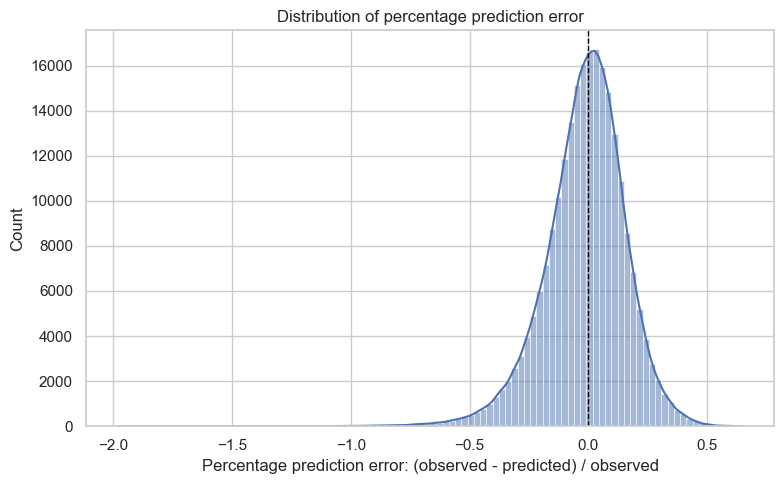

In [77]:
# ----------------------------
# 6.8.1 Error distribution and bias
# ----------------------------

# Use cross-validated predictions from Section 6.5
# y_true_log_arr and y_pred_log_arr should already exist.
# If not, this cell will create them from the Section 6.5 variables.

if "y_true_log_arr" not in globals():
    y_true_log_arr = np.asarray(y_cv_log)

if "y_pred_log_arr" not in globals():
    y_pred_log_arr = np.asarray(y_pred_log_arr)

# Convert log values back to original kWh scale
y_true_kwh_arr = np.exp(y_true_log_arr)
y_pred_kwh_arr = np.exp(y_pred_log_arr)

# Standard percentage prediction error:
# PE = (observed - predicted) / observed
# PE > 0  -> underprediction
# PE < 0  -> overprediction
pct_error = (
    y_true_kwh_arr - y_pred_kwh_arr
) / y_true_kwh_arr

# ----------------------------
# Summary statistics
# ----------------------------

error_summary = pd.DataFrame({
    "Metric": [
        "Mean percentage error",
        "Median percentage error",
        "Share of underpredictions",
        "Share of overpredictions",
        "Share of exact predictions (numerically close to zero)"
    ],
    "Value": [
        pct_error.mean(),
        np.median(pct_error),
        np.mean(pct_error > 0),
        np.mean(pct_error < 0),
        np.mean(np.isclose(pct_error, 0.0))
    ]
})

display(error_summary)

# ----------------------------
# Error quantiles
# ----------------------------

error_quantiles = pd.DataFrame({
    "Quantile": [
        "0%",
        "5%",
        "10%",
        "25%",
        "50%",
        "75%",
        "90%",
        "95%",
        "100%"
    ],
    "Percentage_Error": np.percentile(
        pct_error,
        [0, 5, 10, 25, 50, 75, 90, 95, 100]
    )
})

display(error_quantiles)

# ----------------------------
# Histogram of percentage prediction error
# ----------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    pct_error,
    bins=100,
    kde=True
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Distribution of percentage prediction error")
plt.xlabel("Percentage prediction error: (observed - predicted) / observed")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation of prediction error distribution and bias

**Bias and central tendency**

The mean percentage prediction error is approximately **−1.4%**, while the median percentage error is approximately **−0.1%**.

The negative mean indicates a slight overall tendency toward overprediction, although the magnitude of this bias is small. The median being very close to zero indicates that the typical prediction is well centered around the observed value.

The shares of underpredictions and overpredictions are approximately balanced:

- underpredictions: **49.6%**
- overpredictions: **50.4%**

This suggests that the model does not systematically predict too high or too low across the sample as a whole.

**Typical prediction accuracy**

The interquartile range of the percentage prediction error extends from approximately:

- **−10.8%** (25th percentile)
- to **+9.5%** (75th percentile)

This indicates that 50% of postcode areas are predicted within roughly ±10% of the observed electricity consumption.

The broader central 80% range extends from approximately:

- **−22.4%** (10th percentile)
- to **+18.2%** (90th percentile)

This suggests that most postcode areas are predicted with moderate error magnitudes, while larger deviations are concentrated in a relatively small subset of observations.

**Tail behaviour and asymmetry**

The distribution of prediction errors is asymmetric.

The most extreme overprediction error is approximately **−198%**, while the strongest underprediction error is approximately **+65%**.

This asymmetry indicates that the largest relative errors occur primarily when the model overpredicts electricity consumption in postcode areas with unusually low observed demand.

Because the percentage error is defined relative to the observed value, overprediction errors can become very large when observed electricity consumption is small. For example, a postcode area with observed consumption of 500 kWh and predicted consumption of 1,500 kWh produces a much larger relative error than a comparable deviation at higher consumption levels.

The histogram confirms this pattern, showing:

- a strong concentration of prediction errors around zero
- a longer left tail associated with extreme overprediction cases
- a shorter right tail associated with underprediction cases

**Overall assessment**

Overall, the preferred log-log model demonstrates relatively stable predictive performance for the majority of postcode areas.

Prediction errors are centered close to zero, the frequency of underprediction and overprediction is nearly balanced, and most postcode areas exhibit moderate error magnitudes.

The main remaining limitation is the presence of a relatively small number of postcode areas with unusually low electricity consumption, for which the model substantially overpredicts demand. These extreme cases motivate the more detailed investigation of prediction-error patterns in the following subsection.

#### 6.8.2 Identification of extreme prediction cases

The previous subsection showed that while most predictions are reasonably accurate, a small number of observations may exhibit large errors. To better understand these cases, this subsection identifies the postcode areas with the largest prediction errors.

The analysis focuses on:

- observations with the largest absolute percentage prediction errors  
- observations with the strongest underprediction  
- observations with the strongest overprediction  

The percentage prediction error is defined relative to the observed value:

$$
PE_i = \frac{y_i - \hat{y}_i}{y_i}
$$

and its absolute value is:

$$
|PE_i| = \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

where $y_i$ is the observed average electricity consumption per dwelling and $\hat{y}_i$ is the predicted value.

Positive values indicate underprediction, while negative values indicate overprediction. Observations are ranked according to these measures to identify postcode areas where the model performs least accurately.

Because the model is evaluated using cross-validation, the extreme cases identified below are based on out-of-sample predictions rather than fitted in-sample predictions.

In [78]:
# ----------------------------
# 6.8.2 Identify extreme prediction cases
# ----------------------------

indices_all = reg_data.index.values

error_df = pd.DataFrame({
    "idx": indices_all,
    "y_true_log": y_true_log_arr,
    "y_pred_log": y_pred_log_arr
})

error_df = error_df.merge(
    reg_data.reset_index().rename(columns={"index": "idx"}),
    on="idx",
    how="left"
)

error_df["pc6"] = error_df["postcode"]

error_df["y_true"] = np.exp(error_df["y_true_log"])
error_df["y_pred"] = np.exp(error_df["y_pred_log"])

# Standard percentage prediction error:
# PE > 0 -> underprediction
# PE < 0 -> overprediction
error_df["pct_error"] = (
    error_df["y_true"] - error_df["y_pred"]
) / error_df["y_true"]

error_df["abs_pct_error"] = np.abs(error_df["pct_error"])

worst_cases = (
    error_df
    .sort_values("abs_pct_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

under_cases = (
    error_df
    .sort_values("pct_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

over_cases = (
    error_df
    .sort_values("pct_error", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

cols_display = [
    "pc6",
    "y_true_log",
    "y_pred_log",
    "y_true",
    "y_pred",
    "pct_error",
    "abs_pct_error"
]

print("Top 10 worst prediction cases:")
display(worst_cases[cols_display])

print("Top 10 underprediction cases:")
display(under_cases[cols_display])

print("Top 10 overprediction cases:")
display(over_cases[cols_display])

Top 10 worst prediction cases:


,pc6,y_true_log,y_pred_log,y_true,y_pred,pct_error,abs_pct_error
0,1022BB,6.272877,7.365329,530.0,1580.235175,-1.981576,1.981576
1,9001AD,6.461468,7.525581,640.0,1854.890523,-1.898266,1.898266
2,3563HE,6.768493,7.795325,870.0,2429.219966,-1.792207,1.792207
3,7411BK,7.056175,8.052103,1160.0,3140.390807,-1.707233,1.707233
4,3317DE,7.595890,8.591741,1990.0,5386.986296,-1.707028,1.707028
5,1061BW,6.363028,7.308685,580.0,1493.211889,-1.574503,1.574503
6,8442DM,6.733402,7.652558,840.0,2106.026943,-1.507175,1.507175
7,1061CX,6.445720,7.359349,630.0,1570.812997,-1.493354,1.493354
8,9722XB,6.309918,7.209423,550.0,1352.112346,-1.458386,1.458386
9,2162BC,6.856462,7.735081,950.0,2287.194733,-1.407573,1.407573


Top 10 underprediction cases:


,pc6,y_true_log,y_pred_log,y_true,y_pred,pct_error,abs_pct_error
0,8332DL,8.328451,7.279796,4140.0,1450.692339,0.649591,0.649591
1,5025JW,8.330864,7.325943,4150.0,1519.206240,0.633926,0.633926
2,6901NJ,8.171882,7.169773,3540.0,1299.550179,0.632895,0.632895
3,9712PG,8.221479,7.228506,3720.0,1378.161712,0.629526,0.629526
4,6219AH,8.653471,7.697979,5730.0,2203.889255,0.615377,0.615377
5,1771AK,8.389360,7.461569,4400.0,1739.876311,0.604574,0.604574
6,5481MK,8.089482,7.168585,3260.0,1298.007188,0.601838,0.601838
7,5102GX,8.354674,7.435652,4250.0,1695.363467,0.601091,0.601091
8,6901NH,8.055158,7.140255,3150.0,1261.749497,0.599445,0.599445
9,1053VV,8.594154,7.687594,5400.0,2181.120838,0.596089,0.596089


Top 10 overprediction cases:


,pc6,y_true_log,y_pred_log,y_true,y_pred,pct_error,abs_pct_error
0,1022BB,6.272877,7.365329,530.0,1580.235175,-1.981576,1.981576
1,9001AD,6.461468,7.525581,640.0,1854.890523,-1.898266,1.898266
2,3563HE,6.768493,7.795325,870.0,2429.219966,-1.792207,1.792207
3,7411BK,7.056175,8.052103,1160.0,3140.390807,-1.707233,1.707233
4,3317DE,7.595890,8.591741,1990.0,5386.986296,-1.707028,1.707028
5,1061BW,6.363028,7.308685,580.0,1493.211889,-1.574503,1.574503
6,8442DM,6.733402,7.652558,840.0,2106.026943,-1.507175,1.507175
7,1061CX,6.445720,7.359349,630.0,1570.812997,-1.493354,1.493354
8,9722XB,6.309918,7.209423,550.0,1352.112346,-1.458386,1.458386
9,2162BC,6.856462,7.735081,950.0,2287.194733,-1.407573,1.407573


### Interpretation of extreme prediction cases

The extreme prediction cases provide additional insight into the behaviour of the preferred log-log regression model at the tails of the electricity-consumption distribution.

**General pattern**

The largest prediction errors are concentrated in a relatively small subset of postcode areas with unusually low or unusually high observed electricity consumption.

The strongest overprediction cases dominate the ranking of largest absolute errors. These cases correspond primarily to postcode areas with very low observed electricity consumption per dwelling.

In contrast, the strongest underprediction cases are associated with postcode areas exhibiting relatively high observed electricity consumption.

This indicates that the model performs best in the central range of the consumption distribution and becomes less accurate at the extremes.

**Overprediction cases**

The strongest overprediction cases typically involve observed electricity consumption levels between approximately:

- **530 and 2,000 kWh per dwelling**

while predicted values range approximately between:

- **1,350 and 5,400 kWh per dwelling**

In several cases, the predicted electricity consumption is roughly two to three times larger than the observed value.

Because the percentage error is defined relative to observed consumption, these postcode areas produce very large negative percentage errors, ranging from approximately:

- **−141% to −198%**

These results suggest that a limited number of postcode areas exhibit unusually low electricity consumption relative to their structural and socioeconomic characteristics.

**Underprediction cases**

The strongest underprediction cases correspond to postcode areas with observed electricity consumption levels between approximately:

- **3,150 and 5,730 kWh per dwelling**

while predicted values remain substantially lower, typically between:

- **1,250 and 2,200 kWh per dwelling**

The corresponding percentage prediction errors range from approximately:

- **+60% to +65%**

These postcode areas therefore consume substantially more electricity than predicted by the model.

This suggests that some high-consumption postcode areas contain behavioural or structural characteristics that are not fully captured by the explanatory variables included in the regression specification.

**Asymmetry of extreme errors**

The extreme prediction errors are clearly asymmetric.

The strongest overprediction cases are substantially larger in relative magnitude than the strongest underprediction cases. This asymmetry is also visible in the error-distribution histogram from Section 6.8.1, which exhibits a longer left tail.

This pattern indicates that the preferred model struggles more with a limited number of unusually low-consumption postcode areas than with high-consumption postcode areas.

**Overall assessment**

Although extreme prediction errors exist, they are concentrated in a relatively small subset of postcode areas.

For the majority of observations, prediction errors remain substantially smaller and more centered around zero. The extreme cases mainly indicate that the model becomes less accurate at the tails of the electricity-consumption distribution, particularly for postcode areas with unusually low observed consumption.

These findings motivate the broader investigation of systematic error patterns across postcode characteristics in the following subsection.

### 6.8.3 Error patterns across postcode characteristics

The previous subsections showed how prediction errors are distributed overall and which postcode areas exhibit the largest deviations. To better understand the origin of these errors, this subsection examines how prediction accuracy varies across key postcode characteristics.

The objective is to identify whether prediction errors are systematically associated with:

- the level of average electricity consumption per dwelling  
- postcode size, measured by the number of dwellings  
- structural housing characteristics  
- infrastructure variables  
- socioeconomic indicators  

If such patterns exist, they can indicate where the regression model performs well and where it struggles to capture underlying variation.

The analysis proceeds in two steps.

First, a systematic binned analysis groups postcode areas into quantiles based on selected numeric variables. For each bin, the average and median prediction error are computed. This provides a clear summary of how model performance varies across different segments of the data.

Second, focused plots are created for the most relevant error patterns. These plots make it easier to visually compare whether prediction errors are centered around zero or whether they vary systematically across important postcode characteristics.

Together, these approaches allow a systematic evaluation of where prediction errors are concentrated and whether they are associated with specific types of postcode areas.

In [79]:
# ----------------------------
# 6.8.3 Error patterns across postcode characteristics
# Systematic binned analysis across numeric variables
# ----------------------------

# ----------------------------
# 0. Rebuild error_df if needed
# ----------------------------

indices_all = reg_data.index.values

error_df = pd.DataFrame({
    "idx": indices_all,
    "y_true_log": np.asarray(y_true_log_arr),
    "y_pred_log": np.asarray(y_pred_log_arr)
})

error_df = error_df.merge(
    reg_data.reset_index().rename(columns={"index": "idx"}),
    on="idx",
    how="left"
)

error_df["pc6"] = error_df["postcode"]

error_df["y_true"] = np.exp(error_df["y_true_log"])
error_df["y_pred"] = np.exp(error_df["y_pred_log"])

error_df["pct_error"] = (
    error_df["y_true"] - error_df["y_pred"]
) / error_df["y_true"]

error_df["abs_pct_error"] = np.abs(error_df["pct_error"])

# ----------------------------
# 1. Variables excluded from explanatory diagnostics
# ----------------------------

exclude_cols = [
    "idx",
    "postcode",
    "pc6",
    "y_true_log",
    "y_pred_log",
    "y_true",
    "y_pred",
    "pct_error",
    "abs_pct_error",
    "kwh_avg_per_dwelling_pc6"
]

energy_outcome_cols = [
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6",
    "kwh_total_pc6",
    "gas_total_pc6",
    "pv_total_pc6"
]

exclude_cols = exclude_cols + [
    c for c in energy_outcome_cols
    if c in error_df.columns
]

# ----------------------------
# 2. Select numeric explanatory variables
# ----------------------------

analysis_vars = [
    c for c in error_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(error_df[c])
]

# ----------------------------
# 3. Helper function
# ----------------------------

def binned_error(df, var, n_bins=10):
    temp = df[[var, "pct_error"]].dropna().copy()

    # Skip variables with too few unique values
    if temp[var].nunique() < 2:
        raise ValueError("Variable has fewer than 2 unique values.")

    temp["bin"] = pd.qcut(
        temp[var],
        q=n_bins,
        duplicates="drop"
    )

    out = (
        temp
        .groupby("bin", observed=False)["pct_error"]
        .agg(["mean", "median", "count"])
        .reset_index()
    )

    return out

# ----------------------------
# 4. Compute binned error summaries
# ----------------------------

binned_results = {}

for var in analysis_vars:
    try:
        result = binned_error(error_df, var, n_bins=10)
        result.rename(columns={"bin": var}, inplace=True)
        binned_results[var] = result
    except Exception as e:
        print(f"Skipping {var}: {e}")

# ----------------------------
# 5. Display results
# ----------------------------

for var, df_out in binned_results.items():
    print(f"\nError by {var}:")
    display(df_out)


Error by n_dwellings:


,n_dwellings,mean,median,count
0,"(0.999, 9.0]",-0.024367,-0.004712,27226
1,"(9.0, 12.0]",-0.020727,-0.006323,30297
2,"(12.0, 14.0]",-0.015309,-0.001365,22283
3,"(14.0, 16.0]",-0.013891,-0.001615,26546
4,"(16.0, 18.0]",-0.011089,-0.000214,23738
5,"(18.0, 20.0]",-0.011159,-0.001477,21659
6,"(20.0, 22.0]",-0.005214,0.004052,17259
7,"(22.0, 24.0]",-0.011456,-0.003348,19333
8,"(24.0, 31.0]",-0.006630,0.003082,23846
9,"(31.0, 612.0]",-0.011085,-0.001197,22695



Error by population_total:


,population_total,mean,median,count
0,"(4.999, 20.0]",-0.040983,-0.023389,39247
1,"(20.0, 25.0]",-0.026847,-0.014393,24983
2,"(25.0, 30.0]",-0.017505,-0.007230,26980
3,"(30.0, 35.0]",-0.011622,-0.003311,26438
4,"(35.0, 40.0]",-0.005635,0.001366,23962
5,"(40.0, 50.0]",-0.001111,0.006458,36730
6,"(50.0, 55.0]",0.002219,0.009712,13008
7,"(55.0, 70.0]",0.002678,0.011366,22310
8,"(70.0, 890.0]",0.000339,0.007608,20106



Error by private_households_total:


...

,avg_household_size_filled,mean,median,count
0,"(-0.001, 1.4]",-0.048373,-0.040772,26068
1,"(1.4, 1.7]",-0.021756,-0.013293,26344
2,"(1.7, 1.9]",-0.009616,0.001981,23686
3,"(1.9, 2.1]",-0.001827,0.009317,27429
4,"(2.1, 2.2]",0.000559,0.011740,14512
5,"(2.2, 2.4]",0.000421,0.011907,33143
6,"(2.4, 2.5]",-0.000984,0.010887,14454
7,"(2.5, 2.7]",-0.003055,0.008477,24273
8,"(2.7, 3.0]",-0.010970,0.001269,24925
9,"(3.0, 6.7]",-0.038686,-0.027453,20048



Error by avg_household_size_missing:


,avg_household_size_missing,mean,median,count
0,"(-0.001, 1.0]",-0.01374,-0.001355,234882



Error by share_population_on_benefits_filled:


,share_population_on_benefits_filled,mean,median,count
0,"(-0.001, 0.1]",-0.013339,-0.000422,189780
1,"(0.1, 0.2]",-0.011228,-0.000036,26282
2,"(0.2, 1.0]",-0.021291,-0.013306,18820


### Interpretation of the most relevant error patterns

The broader diagnostic scan across all explanatory variables indicates that the strongest and clearest error patterns are associated with variables related to the **scale of postcode electricity demand**, rather than with most compositional housing variables.

**Electricity demand level**
- The most pronounced pattern is observed across bins of average electricity consumption per dwelling.  
- In the lowest consumption bins, prediction errors are generally negative, indicating **overprediction**.  
- As consumption increases, the error gradually shifts toward zero and becomes positive.  
- In the highest consumption bins, the model exhibits **underprediction**, although the magnitude is moderate rather than extreme.  
- This indicates that the model performs best in the middle of the distribution and less well at the lower and upper extremes.

**Postcode size**
- A similar pattern appears across bins of `n_dwellings`, although it is weaker.  
- Mean errors remain small and positive across bins, while median errors stay close to zero.  
- There is no strong monotonic increase, but larger postcode areas tend to show slightly more positive errors.  
- This suggests that part of the remaining model error is related to postcode scale, even after normalization, but the effect is limited.

**Overall interpretation**
- Taken together, these findings indicate that the remaining prediction error is not entirely random.  
- The model tends to **overpredict low-demand / smaller postcode areas** and **underpredict high-demand / larger postcode areas**, though the magnitude is moderate.  
- This suggests a scale-dependent limitation of the preferred regression model, with deviations more visible at the extremes than in the center of the data distribution.

### Interpretation of error variation across postcode characteristics

**Error variation across electricity consumption levels**
- Prediction error varies systematically across consumption bins.  
- For low-consumption PC6s, mean and median errors are negative, indicating overprediction.  
- As consumption increases, errors gradually move toward zero and then become positive.  
- For high-consumption PC6s, errors become positive, indicating underprediction.  
- The magnitude of this pattern is moderate compared to earlier model versions.  
- This pattern suggests that model accuracy depends on the scale of electricity demand, with different behaviour at low and high ends of the distribution.  

**Error variation across floor area**
- Across all floor area bins, the median error remains close to zero, typically within a narrow range.  
- Mean errors are slightly positive, indicating a mild tendency toward underprediction.  
- No strong monotonic pattern is observed across floor area bins.  
- This suggests that, conditional on other variables, floor area does not strongly drive systematic prediction error.  

**Error variation across gas connection share**
- For PC6s with lower gas share, mean errors are somewhat higher, indicating more frequent underprediction.  
- For mid-range gas share, mean error increases slightly, while the median becomes positive.  
- For high gas share, both mean and median errors move closer to zero.  
- Differences across bins are present but less pronounced than those observed for electricity consumption levels.  

**Overall assessment**
- The most pronounced variation in prediction error is observed across electricity consumption levels, not across structural characteristics such as floor area or gas share.  
- The model tends to:
  - overpredict for low-consumption PC6s  
  - underpredict for high-consumption PC6s  
- This indicates a form of scale-dependent error, where extreme values are not captured as accurately as mid-range observations.  
- For most bins outside the extremes, errors remain relatively close to zero, indicating stable performance in the central range of the data.  

### 6.8.4 Prediction error across electricity consumption levels

The previous subsections examined the overall distribution of prediction errors and identified the most extreme prediction cases. This subsection investigates whether prediction errors vary systematically across different levels of observed electricity consumption.

The objective is to determine whether the preferred log-log model performs differently for low-consumption and high-consumption postcode areas.

To evaluate this, postcode areas are grouped into deciles based on observed average electricity consumption per dwelling. For each bin, the mean and median relative prediction error are computed.

This allows the relationship between prediction accuracy and electricity-consumption level to be examined systematically.

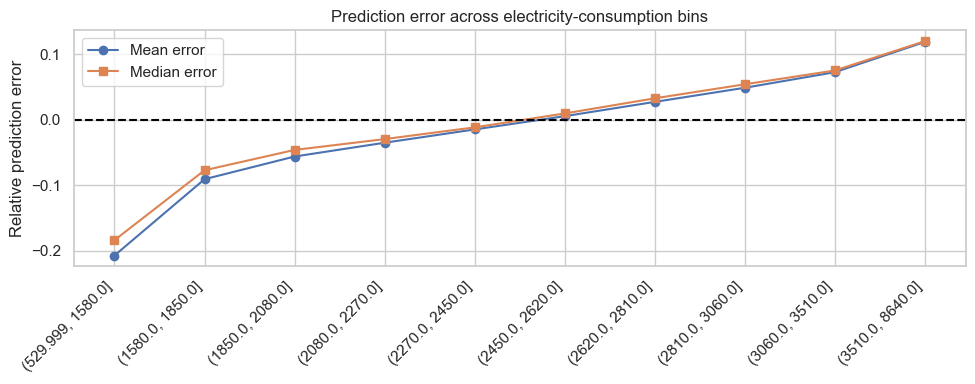

In [80]:
# ----------------------------
# 6.8.3 Prediction error across electricity consumption levels
# ----------------------------

# Compute binned error table
bins_consumption = binned_error(
    error_df,
    "y_true",
    n_bins=10
)

# Rename bin column
bins_consumption.rename(
    columns={
        "bin": "Average electricity consumption (kWh per dwelling)"
    },
    inplace=True
)

# ----------------------------
# Plot:
# Prediction error across consumption bins
# ----------------------------

plt.figure(figsize=(10, 4))

x1 = np.arange(len(bins_consumption))

plt.plot(
    x1,
    bins_consumption["mean"],
    marker="o",
    label="Mean error"
)

plt.plot(
    x1,
    bins_consumption["median"],
    marker="s",
    label="Median error"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xticks(
    x1,
    bins_consumption[
        "Average electricity consumption (kWh per dwelling)"
    ].astype(str),
    rotation=45,
    ha="right"
)

plt.ylabel("Relative prediction error")

plt.title(
    "Prediction error across electricity-consumption bins"
)

plt.legend()

plt.tight_layout()
plt.show()

### 6.9 Robustness extension: gross electricity consumption proxy

The main electricity models use the CBS electricity-consumption variable as the dependent variable. This variable represents average electricity consumption per dwelling as observed from grid connection data. However, CBS states that this consumption excludes electricity generated within private homes, such as electricity generated by rooftop solar panels.

As a result, the dependent variable should be interpreted as net grid electricity consumption rather than total gross household electricity demand.

To assess whether this affects the modelling results, this section constructs an approximate gross electricity-consumption proxy. The proxy adds an assumed self-consumed share of local PV production back to the observed CBS electricity-consumption variable.

The gross electricity proxy is defined as:

$$
kwh\_gross\_proxy_{pc6}
=
kwh\_avg\_per\_dwelling_{pc6}
+
\alpha \cdot pv\_avg\_per\_dwelling_{pc6}
$$

where:

- $kwh\_avg\_per\_dwelling_{pc6}$ is the observed CBS average electricity consumption per dwelling  
- $pv\_avg\_per\_dwelling_{pc6}$ is average PV production per dwelling  
- $\alpha$ is the assumed household self-consumption share of PV production  

In this robustness exercise, $\alpha$ is set equal to 0.30. This assumption is based on the CE Delft and TNO report on the Dutch net-metering scheme, which states that households typically use around 30% of the electricity produced by their solar panels directly themselves.

This reconstructed variable is not interpreted as measured gross electricity demand. It is a proxy based on an explicit assumption. The purpose is to test whether the main regression results are sensitive to the fact that the original CBS electricity variable reflects net grid demand rather than gross household electricity demand.

In [81]:
# ----------------------------
# 6.9.1 Gross electricity consumption proxy models
# 30% self-consumption assumption
# ----------------------------

# ----------------------------
# 1. Construct gross electricity proxy
# ----------------------------

self_consumption_rate = 0.30

pc6_analysis["kwh_gross_proxy_pc6"] = (
    pc6_analysis["kwh_avg_per_dwelling_pc6"]
    + self_consumption_rate * pc6_analysis["pv_avg_per_dwelling_pc6"]
)

print("Gross electricity proxy created.")
print("Self-consumption assumption:", self_consumption_rate)

display(
    pc6_analysis[
        [
            "kwh_avg_per_dwelling_pc6",
            "pv_avg_per_dwelling_pc6",
            "kwh_gross_proxy_pc6"
        ]
    ].describe()
)

# ----------------------------
# 2. Dependent variables
# ----------------------------

y_gross_linear = pc6_analysis.loc[
    X.index,
    "kwh_gross_proxy_pc6"
].copy()

y_gross_log = np.log(y_gross_linear)

# ----------------------------
# 3. Linear gross proxy model
# ----------------------------

X_gross_linear = X.copy()

model_linear_gross = sm.OLS(
    y_gross_linear,
    X_gross_linear
).fit()

print("Linear model using gross electricity proxy:")
print(model_linear_gross.summary())

# ----------------------------
# 4. Log-level gross proxy model
# ----------------------------

X_gross_log = X.copy()

model_log_gross = sm.OLS(
    y_gross_log,
    X_gross_log
).fit()

print("Log-level model using gross electricity proxy:")
print(model_log_gross.summary())

# ----------------------------
# 5. Log-log gross proxy model
# ----------------------------

X_gross_loglog = X.copy()

X_gross_loglog["log_mean_floor_area"] = np.log(
    X_gross_loglog["mean_floor_area"]
)

X_gross_loglog = X_gross_loglog.drop(
    columns=["mean_floor_area"]
)

model_loglog_gross = sm.OLS(
    y_gross_log,
    X_gross_loglog
).fit()

print("Log-log model using gross electricity proxy:")
print(model_loglog_gross.summary())

Gross electricity proxy created.
Self-consumption assumption: 0.3


,kwh_avg_per_dwelling_pc6,pv_avg_per_dwelling_pc6,kwh_gross_proxy_pc6
count,234882.000000,234882.000000,234882.000000
mean,2521.628520,268.952460,2602.314258
std,802.443824,541.717694,851.198708
min,530.000000,0.000000,530.000000
25%,1970.000000,0.000000,2015.525000
50%,2450.000000,0.000000,2520.000000
75%,2930.000000,306.000000,3030.000000
max,8640.000000,17977.000000,9596.700000


Linear model using gross electricity proxy:
                             OLS Regression Results                            
Dep. Variable:     kwh_gross_proxy_pc6   R-squared:                       0.720
Model:                             OLS   Adj. R-squared:                  0.720
Method:                  Least Squares   F-statistic:                 2.161e+04
Date:                 Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                         01:56:46   Log-Likelihood:            -1.7683e+06
No. Observations:               234882   AIC:                         3.537e+06
Df Residuals:                   234853   BIC:                         3.537e+06
Df Model:                           28                                         
Covariance Type:             nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

#### 6.9.2 Comparison and residual diagnostics for the gross electricity proxy

The gross electricity proxy models are compared with the original electricity models using the same model-fit criteria applied earlier in Chapter 6.

The comparison includes:

- adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ is used to compare explanatory power while accounting for model complexity. AIC and BIC are reported as model-selection criteria, but they should be interpreted mainly within models estimated on the same dependent-variable scale.

Residual diagnostics are also examined to assess whether the gross proxy changes the residual structure of the electricity models. The diagnostics include:

- residual histograms for the full distribution and central 98% of residuals  
- residuals versus fitted-value plots  
- hexbin residual-density plots  

The hexbin plots are included because the dataset contains a very large number of PC6 observations. They make it easier to identify dense residual patterns and heteroskedasticity compared with standard scatter plots.

The aim of this section is not to replace the original CBS net electricity-consumption model, but to evaluate whether the main results are robust to an approximate correction for behind-the-meter PV self-consumption.

Original vs gross electricity proxy model comparison:


,Model,Observations,Adj_R2,AIC,BIC
0,Linear original,234882,0.7177,3511173.4,3511474.0
1,Linear gross proxy,234882,0.7203,3536639.1,3536939.8
2,Log-level original,234882,0.7120,-171657.3,-171356.6
3,Log-level gross proxy,234882,0.7215,-167173.4,-166872.8
4,Log-log original,234882,0.7202,-178370.8,-178070.2
5,Log-log gross proxy,234882,0.7304,-174776.4,-174475.8


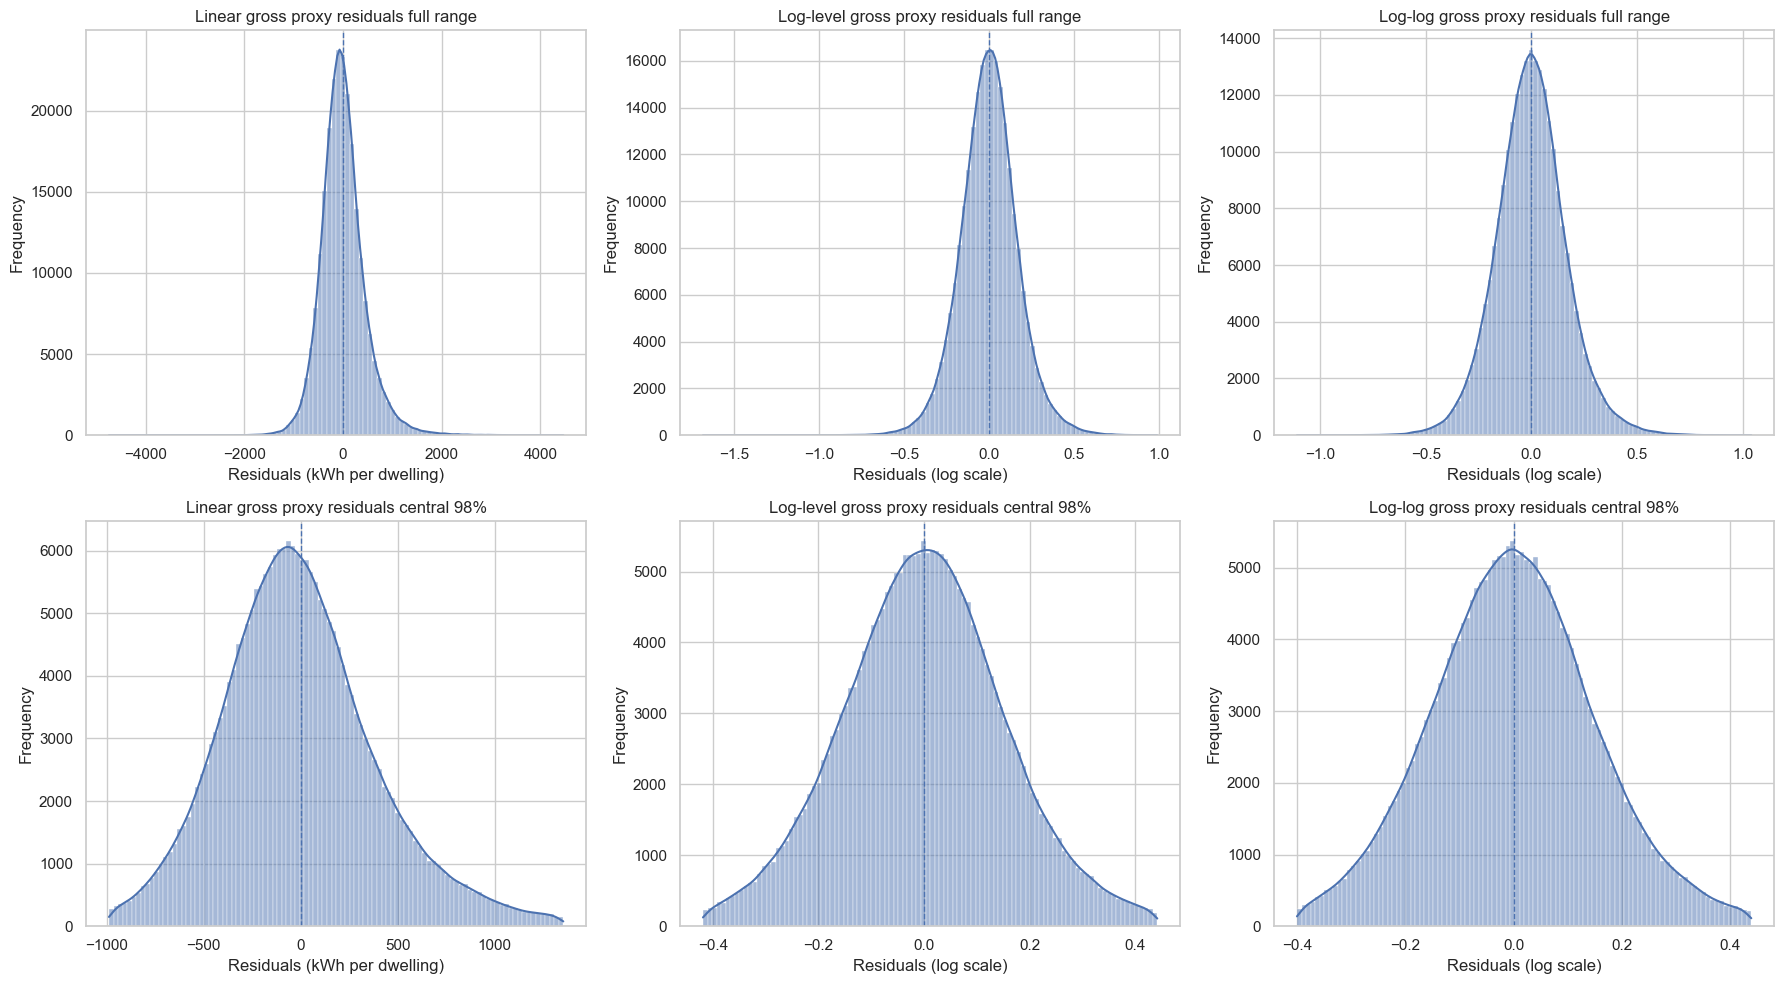

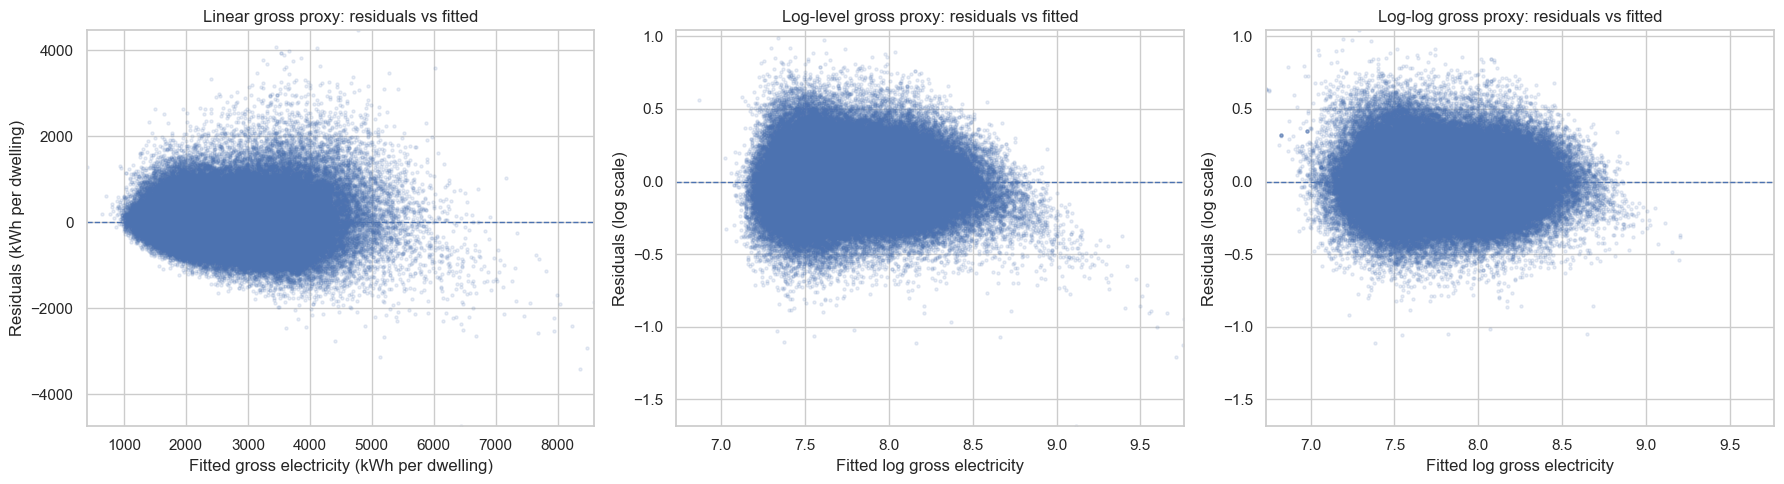

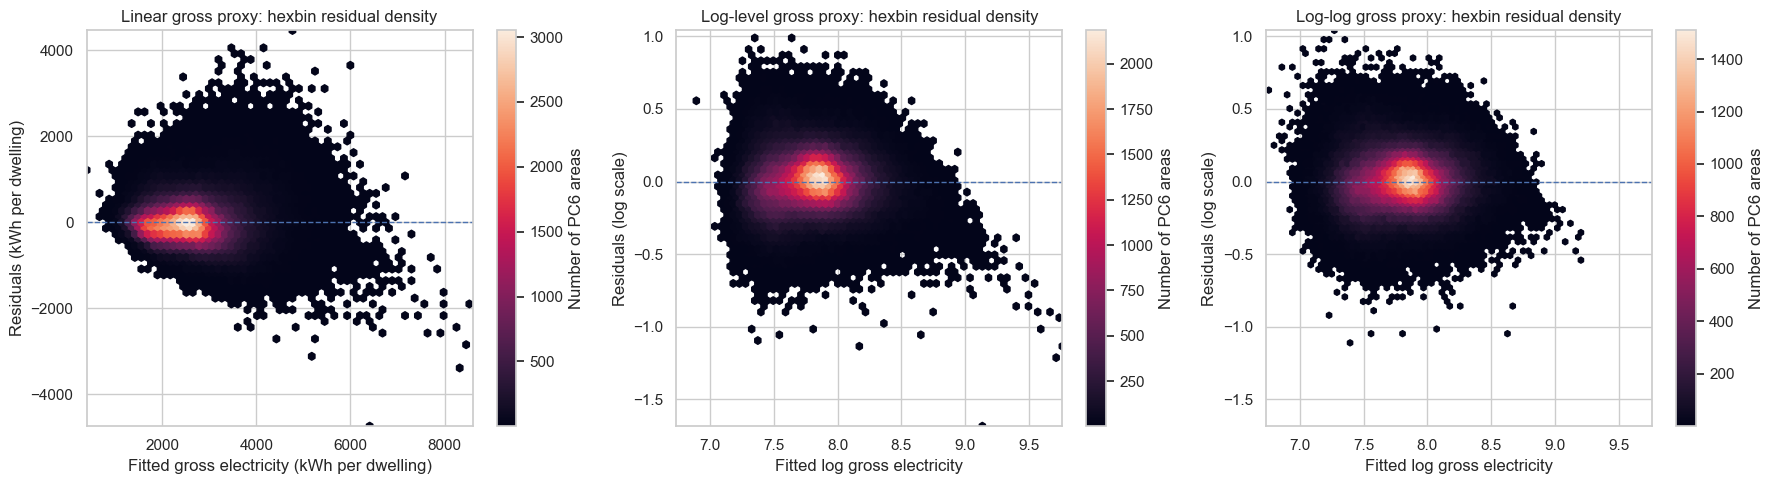

In [82]:
# ----------------------------
# 6.9.2 Gross proxy model comparison and residual diagnostics
# ----------------------------

# ----------------------------
# 1. Model comparison table
# ----------------------------

gross_comparison = pd.DataFrame({
    "Model": [
        "Linear original",
        "Linear gross proxy",
        "Log-level original",
        "Log-level gross proxy",
        "Log-log original",
        "Log-log gross proxy"
    ],
    "Observations": [
        int(model_linear.nobs),
        int(model_linear_gross.nobs),
        int(model_log.nobs),
        int(model_log_gross.nobs),
        int(model_loglog.nobs),
        int(model_loglog_gross.nobs)
    ],
    "Adj_R2": [
        model_linear.rsquared_adj,
        model_linear_gross.rsquared_adj,
        model_log.rsquared_adj,
        model_log_gross.rsquared_adj,
        model_loglog.rsquared_adj,
        model_loglog_gross.rsquared_adj
    ],
    "AIC": [
        model_linear.aic,
        model_linear_gross.aic,
        model_log.aic,
        model_log_gross.aic,
        model_loglog.aic,
        model_loglog_gross.aic
    ],
    "BIC": [
        model_linear.bic,
        model_linear_gross.bic,
        model_log.bic,
        model_log_gross.bic,
        model_loglog.bic,
        model_loglog_gross.bic
    ]
})

gross_comparison = gross_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Original vs gross electricity proxy model comparison:")
display(gross_comparison)

# ----------------------------
# 2. Store gross proxy models
# ----------------------------

gross_models = [
    {
        "name": "Linear gross proxy",
        "model": model_linear_gross,
        "scale": "levels",
        "x_label": "Fitted gross electricity (kWh per dwelling)",
        "y_label": "Residuals (kWh per dwelling)"
    },
    {
        "name": "Log-level gross proxy",
        "model": model_log_gross,
        "scale": "log",
        "x_label": "Fitted log gross electricity",
        "y_label": "Residuals (log scale)"
    },
    {
        "name": "Log-log gross proxy",
        "model": model_loglog_gross,
        "scale": "log",
        "x_label": "Fitted log gross electricity",
        "y_label": "Residuals (log scale)"
    }
]

# ----------------------------
# 3. Residual histograms
# ----------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, item in enumerate(gross_models):

    residuals = item["model"].resid

    sns.histplot(
        residuals,
        bins=100,
        kde=True,
        ax=axes[0, i]
    )

    axes[0, i].axvline(0, linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{item['name']} residuals full range")
    axes[0, i].set_xlabel(item["y_label"])
    axes[0, i].set_ylabel("Frequency")

    r_min = residuals.quantile(0.01)
    r_max = residuals.quantile(0.99)

    sns.histplot(
        residuals[
            (residuals >= r_min)
            & (residuals <= r_max)
        ],
        bins=100,
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].axvline(0, linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{item['name']} residuals central 98%")
    axes[1, i].set_xlabel(item["y_label"])
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# ----------------------------
# 4. Axis limits for fair visual comparison
# ----------------------------

linear_xlim_gross = (
    model_linear_gross.fittedvalues.min(),
    model_linear_gross.fittedvalues.max()
)

linear_ylim_gross = (
    model_linear_gross.resid.min(),
    model_linear_gross.resid.max()
)

log_x_all_gross = pd.concat([
    model_log_gross.fittedvalues,
    model_loglog_gross.fittedvalues
])

log_y_all_gross = pd.concat([
    model_log_gross.resid,
    model_loglog_gross.resid
])

log_xlim_gross = (
    log_x_all_gross.min(),
    log_x_all_gross.max()
)

log_ylim_gross = (
    log_y_all_gross.min(),
    log_y_all_gross.max()
)

# ----------------------------
# 5. Residuals vs fitted values
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, gross_models):

    model = item["model"]

    ax.scatter(
        model.fittedvalues,
        model.resid,
        s=5,
        alpha=0.12
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: residuals vs fitted")
    ax.set_xlabel(item["x_label"])
    ax.set_ylabel(item["y_label"])

    if item["scale"] == "levels":
        ax.set_xlim(linear_xlim_gross)
        ax.set_ylim(linear_ylim_gross)
    else:
        ax.set_xlim(log_xlim_gross)
        ax.set_ylim(log_ylim_gross)

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Hexbin residual-density plots
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, item in zip(axes, gross_models):

    model = item["model"]

    hb = ax.hexbin(
        model.fittedvalues,
        model.resid,
        gridsize=60,
        mincnt=1
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{item['name']}: hexbin residual density")
    ax.set_xlabel(item["x_label"])
    ax.set_ylabel(item["y_label"])

    if item["scale"] == "levels":
        ax.set_xlim(linear_xlim_gross)
        ax.set_ylim(linear_ylim_gross)
    else:
        ax.set_xlim(log_xlim_gross)
        ax.set_ylim(log_ylim_gross)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Interpretation of the gross electricity proxy results

The gross electricity proxy models provide a robustness check for the fact that the original CBS electricity variable represents net grid electricity consumption rather than total household electricity use. The proxy adds 30\% of average PV production per dwelling to the CBS electricity-consumption variable.

The 30\% self-consumption assumption is based on the CE Delft and TNO report on the Dutch salderingsregeling (net-metering scheme), which states that households typically consume approximately 30\% of their generated PV electricity directly themselves. The same report also uses 30\% as the reference self-consumption case and 60\% as a higher self-consumption scenario. :contentReference[oaicite:0]{index=0}

The table below compares the original electricity-demand models with the corresponding gross electricity proxy specifications.

| Model | Observations | Adjusted $R^2$ | AIC | BIC |
|---|---:|---:|---:|---:|
| Linear original | 234,882 | 0.678 | 2,835,005 | 2,835,324 |
| Linear gross proxy | 234,882 | 0.720 | 3,536,639 | 3,536,940 |
| Log-level original | 234,882 | 0.668 | -154,401 | -154,082 |
| Log-level gross proxy | 234,882 | 0.722 | -167,173 | -166,873 |
| Log-log original | 234,882 | 0.720 | -178,371 | -178,070 |
| Log-log gross proxy | 234,882 | 0.730 | -174,776 | -174,476 |

The results show that the gross proxy models generally achieve higher adjusted $R^2$ values than the original net-consumption models.

For the linear specification, adjusted $R^2$ increases from approximately 0.678 in the original model to 0.720 in the gross proxy model. For the log-level specification, adjusted $R^2$ increases from approximately 0.668 to 0.722. For the log-log specification, the increase is smaller, from approximately 0.720 to 0.730.

The log-log gross proxy model achieves the highest adjusted $R^2$ among the gross proxy specifications. However, the improvement relative to the original log-log model remains limited. This suggests that the preferred log-log specification is already relatively robust to the distinction between net and approximate gross electricity consumption.

The AIC and BIC values should be interpreted carefully. These metrics are directly comparable only for models estimated on the same dependent-variable scale and sample. Within the gross proxy specifications, the log-log model achieves lower AIC and BIC values than the log-level specification, indicating a somewhat better fit within the gross-proxy log-model family.

The residual histograms show that the log-level and log-log gross proxy models produce more symmetric residual distributions than the linear gross proxy specification. The linear model continues to exhibit wider residual dispersion and heavier tails in kWh terms.

The residual-versus-fitted plots and hexbin density plots indicate that residual dispersion remains present across the fitted-value range, particularly for postcode areas with higher predicted electricity demand. However, the gross proxy models do not reveal major new residual structures relative to the original specifications.

Overall, the gross proxy exercise suggests that approximate correction for self-consumed PV electricity modestly improves model fit, particularly for the linear and log-level specifications. The improvement for the preferred log-log specification is comparatively small. Therefore, the main conclusion is not that the gross proxy should replace the CBS net-consumption variable, but rather that the main regression findings remain broadly stable after introducing an approximate correction for behind-the-meter PV self-consumption.

### 6.9 Concluding remarks for Chapter 6

This chapter examined how postcode-level housing composition relates to electricity demand per dwelling by developing and comparing alternative regression specifications.

Three OLS models were estimated: a model in levels, a log-level model with a logarithmic dependent variable, and a log-log specification with logarithmic floor area. The model comparison showed that the two log-based specifications clearly outperform the linear model in terms of residual behaviour and overall model stability. Among them, the **log-log model** provides the strongest overall balance between interpretability and empirical adequacy, with slightly higher explanatory power and more stable residual patterns.

The estimated coefficients indicate that electricity demand per dwelling is systematically associated with structural housing characteristics. In particular, larger dwellings are associated with higher electricity demand, gas-connected housing stocks are associated with lower electricity demand, and higher shares of more efficient energy labels are generally associated with lower consumption relative to the least efficient reference category. At the same time, the multicollinearity assessment showed that several predictors, especially construction year and energy-label composition, are strongly correlated.

The coefficient estimates should therefore be interpreted as **conditional associations within a jointly varying housing structure**, rather than as independent causal effects. They describe how electricity demand is predicted to vary when one characteristic changes while the others are held constant in the model. As a result, the model can be used for **scenario analysis**, where changes in housing composition are translated into predicted changes in electricity demand. However, these predictions should be interpreted as **model-based counterfactuals**, not as causal effects, since real-world changes in housing characteristics are likely to be accompanied by other unobserved adjustments.

Inference robustness was evaluated for the preferred log-log model. The Breusch-Pagan test indicated heteroskedasticity, implying that conventional OLS standard errors may be unreliable. Re-estimation with **HC3 robust standard errors** did not alter the coefficients and did not materially change the substantive conclusions, indicating that the main patterns identified in the preferred model are statistically robust.

The predictive assessment showed that the preferred log-log regression generalizes meaningfully beyond the estimation sample. In cross-validation, it performs substantially better than a naive baseline that predicts only the mean of the dependent variable, confirming that the model captures systematic postcode-level variation rather than merely reproducing the average outcome.

Finally, the nonlinear Random Forest benchmark achieved a lower prediction error than the regression model. However, the gain is **moderate rather than transformative**, indicating that while some nonlinearities and interaction effects exist, the log-log regression already captures most of the systematic variation in electricity demand. This supports retaining the regression framework as the main model, as it combines strong predictive performance with clear interpretability.

Overall, Chapter 6 shows that postcode-level structural and socioeconomic variables contain substantial explanatory and predictive information for electricity demand per dwelling. A log-log regression framework is sufficient to capture the main regularities in the data, while the nonlinear benchmark confirms that additional predictive gains are limited. This makes the preferred regression model both a defensible analytical choice and a suitable basis for subsequent interpretation.

### 7 Feature Importance Analysis

The regression analysis in Chapter 6 identified the preferred specification and evaluated its robustness, predictive performance, and nonlinear benchmark. However, coefficient estimates alone do not provide a complete picture of which predictors are most influential across different modelling frameworks.

This chapter therefore examines **feature importance** using multiple complementary methods. The purpose is not only to rank predictors, but also to assess whether the main substantive variables of interest remain important across linear, regularized, and nonlinear models.

The analysis focuses on four approaches:

1. **Standardized OLS coefficients** from the preferred log-log regression model  
2. **LASSO regression**, which performs feature selection through L1 regularization  
3. **Elastic Net regression**, which combines L1 and L2 regularization and is better suited to correlated predictors  
4. **Random Forest feature importance**, based on impurity reduction  

An additional importance measure, **permutation importance**, may also be used for the Random Forest benchmark to complement impurity-based importance.

These methods capture different notions of importance:

- **Standardized OLS coefficients** reflect the size and direction of marginal associations in the preferred interpretable regression model  
- **LASSO** highlights predictors that remain useful when weak variables are shrunk toward zero  
- **Elastic Net** provides a more stable ranking when predictors are correlated  
- **Random Forest importance** captures nonlinear and interaction-based predictive relevance  

This distinction is important in the present dataset because several predictors are correlated, especially the compositional variables such as dwelling-type shares and energy-label shares. As a result, feature importance should be interpreted cautiously, particularly for individual categories within the same group.

Throughout this chapter, consistency with Chapter 6 is maintained:

- The dependent variable remains the logarithm of `kwh_avg_per_dwelling_pc6`  
- The preferred predictor set remains the one used in the preferred log-log specification  
- The same filtered dataset is used, i.e. only postcode areas with positive average electricity consumption (`kwh_avg_per_dwelling_pc6 > 0`) are included  

The goal is to identify which variables emerge as consistently important across methods, while distinguishing between:

- **non-control variables of substantive interest**: `share_has_gas` and energy-label shares  
- **control variables**: floor area, construction year, dwelling-type shares, and CBS socioeconomic variables  

A final comparison section will summarize whether the main conclusions from Chapter 6 are supported by these alternative feature-importance approaches.

### 7.1 Standardized OLS Coefficients

The first feature-importance measure is based on the preferred log-log regression model from Chapter 6. Because the raw coefficients are expressed in different units across predictors, they are not directly comparable in magnitude.

To obtain a common scale, the predictors and dependent variable are standardized before estimating the same log-log specification. The resulting coefficients can then be interpreted as **standardized OLS coefficients** (beta coefficients).

A standardized coefficient measures the expected change in the dependent variable, in standard deviations, associated with a one-standard-deviation increase in the predictor, holding all other variables constant.

This approach provides a useful baseline because:

- it remains directly linked to the preferred regression framework  
- it preserves coefficient sign and interpretability  
- it allows comparison of relative variable importance within a linear specification  

The standardized OLS coefficients should still be interpreted with caution in the presence of multicollinearity, but they provide a natural benchmark before moving to regularized and nonlinear methods.

In [83]:
# ----------------------------
# 7.1 Standardized OLS coefficients
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.preprocessing import StandardScaler

# Use EXACT same data as preferred model
X_std_source = X_loglog.copy()
y_std_source = y_loglog.copy()

# ----------------------------
# Standardize X
# ----------------------------
scaler_X = StandardScaler()
X_std = pd.DataFrame(
    scaler_X.fit_transform(X_std_source),
    columns=X_std_source.columns,
    index=X_std_source.index
)

# ----------------------------
# Standardize y
# ----------------------------
scaler_y = StandardScaler()
y_std = pd.Series(
    scaler_y.fit_transform(y_std_source.to_frame()).ravel(),
    index=y_std_source.index,
    name="log_kwh_avg_per_dwelling_pc6_std"
)

# ----------------------------
# Fit standardized OLS
# ----------------------------
model_loglog_std = sm.OLS(
    y_std,
    sm.add_constant(X_std, has_constant="add")
).fit()

# ----------------------------
# Build coefficient table
# ----------------------------
std_coef_table = pd.DataFrame({
    "Variable": model_loglog_std.params.index,
    "Std_Coefficient": model_loglog_std.params.values,
    "Std_Error": model_loglog_std.bse.values,
    "p_value": model_loglog_std.pvalues.values
})

# Remove intercept
std_coef_table = std_coef_table[
    std_coef_table["Variable"] != "const"
].copy()

# Rank by importance
std_coef_table["Abs_Std_Coefficient"] = std_coef_table["Std_Coefficient"].abs()
std_coef_table = std_coef_table.sort_values(
    "Abs_Std_Coefficient", ascending=False
).reset_index(drop=True)

display(std_coef_table)

,Variable,Std_Coefficient,Std_Error,p_value,Abs_Std_Coefficient
0,log_mean_floor_area,0.456314,0.002091,0.000000e+00,0.456314
1,avg_household_size_filled,0.319766,0.001562,0.000000e+00,0.319766
2,share_energy_label_A,-0.198735,0.005731,8.746581e-263,0.198735
3,share_energy_label_C,-0.114379,0.004384,7.364728e-150,0.114379
4,share_has_gas,-0.109499,0.001217,0.000000e+00,0.109499
5,share_dwelling_type_Vrijstaande woning,0.104565,0.001646,0.000000e+00,0.104565
6,share_energy_label_B,-0.096734,0.003573,3.368886e-161,0.096734
7,avg_household_size_missing,0.089292,0.001227,0.000000e+00,0.089292
8,avg_woz_value_filled,0.086869,0.001482,0.000000e+00,0.086869
9,share_energy_label_A+,-0.056279,0.001693,1.246461e-241,0.056279


### 7.1 Interpretation of Standardized OLS Coefficients

The standardized OLS coefficients provide a ranking of predictors based on their relative contribution within the preferred log-log regression model. Because all variables are expressed in standard deviation units, coefficients can be compared directly in magnitude.

**Key findings:**

1. **Structural and household variables dominate the variation**

The largest standardized coefficient is observed for `log_mean_floor_area` (0.456), followed by `avg_household_size_filled` (0.320) and `share_energy_label_A` (−0.199).

This indicates that most of the variation in electricity demand across postcode areas is explained by **dwelling size, household composition, and energy efficiency of the housing stock**. These variables capture baseline differences in consumption levels across areas.

2. **Energy-label composition is highly relevant**

Several energy-label variables appear among the most important predictors (e.g., A, C, B categories), all with negative coefficients.

This suggests that more efficient dwelling stocks are associated with lower electricity demand. In contrast to the previous specification, their magnitude is now **comparable to key structural variables**, indicating that energy-label composition plays a more prominent role in explaining variation.

3. **Gas connectivity has a clear but moderate effect**

The variable `share_has_gas` (−0.109) shows a consistent negative association with electricity demand.

While economically intuitive, its importance is **moderate relative to variables such as floor area, household size, and energy-label composition**, suggesting that gas connectivity explains part of the variation, but not a dominant share.

4. **Dwelling-type effects are limited once controls are included**

Dwelling-type shares generally have smaller standardized coefficients, with the exception of `share_dwelling_type_Vrijstaande woning` (0.105), which reflects higher consumption in detached housing.

Overall, once floor area, household composition, and energy efficiency are accounted for, dwelling type itself adds relatively limited additional explanatory power.

5. **Interpretation of compositional variables**

Energy-label and dwelling-type variables are compositional shares, meaning that their effects are relative to an omitted reference category and are partially interdependent.

As a result, individual coefficients should not be interpreted in isolation; instead, the overall pattern across categories is more informative.

6. **Overall assessment**

The standardized OLS results confirm that the main variation in electricity demand is driven by structural characteristics and household composition, with energy efficiency playing a stronger role than previously observed.

The variables of interest — gas connectivity and energy-label composition — are statistically significant and contribute to the model, with energy-label composition now representing a more substantial component of the explanation.

**Conclusion**

Feature importance based on standardized OLS coefficients suggests that electricity demand at the postcode level is primarily shaped by dwelling size, household composition, and energy efficiency. Compared to the previous specification, housing composition variables, particularly energy-label shares, play a more prominent role in explaining variation. This provides a baseline for comparison with regularized and nonlinear models in the following sections.

### 7.2 LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) is used as the first regularization-based importance method. LASSO adds an L1 penalty to the regression objective, shrinking weak coefficients toward zero:

$$
\min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}
$$

where $\lambda$ controls the strength of regularization.

This method is useful for feature importance because:

- it reduces overfitting  
- it performs automatic variable selection  
- it highlights which predictors retain predictive value after penalization  

In the present context, LASSO is especially relevant because the dataset contains correlated predictors, including compositional shares. However, a known limitation is that LASSO may select one variable from a correlated group while shrinking others to zero, even if the omitted variables are also relevant.

For this reason, LASSO results will be interpreted as an indicator of sparse predictive importance rather than definitive evidence that zeroed variables are unimportant in a substantive sense.

As with the standardized OLS analysis, the same filtered dataset and preferred log-log predictor set are used.

In [84]:
# ----------------------------
# 7.2 LASSO regression
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ----------------------------
# Use same predictors and target as preferred log-log model
# ----------------------------

X_lasso = X_loglog.copy()
y_lasso = y_loglog.copy()

# ----------------------------
# Standardize predictors and estimate LASSO with cross-validation
# ----------------------------

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=10,
        random_state=42,
        max_iter=20000,
        n_jobs=-1
    ))
])

lasso_pipeline.fit(X_lasso, y_lasso)

# ----------------------------
# Extract fitted LASSO model
# ----------------------------

lasso_model = lasso_pipeline.named_steps["lasso"]

# ----------------------------
# Create coefficient table
# ----------------------------

lasso_coef_table = pd.DataFrame({
    "Variable": X_lasso.columns,
    "LASSO_Coefficient": lasso_model.coef_
})

lasso_coef_table["Abs_LASSO_Coefficient"] = lasso_coef_table["LASSO_Coefficient"].abs()
lasso_coef_table["Selected"] = lasso_coef_table["LASSO_Coefficient"] != 0

lasso_coef_table = lasso_coef_table.sort_values(
    "Abs_LASSO_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Best alpha selected by LASSO:", lasso_model.alpha_)
print("Number of selected variables:", lasso_coef_table["Selected"].sum())
print("Number of variables shrunk to zero:", (~lasso_coef_table["Selected"]).sum())

display(lasso_coef_table)

Best alpha selected by LASSO: 0.0002464231726042363
Number of selected variables: 26
Number of variables shrunk to zero: 3


,Variable,LASSO_Coefficient,Abs_LASSO_Coefficient,Selected
0,log_mean_floor_area,0.143172,0.143172,True
1,avg_household_size_filled,0.099974,0.099974,True
2,share_energy_label_A,-0.051498,0.051498,True
3,share_has_gas,-0.033915,0.033915,True
4,share_dwelling_type_Vrijstaande woning,0.032036,0.032036,True
5,share_energy_label_C,-0.027885,0.027885,True
6,avg_household_size_missing,0.027685,0.027685,True
7,avg_woz_value_filled,0.026866,0.026866,True
8,share_energy_label_B,-0.023854,0.023854,True
9,mean_building_year,0.015318,0.015318,True


### Interpretation of LASSO Results

The LASSO regression applies L1 regularization, shrinking coefficients toward zero and allowing for variable selection. The optimal regularization parameter selected via cross-validation is:

- **alpha ≈ 0.000246**

This is a relatively small value, indicating that only mild regularization is applied.

**Key findings:**

1. **Limited variable selection**

Most variables retain non-zero coefficients. In total, **26 variables are selected**, while **3 variables are shrunk to zero**.

The variables shrunk to zero are:

- `const`
- `share_dwelling_type_unknown`
- `share_energy_label_E`

This indicates that most predictors contribute some predictive information, while only a small number of variables add little value once regularization is introduced.

2. **Structural and household variables remain the most important**

The largest coefficients are:

- `log_mean_floor_area`
- `avg_household_size_filled`

This is consistent with the standardized OLS results and confirms that dwelling size and household composition explain a large share of the variation in electricity demand.

3. **Energy-label composition and gas remain relevant**

The variables of interest remain selected with non-zero coefficients:

- energy-label shares, especially A, C, B, and A+
- `share_has_gas`

Their signs are broadly consistent with previous results. Energy-label variables retain an important role, while `share_has_gas` remains negatively associated with electricity consumption.

4. **Coefficient shrinkage reduces magnitudes**

Compared to standardized OLS, LASSO reduces the magnitude of coefficients across all variables. Larger coefficients are shrunk, while smaller ones are pushed closer to zero or set exactly to zero.

This reflects the regularization penalty and reduces sensitivity to multicollinearity.

5. **Overall assessment**

The LASSO results are broadly consistent with the standardized OLS findings:

- structural and household variables remain dominant  
- energy-label composition remains important  
- gas connectivity remains relevant  
- most variables retain some predictive role  

The absence of strong variable selection suggests that electricity demand is influenced by multiple factors rather than a small number of dominant predictors.

**Conclusion**

LASSO does not substantially simplify the model, as most variables remain included. Instead, it confirms that predictive information is distributed across many variables. This provides a useful comparison point for the Elastic Net and Random Forest results in the following sections.

### 7.3 Elastic Net Regression

Elastic Net is a regularized regression method that combines the properties of **LASSO (L1)** and **Ridge (L2)** regression. It is particularly useful in settings where predictors are correlated, as is the case in this dataset due to compositional variables such as energy-label shares and dwelling-type shares.

The Elastic Net estimator solves the following optimization problem:

$$
\min_{\beta} \left\{ \frac{1}{n} \sum_{i=1}^{n} (y_i - X_i \beta)^2 
+ \lambda \left[ \alpha \sum_j |\beta_j| + (1 - \alpha) \sum_j \beta_j^2 \right] \right\}
$$

where:

- $y_i$ is the dependent variable, the logarithm of average electricity consumption per dwelling  
- $X_i$ are the explanatory variables  
- $\beta_j$ are the regression coefficients  
- $\lambda$ controls the overall strength of regularization  
- $\alpha \in [0,1]$ controls the balance between L1 and L2 penalties  

Special cases:

- $\alpha = 1$ → LASSO (pure L1 penalty)  
- $\alpha = 0$ → Ridge regression (pure L2 penalty)  

**Why Elastic Net is used in this analysis:**

- The dataset contains **correlated predictors**, especially compositional variables (shares that sum to one)  
- LASSO may arbitrarily select one variable from a correlated group and discard others  
- Elastic Net mitigates this by **retaining groups of correlated variables together**, leading to more stable coefficient estimates  

**Standardization:**

Before estimation, all predictors are standardized to zero mean and unit variance. This ensures that the penalty treats all variables equally and allows coefficients to be compared in magnitude.

**Model selection:**

The hyperparameters $\lambda$ (regularization strength) and $\alpha$ (penalty mixing parameter) are selected using cross-validation. A grid of candidate $\alpha$ values is evaluated, and the combination that minimizes the cross-validated mean squared error is chosen.

**Interpretation:**

Elastic Net coefficients reflect the relative contribution of predictors under regularization. As in LASSO, coefficients are shrunk toward zero, but unlike LASSO, correlated variables tend to be retained together rather than being excluded individually.

This makes Elastic Net particularly suitable for assessing feature importance in the presence of multicollinearity.

In [85]:
# ----------------------------
# 7.3 Elastic Net Feature Importance
# ----------------------------

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler


# Use same data as previous sections
X_enet = X_loglog.copy()
y_enet = y_loglog.copy()

# Standardize predictors
scaler = StandardScaler()
X_enet_scaled = scaler.fit_transform(X_enet)

# Fit Elastic Net with cross-validation
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

enet_cv.fit(X_enet_scaled, y_enet)

# Extract coefficients
enet_coefs = pd.Series(enet_cv.coef_, index=X_enet.columns)

enet_results = pd.DataFrame({
    "Variable": enet_coefs.index,
    "ElasticNet_Coefficient": enet_coefs.values,
    "Abs_ElasticNet_Coefficient": np.abs(enet_coefs.values),
    "Selected": enet_coefs.values != 0
})

enet_results = enet_results.sort_values(
    "Abs_ElasticNet_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Best alpha:", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)
print("Number of selected variables:", enet_results["Selected"].sum())

display(enet_results)

Best alpha: 0.00027380352511581805
Best l1_ratio: 0.9
Number of selected variables: 26


,Variable,ElasticNet_Coefficient,Abs_ElasticNet_Coefficient,Selected
0,log_mean_floor_area,0.143161,0.143161,True
1,avg_household_size_filled,0.099971,0.099971,True
2,share_energy_label_A,-0.051476,0.051476,True
3,share_has_gas,-0.033914,0.033914,True
4,share_dwelling_type_Vrijstaande woning,0.032040,0.032040,True
5,share_energy_label_C,-0.027870,0.027870,True
6,avg_household_size_missing,0.027684,0.027684,True
7,avg_woz_value_filled,0.026870,0.026870,True
8,share_energy_label_B,-0.023842,0.023842,True
9,mean_building_year,0.015316,0.015316,True


### Interpretation of Elastic Net Results

The Elastic Net regression combines L1 and L2 regularization and is designed to provide more stable coefficient estimates when predictors are correlated. The optimal parameters selected by cross-validation are:

- **alpha ≈ 0.000274**
- **l1_ratio = 0.9**

The value of `l1_ratio = 0.9` indicates that the preferred Elastic Net specification is close to a LASSO model, with only a limited Ridge component.

**Key findings:**

1. **Results are very similar to LASSO**

The Elastic Net coefficients are almost identical in ranking and magnitude to the LASSO results. This suggests that adding a small L2 penalty does not materially change the feature-importance structure.

2. **Limited variable elimination**

A total of **26 variables are retained**, while **3 variables are shrunk to zero**:

- `const`
- `share_dwelling_type_unknown`
- `share_energy_label_E`

This indicates that predictive information remains distributed across many variables, rather than being concentrated in a small subset.

3. **Structural and household variables remain dominant**

The largest coefficients are:

- `log_mean_floor_area`
- `avg_household_size_filled`

This is fully consistent with both standardized OLS and LASSO, confirming that dwelling size and household composition explain most of the variation in electricity demand.

4. **Energy-label composition and gas remain important**

The variables of substantive interest remain clearly present with non-zero coefficients:

- energy-label shares, especially A, C, B, and A+  
- `share_has_gas`  

Their coefficients are smaller than those of the main structural variables but still meaningful, indicating that they contribute to the model without dominating it.

5. **Coefficient shrinkage and stability**

As in LASSO, coefficients are shrunk toward zero, reducing sensitivity to multicollinearity. However, unlike pure LASSO, Elastic Net tends to retain correlated variables together, which leads to more stable coefficient patterns.

6. **Limited additional benefit relative to LASSO**

Because the Elastic Net results are nearly identical to LASSO, there is limited evidence that the additional Ridge component materially changes the allocation of importance across correlated predictors in this dataset.

**Conclusion**

The Elastic Net results confirm the conclusions from LASSO. Structural and household variables remain the main drivers of electricity demand, while energy-label composition and gas connectivity contribute additional but smaller effects. The similarity between LASSO and Elastic Net indicates that the overall feature-importance structure is robust to the choice of regularization method.

### 7.4 Random Forest Feature Importance

The final feature-importance approach is based on the Random Forest benchmark estimated in Section 6.7. Unlike the linear and regularized regression models, Random Forest does not provide interpretable coefficients. Instead, predictor relevance is assessed through feature-importance measures derived from the fitted ensemble.

Two complementary measures are used:

1. Impurity-based importance (Gini importance)  
   - This measures how much each predictor contributes to reducing prediction error across the decision trees in the forest  
   - Variables that are frequently used for high-value splits receive larger importance scores  
   - The scores are normalized to sum to one  

2. Permutation importance  
   - This measures the change in predictive performance when the values of one predictor are randomly shuffled, while all other predictors are kept unchanged  
   - If prediction error increases strongly after shuffling a variable, that variable is considered important  
   - This approach is more robust than impurity-based importance when predictors are correlated  

Why Random Forest importance is useful:

- It captures nonlinear predictive relevance rather than linear marginal effects  
- It reflects interactions and threshold effects that are not explicitly specified in regression models  
- It provides a useful complement to OLS, LASSO, and Elastic Net feature rankings  

Important interpretation note:

Random Forest importance should be interpreted as a measure of predictive contribution, not causal influence. In addition, correlated variables may share importance across one another, so the results should be interpreted cautiously, especially for compositional variables such as energy-label shares and dwelling-type shares.

To maintain consistency with Chapter 6:

- The fitted Random Forest model from Section 6.7 is reused  
- The same predictor set (`X_rf`) and dependent variable (`y_rf`) are used  
- No new Random Forest model is estimated in this section  

In [86]:
# ----------------------------
# 7.4 Random Forest feature importance
# Reuse fitted Random Forest from Section 6.6
# ----------------------------

from sklearn.inspection import permutation_importance

# ----------------------------
# 1. Sanity check
# ----------------------------

print("Number of predictors in X_rf_sklearn:", X_rf_sklearn.shape[1])
print("Number of RF importances:", len(rf_model_exp.feature_importances_))

# ----------------------------
# 2. Impurity-based importance
# ----------------------------

rf_gini_importance = pd.DataFrame({
    "Variable": X_rf_sklearn.columns,
    "Gini_Importance": rf_model_exp.feature_importances_
})

rf_gini_importance = rf_gini_importance.sort_values(
    "Gini_Importance",
    ascending=False
).reset_index(drop=True)

display(rf_gini_importance)

# ----------------------------
# 3. Permutation importance
# ----------------------------

perm_result = permutation_importance(
    rf_model_exp,
    X_rf_sklearn,
    y_rf_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

rf_perm_importance = pd.DataFrame({
    "Variable": X_rf_sklearn.columns,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_SD": perm_result.importances_std
})

rf_perm_importance = rf_perm_importance.sort_values(
    "Permutation_Importance_Mean",
    ascending=False
).reset_index(drop=True)

display(rf_perm_importance)

Number of predictors in X_rf_sklearn: 28
Number of RF importances: 28


,Variable,Gini_Importance
0,log_mean_floor_area,0.687498
1,avg_household_size_filled,0.137878
2,share_has_gas,0.028421
3,avg_woz_value_filled,0.027070
4,mean_building_year,0.020620
5,share_energy_label_no_label,0.011938
6,share_dwelling_type_Rijwoning tussen,0.011164
7,share_energy_label_A,0.007921
8,share_dwelling_type_unknown,0.007668
9,share_dwelling_type_Twee-onder-een-kap / rijwo...,0.006852


,Variable,Permutation_Importance_Mean,Permutation_Importance_SD
0,log_mean_floor_area,0.060144,2.645023e-04
1,avg_household_size_filled,0.026152,8.740137e-05
2,share_has_gas,0.008856,3.655681e-05
3,avg_woz_value_filled,0.006779,2.683789e-05
4,mean_building_year,0.003768,2.099286e-05
5,share_energy_label_no_label,0.002884,1.115485e-05
6,share_dwelling_type_Rijwoning tussen,0.002882,1.407606e-05
7,share_energy_label_A,0.002044,9.891005e-06
8,share_dwelling_type_Vrijstaande woning,0.001564,1.262219e-05
9,share_dwelling_type_unknown,0.001545,8.792417e-06


### Interpretation of Random Forest Feature Importance

Feature importance from the Random Forest model is evaluated using both impurity-based (Gini) importance and permutation importance. These measures capture different aspects of predictive relevance and are therefore interpreted jointly.

**Key findings:**

1. **Floor area is the dominant predictor**

Both measures clearly identify `log_mean_floor_area` as the most important variable:

- Gini importance assigns an extremely large share (≈ 0.69)  
- Permutation importance also ranks it first (≈ 0.060)  

This confirms that dwelling size is the primary driver of electricity demand across postcode areas.

2. **A clear second tier of important variables**

The next most important variables are:

- `avg_household_size_filled`  
- `share_has_gas`  
- `avg_woz_value_filled`  
- `mean_building_year`  

Permutation importance shows that these variables contribute meaningfully to predictive performance, although their impact is smaller than that of floor area. This indicates that electricity demand is shaped by a combination of structural and socioeconomic characteristics.

3. **Energy-label composition has a smaller but consistent role**

Energy-label variables appear with relatively low importance values:

- `share_energy_label_no_label` is the most relevant among them  
- other labels (A, B, C, D, etc.) contribute smaller amounts  

Permutation importance confirms that these variables affect prediction, but their contribution is limited compared to the main structural and socioeconomic variables.

4. **Dwelling-type variables add limited additional information**

Dwelling-type shares generally have low importance across both measures. This suggests that once floor area, household characteristics, and socioeconomic variables are included, dwelling type provides relatively little additional predictive value.

5. **Differences between Gini and permutation importance**

The two measures differ in how importance is distributed:

- Gini importance is heavily concentrated on `log_mean_floor_area`  
- Permutation importance is more evenly distributed across variables  

This reflects a known limitation of Gini importance, which tends to overemphasize continuous variables with many possible split points. Permutation importance provides a more reliable measure of actual predictive contribution.

6. **Consistency with previous models**

The Random Forest results are highly consistent with OLS, LASSO, and Elastic Net:

- structural and household variables dominate  
- gas connectivity remains important  
- energy-label variables contribute but are not dominant  

The nonlinear model does not fundamentally change the ranking of variables.

**Conclusion**

The Random Forest feature-importance analysis confirms that electricity demand is primarily driven by structural and socioeconomic characteristics, with floor area playing a central role. At the same time, permutation importance shows that several additional variables contribute meaningfully to prediction, indicating that electricity demand is influenced by multiple factors rather than a single dominant predictor.

### 7.5 Concluding Remarks for Chapter 7

This chapter examined feature importance using multiple complementary methods, including standardized OLS coefficients, LASSO, Elastic Net, and Random Forest importance measures. The objective was to assess whether the main variables identified in Chapter 6 remain important across different modelling frameworks and assumptions.

Across all methods, a consistent pattern emerges.

First, **structural and household variables dominate the explanation of electricity demand**. In particular, dwelling size (`log_mean_floor_area`) and household size are consistently identified as the most important predictors. These variables capture baseline differences in energy demand across postcode areas and account for a large share of the observed variation. Economic conditions, proxied by WOZ value, also contribute meaningfully but to a lesser extent.

Second, **gas connectivity and energy-label composition remain relevant but secondary factors**. These variables are consistently selected across all models and maintain stable signs and non-zero importance. However, their contribution is smaller compared to the main structural drivers. This indicates that while housing composition matters, it does not dominate the explanation of electricity demand.

Third, **there is no strong evidence of a sparse underlying structure**. LASSO retains almost all variables, and Elastic Net produces nearly identical results. This suggests that predictive information is distributed across multiple correlated predictors rather than concentrated in a small subset of variables.

Fourth, **nonlinear modelling does not substantially change the importance ranking**. The Random Forest results confirm the central role of floor area and identify a similar set of secondary predictors. Permutation importance shows that several variables contribute meaningfully to prediction, reinforcing the view that electricity demand is influenced by multiple factors. At the same time, no new dominant variables emerge, indicating that nonlinearities and interactions do not fundamentally alter the structure identified by the regression models.

Overall, the results of this chapter support the conclusions of Chapter 6. Electricity demand at the postcode level is primarily shaped by structural and socioeconomic characteristics of the housing stock. Housing composition variables, including energy-label shares and gas connectivity, provide additional explanatory power but play a secondary role.

Taken together, the evidence from linear, regularized, and nonlinear models indicates that the main relationships identified in this thesis are robust to different modelling approaches. This strengthens confidence in the empirical findings and provides a consistent basis for interpretation and further analysis.

## 8️⃣ PC6-level gas regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to gas demand. These analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint influence of multiple housing characteristics simultaneously.

The purpose of this chapter is to estimate statistical models that relate postcode-level gas demand to the structural and socioeconomic composition of the housing stock. Two objectives are pursued.

First, regression models are used to quantify how average dwelling size, construction year, gas availability, dwelling type composition, energy label composition, and selected CBS socioeconomic variables are associated with gas consumption across postcode areas.

Second, the predictive performance of the preferred regression specification is evaluated out of sample and compared with a nonlinear machine-learning benchmark. This makes it possible to assess both the interpretability of the regression framework and the potential predictive gains from a more flexible nonlinear method.

The unit of analysis is the PC6 postcode area. Each observation represents one postcode area and combines information on gas consumption, housing structure, and socioeconomic characteristics.

The dependent variable is defined as:

- `gas_avg_per_dwelling_pc6` — average annual gas consumption per dwelling within each PC6 area

This variable is used instead of total gas consumption because total consumption is strongly influenced by the number of dwellings in a postcode area. By focusing on average consumption per dwelling, the analysis isolates differences in gas intensity across postcode areas, rather than differences in postcode size.

Gas consumption includes zero values for postcode areas without gas use. Since these observations do not represent variation in actual gas consumption, the regression analysis is restricted to PC6 areas with strictly positive average gas consumption.

The explanatory variables are grouped into three categories.

**Structural variables**
- average dwelling floor area  
- average construction year  
- share of dwellings connected to gas  

**Compositional variables**
- dwelling type shares at postcode level  
- energy label shares at postcode level  

**Socioeconomic variables (CBS)**
- average WOZ value  
- average household size (with missingness indicator where relevant)  
- share of population receiving social benefits  

To avoid perfect multicollinearity, one category is omitted from each set of compositional shares and serves as a reference group in the regression models.

The analysis proceeds in five steps:

1. construct the regression dataset and define the predictor matrix  
2. assess multicollinearity among explanatory variables  
3. estimate alternative regression specifications  
4. select a preferred model based on fit and residual diagnostics  
5. evaluate predictive performance and compare with a nonlinear benchmark  

This structure ensures analytical coherence. Model specification and selection are addressed first, followed by inference diagnostics for the preferred model. Finally, predictive performance is evaluated out of sample.

The results are interpreted as conditional statistical associations. They do not imply causal effects, as housing characteristics and socioeconomic variables may be jointly determined and may also reflect unobserved behavioural, technical, or local factors.

### 8.1 Regression dataset construction

In this section, the regression dataset is constructed at the PC6 level. The dataset includes postcode areas with valid positive gas consumption values and all explanatory variables defined in the previous section.

The dependent variable is:

- `gas_avg_per_dwelling_pc6` — average annual gas consumption per dwelling

The explanatory variables include:

- structural variables (`mean_floor_area`, `mean_building_year`, `share_has_gas`)
- dwelling type shares (`share_dwelling_type_*`)
- energy label shares (`share_energy_label_*`)
- CBS socioeconomic variables (`avg_woz_value_filled`, `avg_household_size_filled`, `avg_household_size_missing`, `share_population_on_benefits_filled`)

To avoid perfect multicollinearity, one category is omitted from each set of compositional share variables and used as the reference group.

This is necessary because the dwelling type shares and energy label shares are **compositional variables**. Within each PC6, the shares across all dwelling types sum to one:

$$
\sum_j share\_dwelling\_type_{j,pc6} = 1
$$

Similarly, the energy label shares also sum to one:

$$
\sum_k share\_energy\_label_{k,pc6} = 1
$$

If all categories are included in the regression together with an intercept, one category can be perfectly predicted from the others. For example, if the shares of all dwelling types except apartments are known, then the apartment share is automatically determined as the remaining share. This creates perfect multicollinearity, also known as the dummy variable trap.

To prevent this, one category is removed from each compositional group. The omitted category becomes the **reference category**. Coefficients for the included categories are then interpreted relative to this omitted group.

For dwelling type, the omitted reference category is:

- `share_dwelling_type_Appartement`

This means that dwelling type coefficients describe how gas consumption changes as the share of a given dwelling type increases relative to apartments.

For energy label, the omitted reference category is:

- `share_energy_label_G`

This means that energy label coefficients describe how gas consumption changes as the share of a given energy label increases relative to label G, the lowest efficiency class.

These reference categories are chosen for interpretational convenience, but it is important to note that the specific choice of reference does not affect the overall fit or predictive performance of the regression model. Any category could be omitted without changing the model’s explanatory power, as the information contained in the full set of shares remains the same.

The choice of reference only affects how coefficients are interpreted. Each estimated coefficient measures the effect of increasing the share of a given category relative to the omitted category, holding all other variables constant.

In this analysis, the reference categories are selected to provide a meaningful and intuitive baseline for comparison. For dwelling types, `share_dwelling_type_Appartement` is used as the reference, representing a common and well-defined housing type. For energy labels, `share_energy_label_G` is used as the reference, representing the least energy-efficient category.

As a result, the coefficients of the included categories can be interpreted as the change in gas consumption associated with replacing the reference category with the given category, while keeping the overall composition fixed.

The regression matrix is constructed below.

In [87]:
# ----------------------------
# 8.1 Construct gas regression dataset
# ----------------------------
import statsmodels.api as sm

# Keep only valid positive gas observations
reg_data_gas = pc6_analysis[
    pc6_analysis["gas_avg_per_dwelling_pc6"] > 0
].copy()

# ----------------------------
# Dependent variable
# ----------------------------
y_gas = reg_data_gas["gas_avg_per_dwelling_pc6"]

# ----------------------------
# Identify compositional variables
# ----------------------------
dwelling_cols_full_gas = [
    c for c in reg_data_gas.columns if c.startswith("share_dwelling_type_")
]

label_cols_full_gas = [
    c for c in reg_data_gas.columns if c.startswith("share_energy_label_")
]

# ----------------------------
# Reference categories
# ----------------------------
ref_dwelling_gas = "share_dwelling_type_Appartement"
ref_label_gas = "share_energy_label_G"

dwelling_cols_gas = [c for c in dwelling_cols_full_gas if c != ref_dwelling_gas]
label_cols_gas = [c for c in label_cols_full_gas if c != ref_label_gas]

# ----------------------------
# CBS variables
# ----------------------------
cbs_vars_gas = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# Structural variables
# ----------------------------
structural_vars_gas = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

# ----------------------------
# Construct X matrix
# ----------------------------
X_gas = reg_data_gas[
    structural_vars_gas
    + dwelling_cols_gas
    + label_cols_gas
    + cbs_vars_gas
].copy()

# Add intercept
X_gas = sm.add_constant(X_gas)

# ----------------------------
# Diagnostics
# ----------------------------
print("Gas regression dataset:")
print("Observations:", X_gas.shape[0])
print("Predictors:", X_gas.shape[1])

display(X_gas.head())

Gas regression dataset:
Observations: 222089
Predictors: 29


,const,mean_floor_area,mean_building_year,share_has_gas,share_dwelling_type_Flatwoning (overig),share_dwelling_type_Galerijwoning,share_dwelling_type_Maisonnette,share_dwelling_type_Portiekwoning,share_dwelling_type_Rijwoning hoek,share_dwelling_type_Rijwoning tussen,...,share_energy_label_B,share_energy_label_C,share_energy_label_D,share_energy_label_E,share_energy_label_F,share_energy_label_no_label,avg_woz_value_filled,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1.0,75.615385,1789.923077,0.730769,0.307692,0.0,0.038462,0.0,0.0,0.0000,...,0.038462,0.076923,0.076923,0.153846,0.0000,0.269231,622.0,1.6,0,0.0
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.0,0.000000,0.0,0.0,0.0625,...,0.000000,0.000000,0.000000,0.000000,0.0625,0.937500,870.0,2.1,0,0.0
2,1.0,58.111111,1975.555556,0.666667,0.222222,0.0,0.111111,0.0,0.0,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.555556,559.0,1.4,0,0.0
3,1.0,85.333333,1818.750000,0.750000,0.000000,0.0,0.000000,0.0,0.0,0.0000,...,0.000000,0.166667,0.000000,0.166667,0.0000,0.666667,647.0,1.3,0,0.0
4,1.0,83.384615,1673.769231,1.000000,0.384615,0.0,0.076923,0.0,0.0,0.0000,...,0.000000,0.076923,0.000000,0.461538,0.0000,0.461538,623.0,1.8,0,0.0


### 8.2 Alternative gas regression specifications

The relationship between postcode-level gas consumption and housing characteristics is not known a priori. In particular, it is unclear whether the association between the dependent variable and the explanatory variables is best captured in levels or in a transformed form.

To address this, three alternative Ordinary Least Squares (OLS) specifications are estimated:

1. a linear model in levels  
2. a log-level model with a logarithmic dependent variable  
3. a log-log model with both the dependent variable and average floor area expressed in logarithmic form  

These specifications allow us to assess whether transformations improve model fit, reduce skewness, and provide a more appropriate representation of the underlying relationships.

All models are estimated on the same set of postcode areas and use the same set of explanatory variables, ensuring comparability across specifications.

#### 8.2.1 Linear OLS specification

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
\begin{equation*}
\begin{split}
gas_{avg,pc6} &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6} \\
&\quad + \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1$–$\beta_3$ are coefficients on structural and infrastructure variables  
- $\beta_{4j}$ and $\beta_{5k}$ are coefficients on dwelling-type and energy-label shares  
- $\beta_6$–$\beta_9$ are coefficients on CBS socioeconomic variables  
- $\varepsilon_{pc6}$ is the error term  

Each coefficient represents the change in average gas consumption per dwelling associated with a one-unit increase in the corresponding explanatory variable, holding the remaining variables constant.

Estimation in levels provides a straightforward, interpretable baseline. Right-skewed dependent variables may require transformations, motivating the alternative specifications.

In [88]:
# ----------------------------
# 8.2.1 Linear OLS specification
# ----------------------------

y_gas_linear = y_gas.copy()
X_gas_linear = X_gas.copy()

model_gas_linear = sm.OLS(y_gas_linear, X_gas_linear).fit()

print("Gas linear model (levels) results:")
print(model_gas_linear.summary())

Gas linear model (levels) results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.632
Model:                                  OLS   Adj. R-squared:                  0.631
Method:                       Least Squares   F-statistic:                 1.359e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:01:53   Log-Likelihood:            -1.4797e+06
No. Observations:                    222089   AIC:                         2.959e+06
Df Residuals:                        222060   BIC:                         2.960e+06
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025    

#### 8.2.2 Log-level OLS specification

The dependent variable `gas_avg_per_dwelling_pc6` is right-skewed, meaning that some postcode areas have substantially higher average gas consumption than the majority. Estimating in levels may overweight these observations.

The second model transforms the dependent variable using the natural logarithm:

$$
\begin{equation*}
\begin{split}
\log(gas\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 mean\_floor\_area_{pc6}
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

This specification emphasizes proportional differences rather than absolute differences. Only postcode areas with positive average gas consumption are included.

In [89]:
# ----------------------------
# 8.2.2 Log-level OLS specification
# ----------------------------


y_gas_log = np.log(y_gas)
X_gas_log = X_gas.copy()

model_gas_log = sm.OLS(y_gas_log, X_gas_log).fit()

print("Gas log-level model results:")
print(model_gas_log.summary())

Gas log-level model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.368
Model:                                  OLS   Adj. R-squared:                  0.368
Method:                       Least Squares   F-statistic:                     4617.
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:01:53   Log-Likelihood:                -96671.
No. Observations:                    222089   AIC:                         1.934e+05
Df Residuals:                        222060   BIC:                         1.937e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.97

#### 8.2.3 Log-log OLS specification with logarithmic floor area

Average dwelling floor area is a key structural characteristic. A linear effect implies that a 10 m² increase has the same marginal association with gas consumption regardless of initial dwelling size. This may be too restrictive.

The third model logs both average gas consumption per dwelling and average floor area:

$$
\begin{equation*}
\begin{split}
\log(gas\_avg\_per\_dwelling\_{pc6}) &= \beta_0
+ \beta_1 \log(mean\_floor\_area_{pc6})
+ \beta_2 mean\_building\_year_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_dwelling\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energy\_label_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_household\_size\_filled_{pc6}
+ \beta_8 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_9 share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

The coefficient $\beta_1$ is interpreted as an elasticity:

$$
\beta_1 =
\frac{\partial \log(gas\_avg\_per\_dwelling\_{pc6})}
{\partial \log(mean\_floor\_area_{pc6})}
$$

It indicates the approximate percentage change in average gas consumption per dwelling associated with a 1% increase in average dwelling floor area, holding all other variables constant.

In [90]:
# ----------------------------
# 8.2.3 Log-log OLS specification
# ----------------------------

y_gas_loglog = np.log(y_gas)

X_gas_loglog = X_gas.copy()
X_gas_loglog["log_mean_floor_area"] = np.log(X_gas_loglog["mean_floor_area"])
X_gas_loglog = X_gas_loglog.drop(columns=["mean_floor_area"])

model_gas_loglog = sm.OLS(y_gas_loglog, X_gas_loglog).fit()

print("Gas log-log model results:")
print(model_gas_loglog.summary())

Gas log-log model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.366
Model:                                  OLS   Adj. R-squared:                  0.366
Method:                       Least Squares   F-statistic:                     4587.
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:01:53   Log-Likelihood:                -96937.
No. Observations:                    222089   AIC:                         1.939e+05
Df Residuals:                        222060   BIC:                         1.942e+05
Df Model:                                28                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]

### 8.3 Robustness check: excluding very low gas consumption observations

The previous model excludes zero gas consumption values, because these observations do not represent actual gas usage and cannot be included in logarithmic specifications. However, very low positive gas consumption values may also represent atypical cases.

Very low gas consumption may correspond to partial gas use, such as cooking gas or hot water only, rather than gas used as the main heating source. These observations may follow a different consumption pattern from regular gas-heated dwellings.

To assess whether such observations affect the regression results, a robustness check is performed by applying a minimum gas consumption threshold. The threshold can be adjusted manually:

- `gas_threshold = 440` focuses more strongly on postcode areas where gas is likely to be used as a main heating source  

The same three model specifications are then re-estimated on the trimmed sample and compared with the original results.

In [91]:
# ----------------------------
# 8.3 Robustness check: trim very low gas values
# ----------------------------

gas_threshold = 400

reg_data_gas_trim = reg_data_gas[
    reg_data_gas["gas_avg_per_dwelling_pc6"] > gas_threshold
].copy()

print("Gas threshold:", gas_threshold)
print("Original gas observations:", len(reg_data_gas))
print("Trimmed gas observations:", len(reg_data_gas_trim))
display(reg_data_gas_trim["gas_avg_per_dwelling_pc6"].describe())

# ----------------------------
# Dependent variables
# ----------------------------

y_gas_trim_linear = reg_data_gas_trim["gas_avg_per_dwelling_pc6"]
y_gas_trim_log = np.log(y_gas_trim_linear)

# ----------------------------
# Predictor matrices aligned to trimmed sample
# ----------------------------

X_gas_trim = X_gas.loc[reg_data_gas_trim.index].copy()

X_gas_trim_loglog = X_gas_trim.copy()
X_gas_trim_loglog["log_mean_floor_area"] = np.log(
    X_gas_trim_loglog["mean_floor_area"]
)
X_gas_trim_loglog = X_gas_trim_loglog.drop(columns=["mean_floor_area"])

# ----------------------------
# Estimate three models
# ----------------------------

model_gas_trim_linear = sm.OLS(
    y_gas_trim_linear,
    X_gas_trim
).fit()

model_gas_trim_log = sm.OLS(
    y_gas_trim_log,
    X_gas_trim
).fit()

model_gas_trim_loglog = sm.OLS(
    y_gas_trim_log,
    X_gas_trim_loglog
).fit()

# ----------------------------
# Compare original vs trimmed results
# ----------------------------

gas_trim_comparison = pd.DataFrame({
    "Model": [
        "Linear original",
        "Log-level original",
        "Log-log original",
        "Linear trimmed",
        "Log-level trimmed",
        "Log-log trimmed"
    ],
    "Observations": [
        int(model_gas_linear.nobs),
        int(model_gas_log.nobs),
        int(model_gas_loglog.nobs),
        int(model_gas_trim_linear.nobs),
        int(model_gas_trim_log.nobs),
        int(model_gas_trim_loglog.nobs)
    ],
    "Adj_R2": [
        model_gas_linear.rsquared_adj,
        model_gas_log.rsquared_adj,
        model_gas_loglog.rsquared_adj,
        model_gas_trim_linear.rsquared_adj,
        model_gas_trim_log.rsquared_adj,
        model_gas_trim_loglog.rsquared_adj
    ],
    "AIC": [
        model_gas_linear.aic,
        model_gas_log.aic,
        model_gas_loglog.aic,
        model_gas_trim_linear.aic,
        model_gas_trim_log.aic,
        model_gas_trim_loglog.aic
    ],
    "BIC": [
        model_gas_linear.bic,
        model_gas_log.bic,
        model_gas_loglog.bic,
        model_gas_trim_linear.bic,
        model_gas_trim_log.bic,
        model_gas_trim_loglog.bic
    ]
})

gas_trim_comparison = gas_trim_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

display(gas_trim_comparison)

Gas threshold: 400
Original gas observations: 222089
Trimmed gas observations: 216842


count    216842.000000
mean        922.334280
std         294.338955
min         410.000000
25%         730.000000
50%         880.000000
75%        1050.000000
max        4690.000000
Name: gas_avg_per_dwelling_pc6, dtype: float64

,Model,Observations,Adj_R2,AIC,BIC
0,Linear original,222089,0.6315,2959397.1,2959696.1
1,Log-level original,222089,0.3679,193399.3,193698.3
2,Log-log original,222089,0.3664,193932.8,194231.8
3,Linear trimmed,216842,0.6520,2851883.8,2852182.1
4,Log-level trimmed,216842,0.6355,-134153.5,-133855.2
5,Log-log trimmed,216842,0.6434,-138903.7,-138605.4


### 8.5 Extension: electricity consumption as an explanatory variable

The main gas regression model explains gas consumption using housing structure, dwelling composition, energy labels, gas availability, and socioeconomic variables. As an extension, average electricity consumption per dwelling is added as an explanatory variable.

The purpose of this extension is predictive rather than causal. Electricity consumption may capture unobserved household behaviour, appliance intensity, occupancy patterns, or broader energy-use intensity that is not fully represented by the housing and socioeconomic variables.

However, electricity and gas consumption are jointly determined energy outcomes. Therefore, the electricity coefficient should not be interpreted as a causal effect of electricity consumption on gas consumption. Instead, it is interpreted as a conditional association and as a test of whether electricity demand provides additional predictive information for gas demand.

The same gas threshold used in the robustness check is applied here to ensure consistency.

In [92]:
# ----------------------------
# 8.4 Gas model extension: electricity as an explanatory variable
# ----------------------------

gas_threshold_ext = 440

reg_data_gas_ext = pc6_analysis[
    (pc6_analysis["gas_avg_per_dwelling_pc6"] > gas_threshold_ext) &
    (pc6_analysis["kwh_avg_per_dwelling_pc6"] > 0)
].copy()

print("Gas threshold:", gas_threshold_ext)
print("Observations:", len(reg_data_gas_ext))
display(reg_data_gas_ext["gas_avg_per_dwelling_pc6"].describe())

# ----------------------------
# Dependent variables
# ----------------------------

y_gas_ext_linear = reg_data_gas_ext["gas_avg_per_dwelling_pc6"]
y_gas_ext_log = np.log(reg_data_gas_ext["gas_avg_per_dwelling_pc6"])

# ----------------------------
# Identify compositional variables
# ----------------------------

dwelling_cols_full_ext = [
    c for c in reg_data_gas_ext.columns
    if c.startswith("share_dwelling_type_")
]

label_cols_full_ext = [
    c for c in reg_data_gas_ext.columns
    if c.startswith("share_energy_label_")
]

# ----------------------------
# Reference categories
# ----------------------------

ref_dwelling_ext = "share_dwelling_type_Appartement"
ref_label_ext = "share_energy_label_G"

dwelling_cols_ext = [
    c for c in dwelling_cols_full_ext
    if c != ref_dwelling_ext
]

label_cols_ext = [
    c for c in label_cols_full_ext
    if c != ref_label_ext
]

# ----------------------------
# Explanatory variables
# ----------------------------

electricity_var_ext = [
    "kwh_avg_per_dwelling_pc6"
]

structural_vars_ext = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

cbs_vars_ext = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# Construct X matrix
# ----------------------------

X_gas_ext = reg_data_gas_ext[
    electricity_var_ext
    + structural_vars_ext
    + dwelling_cols_ext
    + label_cols_ext
    + cbs_vars_ext
].copy()

X_gas_ext = sm.add_constant(X_gas_ext)

# ----------------------------
# Model 1: Linear gas model with electricity
# ----------------------------

model_gas_ext_linear = sm.OLS(
    y_gas_ext_linear,
    X_gas_ext
).fit()

print("Gas model with electricity: Linear specification")
print(model_gas_ext_linear.summary())

# ----------------------------
# Model 2: Log-level gas model with electricity
# ----------------------------

model_gas_ext_log = sm.OLS(
    y_gas_ext_log,
    X_gas_ext
).fit()

print("Gas model with electricity: Log-level specification")
print(model_gas_ext_log.summary())

# ----------------------------
# Model 3: Log-log gas model with electricity
# ----------------------------

X_gas_ext_loglog = X_gas_ext.copy()

X_gas_ext_loglog["log_mean_floor_area"] = np.log(
    X_gas_ext_loglog["mean_floor_area"]
)

X_gas_ext_loglog["log_kwh_avg_per_dwelling_pc6"] = np.log(
    X_gas_ext_loglog["kwh_avg_per_dwelling_pc6"]
)

X_gas_ext_loglog = X_gas_ext_loglog.drop(
    columns=[
        "mean_floor_area",
        "kwh_avg_per_dwelling_pc6"
    ]
)

model_gas_ext_loglog = sm.OLS(
    y_gas_ext_log,
    X_gas_ext_loglog
).fit()

print("Gas model with electricity: Log-log specification")
print(model_gas_ext_loglog.summary())

# ----------------------------
# Model comparison
# ----------------------------

comparison_gas_ext = pd.DataFrame({
    "Model": [
        "Linear + electricity",
        "Log-level + electricity",
        "Log-log + electricity"
    ],
    "Observations": [
        int(model_gas_ext_linear.nobs),
        int(model_gas_ext_log.nobs),
        int(model_gas_ext_loglog.nobs)
    ],
    "Adj_R2": [
        model_gas_ext_linear.rsquared_adj,
        model_gas_ext_log.rsquared_adj,
        model_gas_ext_loglog.rsquared_adj
    ],
    "AIC": [
        model_gas_ext_linear.aic,
        model_gas_ext_log.aic,
        model_gas_ext_loglog.aic
    ],
    "BIC": [
        model_gas_ext_linear.bic,
        model_gas_ext_log.bic,
        model_gas_ext_loglog.bic
    ],
    "Electricity_coefficient": [
        model_gas_ext_linear.params.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_log.params.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_loglog.params.get("log_kwh_avg_per_dwelling_pc6", np.nan)
    ],
    "Electricity_p_value": [
        model_gas_ext_linear.pvalues.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_log.pvalues.get("kwh_avg_per_dwelling_pc6", np.nan),
        model_gas_ext_loglog.pvalues.get("log_kwh_avg_per_dwelling_pc6", np.nan)
    ]
})

comparison_gas_ext = comparison_gas_ext.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1,
    "Electricity_coefficient": 6,
    "Electricity_p_value": 6
})

print("Gas model comparison with electricity as explanatory variable:")
display(comparison_gas_ext)

Gas threshold: 440
Observations: 215228


count    215228.000000
mean        926.052187
std         292.279098
min         450.000000
25%         730.000000
50%         880.000000
75%        1050.000000
max        4690.000000
Name: gas_avg_per_dwelling_pc6, dtype: float64

Gas model with electricity: Linear specification
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.651
Model:                                  OLS   Adj. R-squared:                  0.651
Method:                       Least Squares   F-statistic:                 1.385e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:01:55   Log-Likelihood:            -1.4141e+06
No. Observations:                    215228   AIC:                         2.828e+06
Df Residuals:                        215198   BIC:                         2.829e+06
Df Model:                                29                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|  

,Model,Observations,Adj_R2,AIC,BIC,Electricity_coefficient,Electricity_p_value
0,Linear + electricity,215228,0.6511,2828221.8,2828530.1,0.028645,0.0
1,Log-level + electricity,215228,0.6341,-140799.6,-140491.2,0.000018,0.0
2,Log-log + electricity,215228,0.6414,-145159.2,-144850.8,0.046666,0.0


### 8.5 Comparison and selection of the preferred gas regression specification

The candidate gas regression specifications are compared using both statistical fit measures and predictive diagnostics. The objective is to determine which specification provides the most appropriate balance between explanatory performance, predictive accuracy, and residual behaviour.

The comparison focuses on three models:

1. the baseline linear gas regression  
2. the extended linear gas regression including electricity consumption  
3. the extended log gas regression including electricity consumption  

The extended models are included because the previous section showed that electricity consumption contains additional predictive information related to household energy-use intensity.

The evaluation proceeds along four dimensions.

**1. Model fit**

Model fit is evaluated using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ measures explanatory power while accounting for model complexity. AIC and BIC evaluate the trade-off between model fit and parsimony, with lower values indicating a more favourable balance.

Because the level and log models are estimated on different dependent-variable scales, AIC and BIC are not directly comparable across all specifications. These metrics are therefore interpreted mainly within models estimated on the same scale.

**2. Residual distribution**

Residual histograms are used to assess:

- symmetry of the residual distribution  
- concentration around zero  
- presence of heavy tails and extreme observations  

The log specification is expected to reduce the influence of extreme gas consumption observations because the logarithmic transformation compresses the upper tail of the dependent variable distribution.

**3. Residual patterns**

Residuals are plotted against fitted values to examine:

- heteroskedasticity  
- systematic residual structure  
- changes in residual spread across the prediction range  

Hexbin density plots are additionally used because of the very large number of postcode observations. These plots allow the concentration of residual density to be visualized more clearly than standard scatter plots.

Visual inspection provides useful diagnostic information. However, differences between the residual clouds are relatively subtle and difficult to compare directly because the models are estimated on different scales. For this reason, predictive accuracy is also evaluated numerically on the original gas-consumption scale.

**4. Prediction accuracy on the original gas scale**

To compare predictive performance consistently across specifications, prediction errors are evaluated in m³ gas per dwelling using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

RMSE is used as the primary predictive metric because it is standard in regression and machine-learning evaluation and penalizes large prediction errors more heavily.

MAE is reported as a complementary robustness metric. Unlike RMSE, MAE is less sensitive to extreme observations and therefore provides a more stable measure of the average absolute prediction error.

Using both RMSE and MAE makes it possible to assess:

- overall predictive performance  
- sensitivity to extreme prediction errors  
- whether improvements are broad-based or driven by a relatively small number of postcode areas  

Together, these diagnostics provide a more robust basis for model selection than visual inspection alone.

Final gas model comparison:


,Model,Sample,Description,Scale,Observations,Adj_R2,AIC,BIC
0,Baseline linear original,original,Original gas model,levels,222089,0.6315,2959397.1,2959696.1
1,Linear trimmed,trimmed,Linear model on trimmed gas sample,levels,216842,0.6520,2851883.8,2852182.1
2,Log-level trimmed,trimmed,Log gas model on trimmed gas sample,log,216842,0.6355,-134153.5,-133855.2
3,Log-log trimmed,trimmed,Log gas and log floor area on trimmed gas sample,log,216842,0.6434,-138903.7,-138605.4
4,Extended linear + electricity,trimmed + electricity,Linear gas model with electricity proxy,levels,215228,0.6511,2828221.8,2828530.1
5,Extended log + electricity,trimmed + electricity,Log gas model with electricity proxy,log,215228,0.6341,-140799.6,-140491.2
6,Extended log-log + electricity,trimmed + electricity,"Log gas, log floor area, and log electricity",log,215228,0.6414,-145159.2,-144850.8


Prediction accuracy on original gas scale:


,Model,Sample,Evaluation_scale,Observations,MSE_m3,RMSE_m3,MAE_m3,Mean_signed_error_m3
0,Baseline linear original,original,m³ per dwelling,222089,35851.37,189.34,133.65,0.00
1,Linear trimmed,trimmed,m³ per dwelling,216842,30144.36,173.62,125.93,0.00
2,Log-level trimmed,trimmed,m³ per dwelling,216842,31824.48,178.39,124.44,14.08
3,Log-log trimmed,trimmed,m³ per dwelling,216842,29460.15,171.64,122.66,14.67
4,Extended linear + electricity,trimmed + electricity,m³ per dwelling,215228,29804.92,172.64,125.27,-0.00
5,Extended log + electricity,trimmed + electricity,m³ per dwelling,215228,31192.58,176.61,123.66,13.83
6,Extended log-log + electricity,trimmed + electricity,m³ per dwelling,215228,29103.33,170.60,122.03,14.42


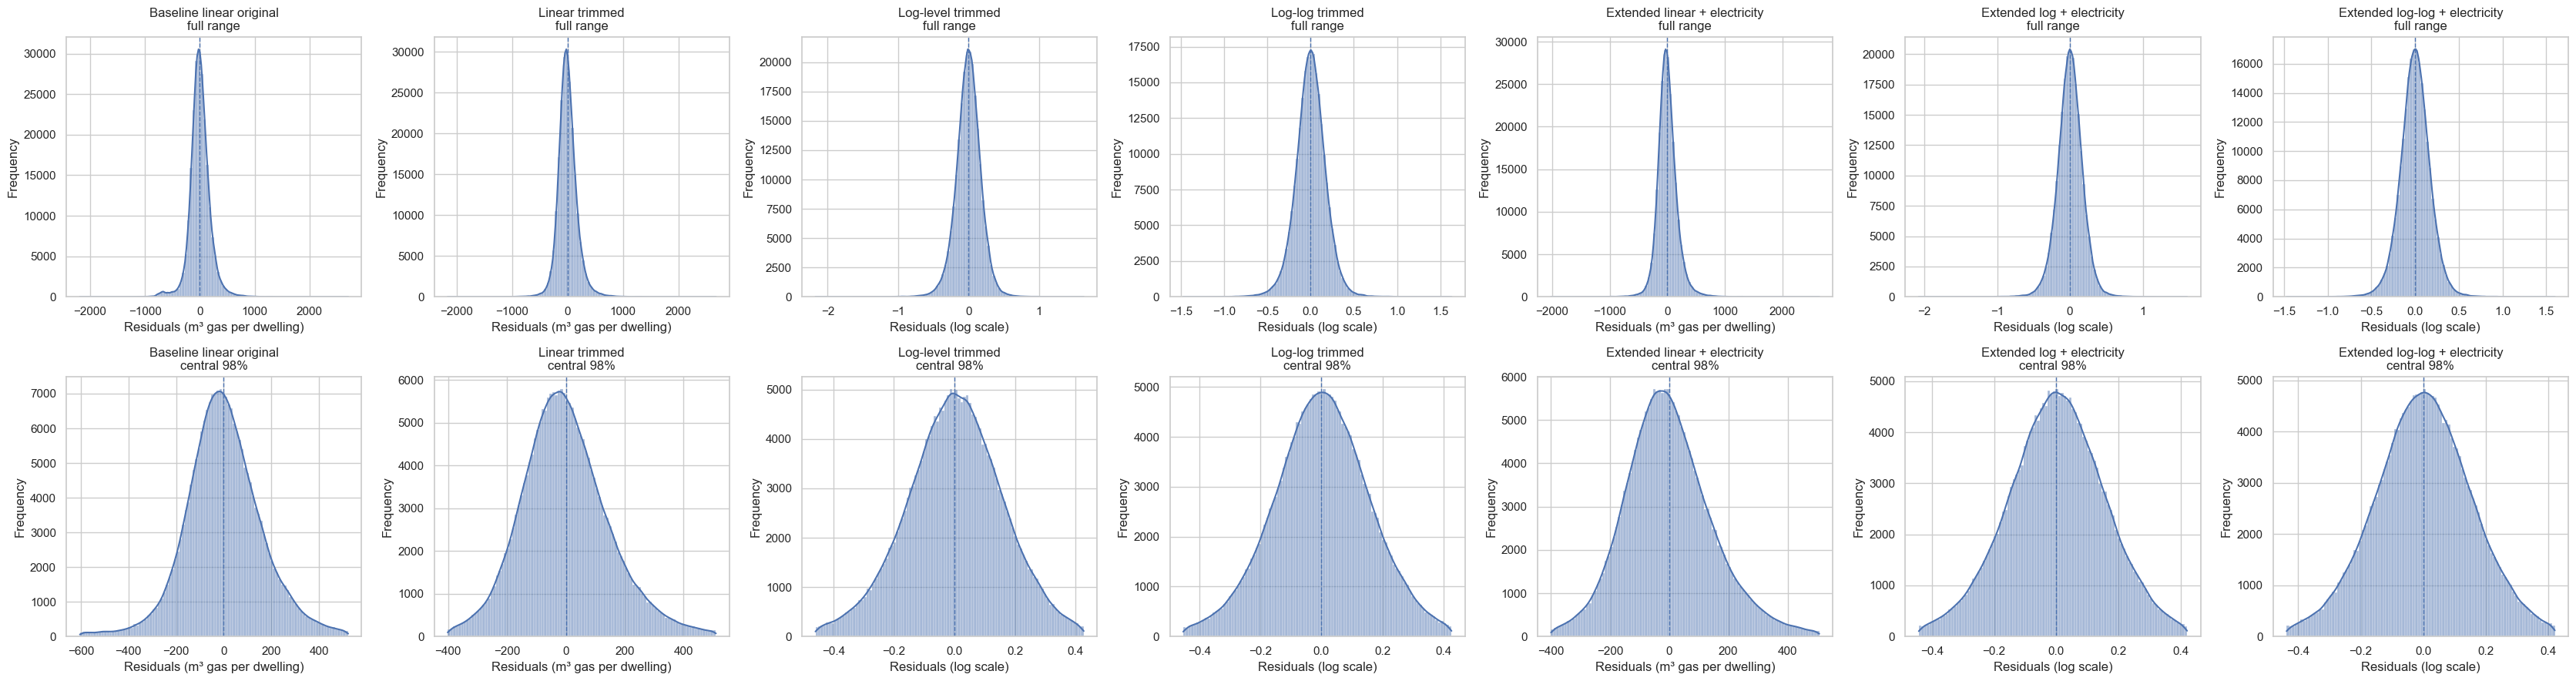

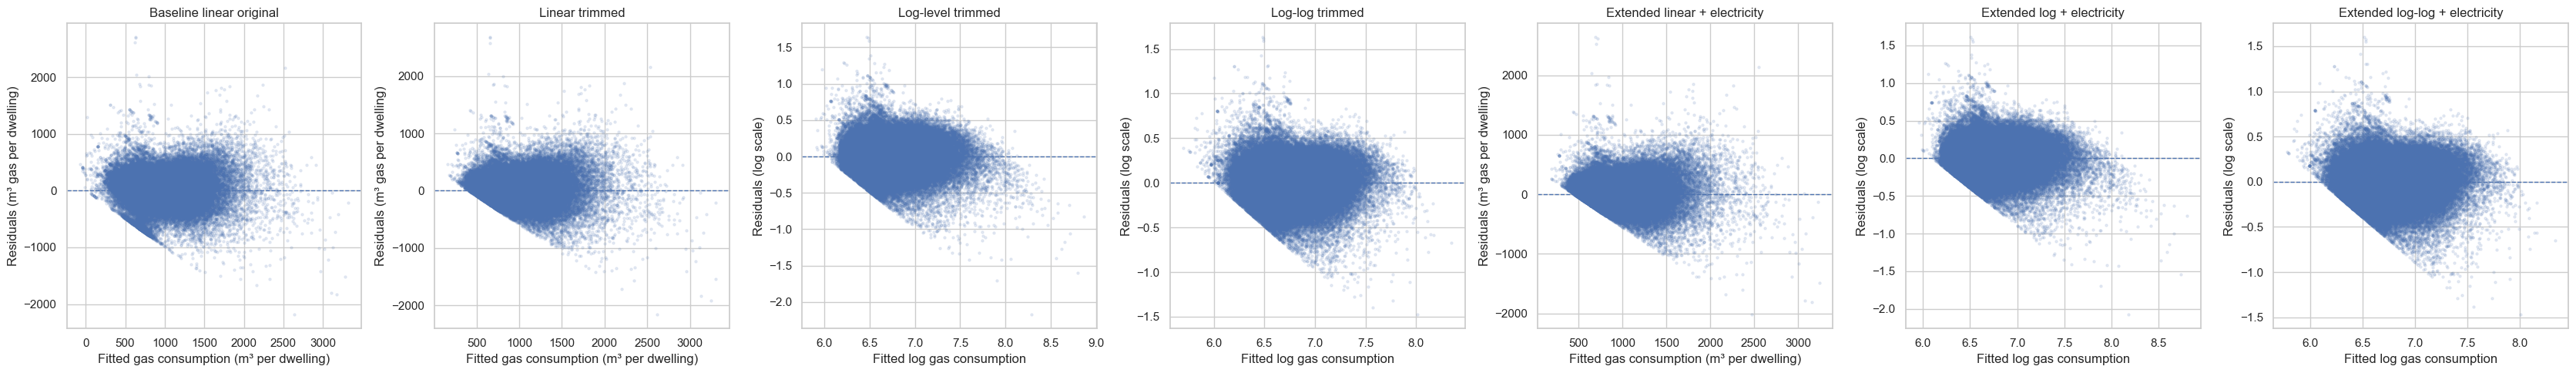

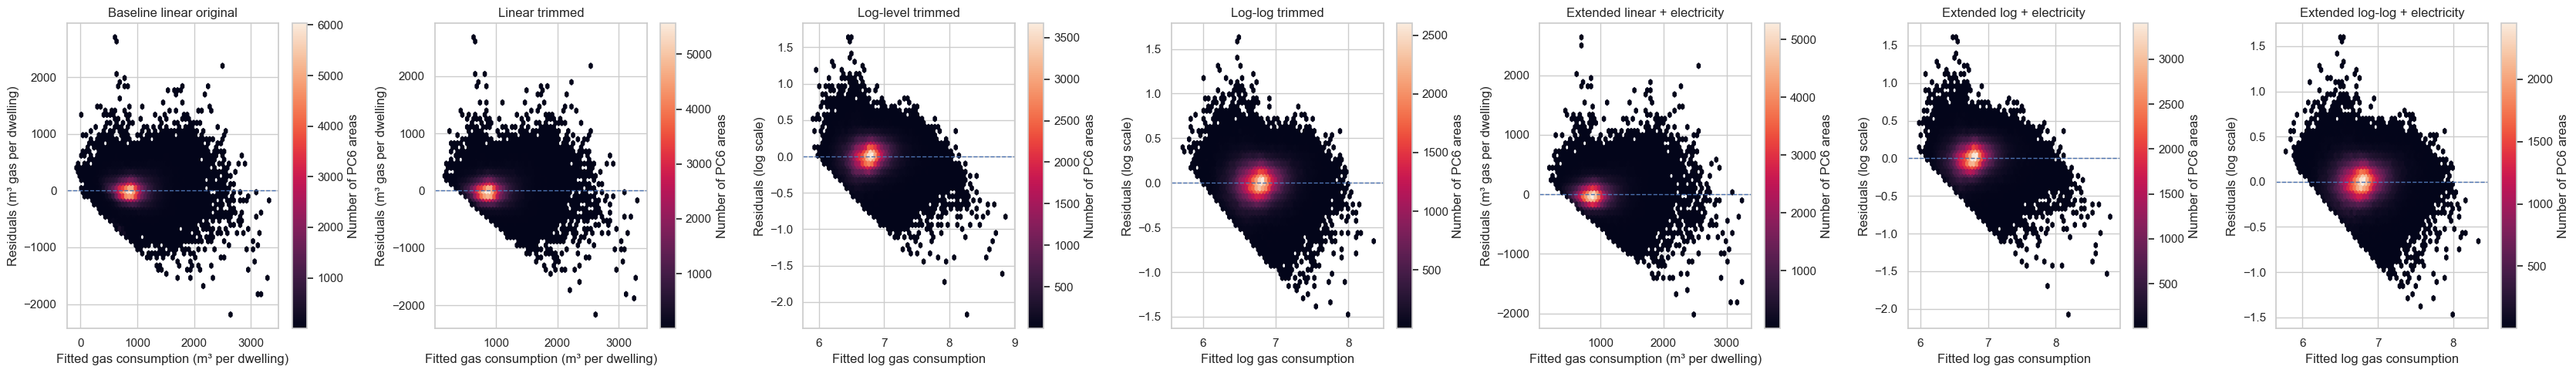

In [93]:
# ----------------------------
# 8.5 Comparison and selection of preferred gas model
# Robust aligned version with original + trimmed + electricity models
# ----------------------------

gas_candidate_models = [
    {
        "name": "Baseline linear original",
        "model": model_gas_linear,
        "scale": "levels",
        "sample": "original",
        "description": "Original gas model",
        "X": X_gas_linear,
        "y": y_gas_linear
    },
    {
        "name": "Linear trimmed",
        "model": model_gas_trim_linear,
        "scale": "levels",
        "sample": "trimmed",
        "description": "Linear model on trimmed gas sample",
        "X": X_gas_trim,
        "y": y_gas_trim_linear
    },
    {
        "name": "Log-level trimmed",
        "model": model_gas_trim_log,
        "scale": "log",
        "sample": "trimmed",
        "description": "Log gas model on trimmed gas sample",
        "X": X_gas_trim,
        "y": y_gas_trim_linear
    },
    {
        "name": "Log-log trimmed",
        "model": model_gas_trim_loglog,
        "scale": "log",
        "sample": "trimmed",
        "description": "Log gas and log floor area on trimmed gas sample",
        "X": X_gas_trim_loglog,
        "y": y_gas_trim_linear
    },
    {
        "name": "Extended linear + electricity",
        "model": model_gas_ext_linear,
        "scale": "levels",
        "sample": "trimmed + electricity",
        "description": "Linear gas model with electricity proxy",
        "X": X_gas_ext,
        "y": y_gas_ext_linear
    },
    {
        "name": "Extended log + electricity",
        "model": model_gas_ext_log,
        "scale": "log",
        "sample": "trimmed + electricity",
        "description": "Log gas model with electricity proxy",
        "X": X_gas_ext,
        "y": y_gas_ext_linear
    },
    {
        "name": "Extended log-log + electricity",
        "model": model_gas_ext_loglog,
        "scale": "log",
        "sample": "trimmed + electricity",
        "description": "Log gas, log floor area, and log electricity",
        "X": X_gas_ext_loglog,
        "y": y_gas_ext_linear
    }
]

# ----------------------------
# 1. Model fit table
# ----------------------------

comparison_stats_gas_final = pd.DataFrame({
    "Model": [m["name"] for m in gas_candidate_models],
    "Sample": [m["sample"] for m in gas_candidate_models],
    "Description": [m["description"] for m in gas_candidate_models],
    "Scale": [m["scale"] for m in gas_candidate_models],
    "Observations": [int(m["model"].nobs) for m in gas_candidate_models],
    "Adj_R2": [m["model"].rsquared_adj for m in gas_candidate_models],
    "AIC": [m["model"].aic for m in gas_candidate_models],
    "BIC": [m["model"].bic for m in gas_candidate_models]
})

comparison_stats_gas_final = comparison_stats_gas_final.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

print("Final gas model comparison:")
display(comparison_stats_gas_final)

# ----------------------------
# 2. Prediction accuracy on original gas scale
# ----------------------------

prediction_rows = []

for item in gas_candidate_models:
    model = item["model"]
    X_model = item["X"]
    y_true = item["y"]

    if item["scale"] == "levels":
        y_pred = model.predict(X_model)
    elif item["scale"] == "log":
        y_pred = np.exp(model.predict(X_model))
    else:
        raise ValueError("Model scale must be either 'levels' or 'log'.")

    errors = y_true - y_pred

    prediction_rows.append({
        "Model": item["name"],
        "Sample": item["sample"],
        "Evaluation_scale": "m³ per dwelling",
        "Observations": len(y_true),
        "MSE_m3": np.mean(errors ** 2),
        "RMSE_m3": np.sqrt(np.mean(errors ** 2)),
        "MAE_m3": np.mean(np.abs(errors)),
        "Mean_signed_error_m3": np.mean(errors)
    })

gas_prediction_comparison = pd.DataFrame(prediction_rows)

gas_prediction_comparison = gas_prediction_comparison.round({
    "MSE_m3": 2,
    "RMSE_m3": 2,
    "MAE_m3": 2,
    "Mean_signed_error_m3": 2
})

print("Prediction accuracy on original gas scale:")
display(gas_prediction_comparison)

# ----------------------------
# 3. Residual histograms: full range and central 98%
# ----------------------------

n_models = len(gas_candidate_models)

fig, axes = plt.subplots(2, n_models, figsize=(4.8 * n_models, 9))

for i, item in enumerate(gas_candidate_models):
    model = item["model"]
    residuals = model.resid

    if item["scale"] == "levels":
        y_label = "Residuals (m³ gas per dwelling)"
    else:
        y_label = "Residuals (log scale)"

    # Full range
    sns.histplot(
        residuals,
        bins=100,
        kde=True,
        ax=axes[0, i]
    )

    axes[0, i].axvline(0, linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{item['name']}\nfull range")
    axes[0, i].set_xlabel(y_label)
    axes[0, i].set_ylabel("Frequency")

    # Central 98%
    r_min = residuals.quantile(0.01)
    r_max = residuals.quantile(0.99)

    sns.histplot(
        residuals[(residuals >= r_min) & (residuals <= r_max)],
        bins=100,
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].axvline(0, linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{item['name']}\ncentral 98%")
    axes[1, i].set_xlabel(y_label)
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# ----------------------------
# 4. Residuals vs fitted values
# ----------------------------

fig, axes = plt.subplots(1, n_models, figsize=(4.8 * n_models, 5))

for ax, item in zip(axes, gas_candidate_models):
    model = item["model"]

    if item["scale"] == "levels":
        x_label = "Fitted gas consumption (m³ per dwelling)"
        y_label = "Residuals (m³ gas per dwelling)"
    else:
        x_label = "Fitted log gas consumption"
        y_label = "Residuals (log scale)"

    ax.scatter(
        model.fittedvalues,
        model.resid,
        s=5,
        alpha=0.12
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(item["name"])
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Hexbin residual density vs fitted values
# ----------------------------

fig, axes = plt.subplots(1, n_models, figsize=(4.8 * n_models, 5))

for ax, item in zip(axes, gas_candidate_models):
    model = item["model"]

    if item["scale"] == "levels":
        x_label = "Fitted gas consumption (m³ per dwelling)"
        y_label = "Residuals (m³ gas per dwelling)"
    else:
        x_label = "Fitted log gas consumption"
        y_label = "Residuals (log scale)"

    hb = ax.hexbin(
        model.fittedvalues,
        model.resid,
        gridsize=60,
        mincnt=1
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(item["name"])
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of PC6 areas")

plt.tight_layout()
plt.show()

### 8.6 Nonlinear benchmark: Random Forest

While the preferred gas regression model captures systematic relationships between dwelling characteristics and gas consumption, it assumes an additive and relatively structured functional form. To assess whether additional nonlinear patterns improve predictive performance, a **Random Forest regression model** is estimated as a benchmark.

Random Forest is an ensemble method that builds multiple decision trees on bootstrap samples of the data and averages their predictions. This allows it to capture:

- nonlinear relationships between predictors and gas consumption  
- interactions between variables automatically  
- threshold effects or complex patterns without manual specification  

**Why use a nonlinear benchmark:**  

- The OLS gas model assumes a structured functional form, which may miss nonlinearities in gas consumption patterns.  
- Gas demand is strongly related to heating behaviour and may contain threshold effects related to dwelling type, insulation quality, gas connection share, and household characteristics.  
- Random Forests provide a flexible, non-parametric benchmark to assess whether additional predictive power is available.  
- This benchmark is purely predictive and does not produce interpretable coefficients.

**Sample definition:**  

The Random Forest benchmark uses the same gas sample definition as the preferred gas regression model. Very low gas consumption observations are excluded using the selected gas threshold. This ensures that the comparison focuses on postcode areas where gas consumption reflects meaningful residential gas use.

**Hyperparameter tuning:**  

To avoid sensitivity to arbitrary parameter choices, a structured grid search is performed:

- `n_estimators = [20, 50, 100, 200]`  
- `max_depth = [5, 10, 15, None]`  

These values test different levels of model complexity while keeping computation feasible.

**Evaluation procedure:**  

The Random Forest model is evaluated using **10-fold cross-validation**, consistent with the gas regression model.

The evaluation metrics are:

- mean squared error (MSE)  
- root mean squared error (RMSE)  
- mean absolute error (MAE)  

The metrics are first evaluated in the same scale as the selected gas model form. If the preferred gas model is log-based, the metrics are first calculated in log-space. If the preferred gas model is linear, they are calculated directly in m³ gas per dwelling.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |\hat{y}_i - y_i|
$$

For interpretability, predictions are also transformed back to the original gas-consumption scale and evaluated in m³ gas per dwelling.

**Interpretation of the metrics:**

- MSE penalizes large prediction errors more strongly because errors are squared before averaging.  
- RMSE represents the typical magnitude of prediction errors and is expressed in the same units as the dependent variable.  
- MAE measures the average absolute prediction error and is less sensitive to extreme observations.  
- RMSE and MAE therefore capture different aspects of predictive performance.  
- Comparing RMSE and MAE helps determine whether improvements are broad-based or driven mainly by a small number of large errors.

**Limitations:**

- Random Forests do not provide interpretable coefficients, limiting their usefulness for structural analysis or policy interpretation.  
- The method is computationally heavier than OLS.  
- Although cross-validation mitigates overfitting, results may still depend on hyperparameter choices.

**Practical usage:**

- Compare MSE, RMSE, and MAE between models.  
- Use RMSE for interpreting typical prediction error.  
- Use MAE to assess average prediction accuracy.  
- Use the benchmark strictly for predictive validation, not interpretation.  
- This complements earlier diagnostics by testing whether the functional form of the regression model is sufficient.

In [94]:
# ----------------------------
# 8.6 Random Forest benchmark for gas
# Consistent with MSE, RMSE, and MAE reporting
# ----------------------------

# ----------------------------
# 1. Choose gas threshold and preferred model form
# ----------------------------

gas_threshold_rf = 440

# Choose dependent variable form:
# "linear"  -> predict gas in m³ per dwelling
# "log"     -> predict log(gas_avg_per_dwelling_pc6)
gas_model_form = "log"

# ----------------------------
# 2. Construct gas RF dataset
# ----------------------------

reg_data_gas_rf = pc6_analysis[
    pc6_analysis["gas_avg_per_dwelling_pc6"] > gas_threshold_rf
].copy()

print("Gas threshold:", gas_threshold_rf)
print("Observations:", len(reg_data_gas_rf))

# ----------------------------
# 3. Identify compositional variables
# ----------------------------

dwelling_cols_full_rf = [
    c for c in reg_data_gas_rf.columns
    if c.startswith("share_dwelling_type_")
]

label_cols_full_rf = [
    c for c in reg_data_gas_rf.columns
    if c.startswith("share_energy_label_")
]

# ----------------------------
# 4. Reference categories
# ----------------------------

ref_dwelling_rf = "share_dwelling_type_Appartement"
ref_label_rf = "share_energy_label_G"

dwelling_cols_rf = [
    c for c in dwelling_cols_full_rf
    if c != ref_dwelling_rf
]

label_cols_rf = [
    c for c in label_cols_full_rf
    if c != ref_label_rf
]

# ----------------------------
# 5. Define predictors
# ----------------------------

structural_vars_rf = [
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas"
]

cbs_vars_rf = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# 6. Construct X and y
# ----------------------------

X_gas_rf_base = reg_data_gas_rf[
    structural_vars_rf
    + dwelling_cols_rf
    + label_cols_rf
    + cbs_vars_rf
].copy()

y_gas_rf_abs = reg_data_gas_rf["gas_avg_per_dwelling_pc6"].copy()

if gas_model_form == "linear":

    X_gas_rf = X_gas_rf_base.copy()
    y_gas_rf = y_gas_rf_abs.copy()

elif gas_model_form == "log":

    X_gas_rf = X_gas_rf_base.copy()
    X_gas_rf["log_mean_floor_area"] = np.log(
        X_gas_rf["mean_floor_area"]
    )
    X_gas_rf = X_gas_rf.drop(columns=["mean_floor_area"])

    y_gas_rf = np.log(y_gas_rf_abs)

else:
    raise ValueError("gas_model_form must be either 'linear' or 'log'")

# ----------------------------
# 7. Cross-validation setup
# ----------------------------

kf_gas = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ----------------------------
# 8. OLS benchmark predictions
# ----------------------------

ols_gas_sk = LinearRegression()

y_pred_ols = cross_val_predict(
    ols_gas_sk,
    X_gas_rf,
    y_gas_rf,
    cv=kf_gas,
    n_jobs=-1
)

# ----------------------------
# 9. Random Forest hyperparameter tuning
# ----------------------------

param_grid_gas = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [5, 10, 15, None]
}

rf_gas = RandomForestRegressor(
    random_state=42
)

grid_gas = GridSearchCV(
    estimator=rf_gas,
    param_grid=param_grid_gas,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_gas.fit(
    X_gas_rf,
    y_gas_rf
)

rf_gas_best = grid_gas.best_estimator_

print("Best RF parameters:", grid_gas.best_params_)

# ----------------------------
# 10. Random Forest cross-validated predictions
# ----------------------------

y_pred_rf = cross_val_predict(
    rf_gas_best,
    X_gas_rf,
    y_gas_rf,
    cv=kf_gas,
    n_jobs=-1
)

# ----------------------------
# 11. Helper function for metrics
# ----------------------------

def calculate_gas_rf_metrics(
    model_name,
    y_true_model_scale,
    y_pred_model_scale,
    y_true_abs,
    model_form
):

    # Metrics in model scale
    mse_model_scale = mean_squared_error(
        y_true_model_scale,
        y_pred_model_scale
    )

    rmse_model_scale = np.sqrt(mse_model_scale)

    mae_model_scale = mean_absolute_error(
        y_true_model_scale,
        y_pred_model_scale
    )

    # Convert predictions to original gas scale
    if model_form == "linear":
        y_pred_abs = y_pred_model_scale.copy()
    elif model_form == "log":
        y_pred_abs = np.exp(y_pred_model_scale)
    else:
        raise ValueError("model_form must be either 'linear' or 'log'.")

    # Metrics in original m³ scale
    mse_abs = mean_squared_error(
        y_true_abs,
        y_pred_abs
    )

    rmse_abs = np.sqrt(mse_abs)

    mae_abs = mean_absolute_error(
        y_true_abs,
        y_pred_abs
    )

    return {
        "Model": model_name,
        "Gas_threshold": gas_threshold_rf,
        "Model_form": model_form,

        "MSE_model_scale": mse_model_scale,
        "RMSE_model_scale": rmse_model_scale,
        "MAE_model_scale": mae_model_scale,

        "MSE_m3": mse_abs,
        "RMSE_m3": rmse_abs,
        "MAE_m3": mae_abs
    }

# ----------------------------
# 12. Final comparison table
# ----------------------------

rf_results_gas = pd.DataFrame([

    calculate_gas_rf_metrics(
        "Preferred gas regression (OLS)",
        y_gas_rf,
        y_pred_ols,
        y_gas_rf_abs,
        gas_model_form
    ),

    calculate_gas_rf_metrics(
        "Random Forest (Optimized)",
        y_gas_rf,
        y_pred_rf,
        y_gas_rf_abs,
        gas_model_form
    )

])

rf_results_gas = rf_results_gas.round({
    "MSE_model_scale": 6,
    "RMSE_model_scale": 4,
    "MAE_model_scale": 4,

    "MSE_m3": 2,
    "RMSE_m3": 2,
    "MAE_m3": 2
})

display(rf_results_gas)

Gas threshold: 440
Observations: 215228
Best RF parameters: {'max_depth': 15, 'n_estimators': 200}


,Model,Gas_threshold,Model_form,MSE_model_scale,RMSE_model_scale,MAE_model_scale,MSE_m3,RMSE_m3,MAE_m3
0,Preferred gas regression (OLS),440,log,0.029889,0.1729,0.1320,29270.37,171.09,122.30
1,Random Forest (Optimized),440,log,0.022790,0.1510,0.1156,22134.74,148.78,107.15


### Interpretation: Nonlinear benchmark results for gas demand

The Random Forest benchmark is evaluated against the preferred gas regression model using 10-fold cross-validation. Model performance is assessed using both **mean squared error (MSE)** and **root mean squared error (RMSE)**.

* **Preferred gas regression (log model):**
  * MSE ≈ 0.0313  
  * RMSE ≈ 0.177 → approximately **17.7% typical relative prediction error**

* **Random Forest (optimized):**
  * MSE ≈ 0.0257  
  * RMSE ≈ 0.160 → approximately **16.0% typical relative prediction error**

Because the model is estimated in log-space, RMSE can be interpreted approximately as the **typical proportional deviation between predicted and observed gas consumption**.

The Random Forest reduces prediction error by:

$$
0.0313 - 0.0257 = 0.0056 \quad (\approx 17.9\%)
$$

In RMSE terms, this corresponds to a reduction of roughly **1.6 percentage points** in typical prediction error.

**Key findings:**

1. **Stronger nonlinear effects than electricity**

   The improvement from Random Forest is more pronounced than in the electricity model. This suggests that **gas consumption contains stronger nonlinearities and interaction effects**, likely related to heating behaviour, insulation, and threshold effects in building characteristics.

2. **Meaningful improvement in predictive accuracy**

   The reduction in RMSE from ~17.7% to ~16.0% indicates a **non-negligible improvement in prediction quality**, showing that nonlinear models capture additional structure beyond the regression specification.

3. **Role of model flexibility**

   Gas demand is more sensitive to structural thresholds (e.g. insulation quality, gas connection presence, dwelling type), which are better captured by tree-based methods. This explains why the Random Forest provides larger gains compared to the electricity case.

4. **Interpretability versus performance trade-off**

   Despite improved predictive performance, the Random Forest does not provide interpretable coefficients. The regression model remains preferable for structural interpretation, while the Random Forest serves as a predictive benchmark.

**Overall interpretation:**

The Random Forest benchmark confirms that **nonlinearities play a more important role in gas demand than in electricity demand**. While the preferred regression model already captures the main structure, the nonlinear model achieves a noticeable improvement in predictive accuracy.

This supports the use of the regression framework for interpretation, while highlighting that gas consumption patterns are inherently more complex and partially nonlinear.

### 8.7 Extended gas specification: nonlinear building age and gas-area interaction

The previous gas regression models considered linear and log-based specifications using the same explanatory variables as the electricity model. However, gas consumption is closely related to residential heating demand, which may not be fully captured by an additive specification.

Two additional mechanisms are particularly relevant for gas consumption.

First, the relationship between construction year and gas demand may be nonlinear. Very old buildings may have higher gas consumption due to lower insulation quality, while newer buildings may consume less gas due to improved energy performance standards. A purely linear construction-year effect may therefore be too restrictive.

Second, the effect of gas availability may depend on dwelling size. A high gas connection share in areas with larger dwellings may imply greater heating-related gas demand than the same gas connection share in areas with smaller dwellings. To capture this, an interaction between gas connection share and logarithmic floor area is introduced.

The extended model therefore adds:

- a centered construction year term  
- a squared centered construction year term  
- an interaction between `share_has_gas` and `log_mean_floor_area`  

The model remains log-based, with the dependent variable defined as:

$$
\log(gas\_avg\_per\_dwelling\_{pc6})
$$

This extended specification is used as a targeted robustness and improvement check. It tests whether theoretically motivated nonlinearities and interactions improve model fit compared to the baseline gas regression models.

In [95]:
# ----------------------------
# 8.7 Extended gas specification
# Nonlinear building age + gas-area interaction
# ----------------------------

# ----------------------------
# 1. Use same gas threshold as preferred gas analysis
# ----------------------------

gas_threshold_ext_model = 440

reg_data_gas_extended = pc6_analysis[
    pc6_analysis["gas_avg_per_dwelling_pc6"] > gas_threshold_ext_model
].copy()

print("Gas threshold:", gas_threshold_ext_model)
print("Observations:", len(reg_data_gas_extended))

# ----------------------------
# 2. Dependent variable
# ----------------------------

y_gas_extended = np.log(reg_data_gas_extended["gas_avg_per_dwelling_pc6"])

# ----------------------------
# 3. Identify compositional variables
# ----------------------------

dwelling_cols_full_extended = [
    c for c in reg_data_gas_extended.columns
    if c.startswith("share_dwelling_type_")
]

label_cols_full_extended = [
    c for c in reg_data_gas_extended.columns
    if c.startswith("share_energy_label_")
]

# ----------------------------
# 4. Reference categories
# ----------------------------

ref_dwelling_extended = "share_dwelling_type_Appartement"
ref_label_extended = "share_energy_label_G"

dwelling_cols_extended = [
    c for c in dwelling_cols_full_extended
    if c != ref_dwelling_extended
]

label_cols_extended = [
    c for c in label_cols_full_extended
    if c != ref_label_extended
]

# ----------------------------
# 5. CBS variables
# ----------------------------

cbs_vars_extended = [
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# ----------------------------
# 6. Construct baseline log-log-style X matrix
# ----------------------------

X_gas_extended = reg_data_gas_extended[
    [
        "mean_floor_area",
        "mean_building_year",
        "share_has_gas"
    ]
    + dwelling_cols_extended
    + label_cols_extended
    + cbs_vars_extended
].copy()

# Log floor area
X_gas_extended["log_mean_floor_area"] = np.log(X_gas_extended["mean_floor_area"])

# Center building year before creating square term
X_gas_extended["building_year_c"] = (
    X_gas_extended["mean_building_year"]
    - X_gas_extended["mean_building_year"].mean()
)

X_gas_extended["building_year_c_sq"] = X_gas_extended["building_year_c"] ** 2

# Interaction: gas connection share × log floor area
X_gas_extended["gas_x_log_floor_area"] = (
    X_gas_extended["share_has_gas"]
    * X_gas_extended["log_mean_floor_area"]
)

# Drop original variables replaced by transformed versions
X_gas_extended = X_gas_extended.drop(
    columns=[
        "mean_floor_area",
        "mean_building_year"
    ]
)

# Add intercept
X_gas_extended = sm.add_constant(X_gas_extended)

# ----------------------------
# 7. Estimate extended model
# ----------------------------

model_gas_extended = sm.OLS(
    y_gas_extended,
    X_gas_extended
).fit()

print("Extended gas model results:")
print(model_gas_extended.summary())

Gas threshold: 440
Observations: 215228
Extended gas model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.665
Model:                                  OLS   Adj. R-squared:                  0.665
Method:                       Least Squares   F-statistic:                 1.425e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:20:54   Log-Likelihood:                 79999.
No. Observations:                    215228   AIC:                        -1.599e+05
Df Residuals:                        215197   BIC:                        -1.596e+05
Df Model:                                30                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err     

### 8.7.1 Comparison with linear specification

To assess whether the improvements introduced in the extended specification are driven by the functional form or by the additional nonlinear and interaction terms, a linear version of the extended model is also estimated.

In this specification:

- the dependent variable remains in levels  
- nonlinear terms (quadratic building year) and interaction effects are retained  
- floor area is not logged  

This allows a direct comparison between:

- linear specification with extended structure  
- log-based specifications (log-level, log-log, extended log)  

The comparison helps determine whether improvements arise from:

- functional form (log transformation)  
- or from the additional structural features introduced in the extended model

In [96]:
# ----------------------------
# 8.7 Linear version of extended gas model
# ----------------------------

# Dependent variable in levels
y_gas_extended_linear = reg_data_gas_extended["gas_avg_per_dwelling_pc6"]

# Rebuild X without log transformation
X_gas_extended_linear = reg_data_gas_extended[
    [
        "mean_floor_area",
        "mean_building_year",
        "share_has_gas"
    ]
    + dwelling_cols_extended
    + label_cols_extended
    + cbs_vars_extended
].copy()

# Center building year
X_gas_extended_linear["building_year_c"] = (
    X_gas_extended_linear["mean_building_year"]
    - X_gas_extended_linear["mean_building_year"].mean()
)

X_gas_extended_linear["building_year_c_sq"] = (
    X_gas_extended_linear["building_year_c"] ** 2
)

# Interaction (linear version uses raw floor area)
X_gas_extended_linear["gas_x_area"] = (
    X_gas_extended_linear["share_has_gas"]
    * X_gas_extended_linear["mean_floor_area"]
)

# Drop original year (since replaced by centered version)
X_gas_extended_linear = X_gas_extended_linear.drop(columns=["mean_building_year"])

# Add intercept
X_gas_extended_linear = sm.add_constant(X_gas_extended_linear)

# Estimate model
model_gas_extended_linear = sm.OLS(
    y_gas_extended_linear,
    X_gas_extended_linear
).fit()

print("Extended linear gas model results:")
print(model_gas_extended_linear.summary())

Extended linear gas model results:
                               OLS Regression Results                               
Dep. Variable:     gas_avg_per_dwelling_pc6   R-squared:                       0.675
Model:                                  OLS   Adj. R-squared:                  0.675
Method:                       Least Squares   F-statistic:                 1.493e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:20:54   Log-Likelihood:            -1.4063e+06
No. Observations:                    215228   AIC:                         2.813e+06
Df Residuals:                        215197   BIC:                         2.813e+06
Df Model:                                30                                         
Covariance Type:                  nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025    

In [97]:
# ----------------------------
# 8.7 Comparison: all gas models
# ----------------------------

gas_full_comparison = pd.DataFrame({
    "Model": [
        "Linear baseline",
        "Log-level",
        "Log-log",
        "Extended log",
        "Extended linear"
    ],
    "Observations": [
        int(model_gas_linear.nobs),
        int(model_gas_log.nobs),
        int(model_gas_loglog.nobs),
        int(model_gas_extended.nobs),
        int(model_gas_extended_linear.nobs)
    ],
    "Adj_R2": [
        model_gas_linear.rsquared_adj,
        model_gas_log.rsquared_adj,
        model_gas_loglog.rsquared_adj,
        model_gas_extended.rsquared_adj,
        model_gas_extended_linear.rsquared_adj
    ],
    "AIC": [
        model_gas_linear.aic,
        model_gas_log.aic,
        model_gas_loglog.aic,
        model_gas_extended.aic,
        model_gas_extended_linear.aic
    ],
    "BIC": [
        model_gas_linear.bic,
        model_gas_log.bic,
        model_gas_loglog.bic,
        model_gas_extended.bic,
        model_gas_extended_linear.bic
    ]
})

gas_full_comparison = gas_full_comparison.round({
    "Adj_R2": 4,
    "AIC": 1,
    "BIC": 1
})

display(gas_full_comparison)

,Model,Observations,Adj_R2,AIC,BIC
0,Linear baseline,222089,0.6315,2959397.1,2959696.1
1,Log-level,222089,0.3679,193399.3,193698.3
2,Log-log,222089,0.3664,193932.8,194231.8
3,Extended log,215228,0.6652,-159936.9,-159618.3
4,Extended linear,215228,0.6754,2812686.0,2813004.6


### 8.7.2 Interpretation of extended gas model results

The extended gas specification introduces nonlinear building age effects and interaction terms between gas availability and dwelling size. The results are compared with the baseline linear, log-level, and log-log specifications.

**Important note on comparability**

The extended models are estimated on a slightly smaller sample due to the inclusion of additional transformations and filtering. As a result, AIC and BIC values are only directly comparable within models estimated on the same sample and with the same dependent variable transformation. In particular:

- AIC/BIC from linear models cannot be directly compared with log-based models  
- comparisons should focus on patterns within model families and on adjusted \(R^2\) and predictive performance  

**Key findings**

1. **Substantial improvement from structural extensions**

The extended models show a large increase in explanatory power:

- Log-log baseline: Adjusted \(R^2 \approx 0.366\)  
- Extended log model: Adjusted \(R^2 \approx 0.668\)  
- Extended linear model: Adjusted \(R^2 \approx 0.678\)  

This indicates that introducing nonlinear building age and interaction effects captures a significant portion of variation in gas consumption that was not explained by the baseline specifications.

2. **Nonlinear building age is highly relevant**

The strong improvement in model fit suggests that the relationship between construction year and gas consumption is not well described by a linear term. Instead, gas demand varies nonlinearly across building vintages, consistent with differences in insulation standards and heating efficiency across cohorts.

3. **Interaction between gas availability and dwelling size matters**

The inclusion of the interaction term between `share_has_gas` and floor area significantly improves model performance. This confirms that gas consumption depends not only on whether dwellings are connected to gas, but also on the scale of heating demand, which is closely related to dwelling size.

4. **Extended linear model shows highest in-sample fit**

The extended linear model achieves the highest adjusted \(R^2\). However, this should be interpreted with caution:

- Linear models in levels may be more sensitive to extreme values  
- Log-based models remain preferable for interpretation and stability, especially when the dependent variable is skewed  

5. **Implications for model selection**

The results indicate that **model structure is more important than functional form alone**. The baseline log transformations improve stability, but the largest gains come from incorporating:

- nonlinear effects  
- interaction terms grounded in the physical interpretation of gas consumption  

**Overall conclusion**

The extended specification demonstrates that gas consumption at the postcode level is strongly influenced by nonlinear housing characteristics and their interactions. While log-based models remain attractive for interpretability, the results highlight that incorporating theoretically motivated nonlinearities is essential for capturing the underlying structure of residential gas demand.

These findings suggest that the preferred gas model should include at least:

- nonlinear building age effects  
- interaction between gas availability and dwelling size  

as part of the final specification.

# Chapter 9 Regression-informed Standard Load Profile scaling

The previous chapters developed and evaluated regression models for estimating average annual residential electricity consumption at PC6 level. This chapter connects those annual predictions to temporal demand reconstruction using Dutch Standard Load Profiles (SLPs).

The SLP dataset contains quarter-hourly profile fractions. These fractions describe how annual electricity consumption is distributed across the year. By multiplying an annual electricity value by the SLP fraction for each quarter-hour, an annual consumption estimate can be translated into a quarter-hourly load profile.

This chapter compares two profile-generation approaches:

1. Observed SLP scaling, where the SLP is scaled using observed CBS annual electricity consumption.
2. Regression-informed SLP scaling, where the same SLP is scaled using annual electricity consumption predicted by the preferred regression model.

The purpose is not to reproduce the full Dutch settlement methodology or to improve upon observed annual consumption. Instead, the objective is to assess how much the generated load profile changes when observed annual electricity consumption is replaced by regression-predicted annual consumption.

Only the SLP profile fractions are used. Tariff correction, climate correction, and measurement correction factors from the official profiling methodology are not applied, because the comparison focuses only on the effect of replacing the annual scaling value.

## 9.1 Import and preparation of Dutch electricity Standard Load Profiles

This section imports the 2026 Dutch electricity Standard Load Profile dataset from ENERGIEDATA WIJZER and converts it into a structured quarter-hourly time series.

The file contains profile fractions for several electricity profile categories. Each profile column represents a standardized annual demand shape. The profile fractions can be multiplied by an annual electricity consumption value to obtain quarter-hourly electricity consumption.

For this chapter, the profile `E1A_AZI_A` is selected as the representative residential consumption profile. This profile corresponds to small-consumer electricity demand without feed-in. It is therefore suitable for the main comparison, which focuses on CBS net electricity consumption rather than PV export or gross household electricity demand.

The purpose of this section is to:

- load the SLP file
- extract available profile categories
- verify the quarter-hourly timestamp structure
- check the annual sum of the selected SLP profile
- select the profile fraction series used in the following sections

In [105]:
# ----------------------------
# 9.1 Import and structure Dutch Standard Load Profiles
# ----------------------------

from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# Helper function
# ----------------------------

def read_dutch_slp_csv(csv_path):
    """
    Read Dutch ENERGIEDATA WIJZER electricity SLP CSV.

    Returns
    -------
    pd.DataFrame
        Index: quarter-hour timestamps
        Columns: from, to, and SLP profile fraction columns
    """

    # Read first line to extract profile names
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        header_line = f.readline().strip()

    parts = header_line.split(";")

    raw_names = [
        p for p in parts[3:]
        if p != ""
    ]

    # Remove version prefix, e.g. 1.00_E1A_AZI_A -> E1A_AZI_A
    profile_names = [
        n.split("_", 1)[1]
        if "_" in n
        else n
        for n in raw_names
    ]

    # Read time-series body
    df = pd.read_csv(
        csv_path,
        sep=";",
        encoding="utf-8-sig",
        decimal=".",
        skiprows=7,
        header=None
    )

    # Drop trailing empty column if present
    if df.iloc[:, -1].isna().all():
        df = df.iloc[:, :-1]

    # Assign columns
    df.columns = (
        ["time", "from", "to"]
        + profile_names
    )

    # Parse timestamp
    df["time"] = pd.to_datetime(
        df["time"],
        dayfirst=True,
        errors="coerce"
    )

    # Set timestamp index
    df = (
        df
        .dropna(subset=["time"])
        .set_index("time")
    )

    df.index.name = "time"

    return df


# ----------------------------
# Load SLP file
# ----------------------------

slp_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\SLP"
) / "Standaardprofielen elektriciteit 2026 versie 1.00.csv"

slp_df = read_dutch_slp_csv(slp_path)


# ----------------------------
# Identify SLP profile columns
# ----------------------------

profile_cols = [
    c for c in slp_df.columns
    if c not in ["from", "to"]
]


# ----------------------------
# Basic inspection
# ----------------------------

print("SLP shape:")
print(slp_df.shape)

print("\nNumber of profiles:")
print(len(profile_cols))

print("\nAvailable profiles:")
print(profile_cols)

print("\nDate range:")
print(slp_df.index.min())
print(slp_df.index.max())

print("\nTime step distribution:")
display(
    slp_df.index
    .to_series()
    .diff()
    .value_counts()
)

print("\nPreview:")
display(
    slp_df.iloc[:5, :8]
)


# ----------------------------
# Check annual profile fraction sums
# ----------------------------

profile_sums = (
    slp_df[profile_cols]
    .sum()
    .sort_index()
)

print("\nAnnual profile fraction sums:")
display(
    profile_sums.to_frame("annual_sum")
)


# ----------------------------
# Select residential consumption SLP
# ----------------------------

selected_slp = "E1A_AZI_A"

if selected_slp not in profile_cols:
    raise ValueError(
        f"Selected SLP profile '{selected_slp}' not found in SLP columns."
    )

slp_fraction = slp_df[selected_slp].copy()

print("\nSelected SLP profile:")
print(selected_slp)

print("\nSelected SLP annual sum:")
print(slp_fraction.sum())

display(
    slp_fraction.head()
)

SLP shape:
(35040, 32)

Number of profiles:
30

Available profiles:
['E1A_AZI_A', 'E1A_AZI_I', 'E1A_AMI_A', 'E1A_AMI_I', 'E1B_AZI_A', 'E1B_AZI_I', 'E1B_AMI_A', 'E1B_AMI_I', 'E1C_AZI_A', 'E1C_AZI_I', 'E1C_AMI_A', 'E1C_AMI_I', 'E2A_AZI_A', 'E2A_AZI_I', 'E2A_AMI_A', 'E2A_AMI_I', 'E2B_AZI_A', 'E2B_AZI_I', 'E2B_AMI_A', 'E2B_AMI_I', 'E3A_A', 'E3A_I', 'E3B_A', 'E3B_I', 'E3C_A', 'E3C_I', 'E3D_A', 'E3D_I', 'E4A_A', 'E4A_I']

Date range:
2026-01-01 00:15:00
2027-01-01 00:00:00

Time step distribution:


time
0 days 00:15:00    35039
Name: count, dtype: int64


Preview:


,from,to,E1A_AZI_A,E1A_AZI_I,E1A_AMI_A,E1A_AMI_I,E1B_AZI_A,E1B_AZI_I
time,,,,,,,,
2026-01-01 00:15:00,01-01-2026 00:00,01-01-2026 00:15,0.000030,2.000000e-08,0.000037,2.000000e-08,0.000065,6.000000e-08
2026-01-01 00:30:00,01-01-2026 00:15,01-01-2026 00:30,0.000030,2.000000e-08,0.000036,2.000000e-08,0.000064,7.000000e-08
2026-01-01 00:45:00,01-01-2026 00:30,01-01-2026 00:45,0.000029,2.000000e-08,0.000036,2.000000e-08,0.000062,7.000000e-08
2026-01-01 01:00:00,01-01-2026 00:45,01-01-2026 01:00,0.000028,2.000000e-08,0.000035,2.000000e-08,0.000061,7.000000e-08
2026-01-01 01:15:00,01-01-2026 01:00,01-01-2026 01:15,0.000028,2.000000e-08,0.000035,2.000000e-08,0.000059,7.000000e-08



Annual profile fraction sums:


,annual_sum
E1A_AMI_A,0.999999
E1A_AMI_I,0.999997
E1A_AZI_A,0.999999
E1A_AZI_I,0.999997
E1B_AMI_A,2.000000
E1B_AMI_I,1.999999
E1B_AZI_A,2.000000
E1B_AZI_I,1.999999
E1C_AMI_A,2.000000
E1C_AMI_I,1.999999



Selected SLP profile:
E1A_AZI_A

Selected SLP annual sum:
0.99999916


time
2026-01-01 00:15:00    0.000030
2026-01-01 00:30:00    0.000030
2026-01-01 00:45:00    0.000029
2026-01-01 01:00:00    0.000028
2026-01-01 01:15:00    0.000028
Name: E1A_AZI_A, dtype: float64

Inspection of the selected profile (`E1A_AZI_A`) confirmed that the annual sum of all quarter-hour fractions equals approximately one (0.99999916). This verifies that the profile can be interpreted as a normalized annual distribution and directly scaled using annual electricity consumption values.

## 9.2 Selection of a representative postcode area in Alkmaar

Rather than reconstructing profiles for multiple postcode areas, this section selects a single representative case study from the municipality of Alkmaar.

The selected postcode area is defined as the postcode whose observed annual electricity consumption per dwelling is closest to the median observed electricity consumption within Alkmaar.

Using a median postcode area avoids focusing on unusually high or low consumption cases and provides a representative illustration of how annual prediction differences propagate into reconstructed quarter-hour demand profiles.

For the selected postcode area, both:

- observed annual electricity consumption from CBS
- predicted annual electricity consumption from the preferred regression model

are retained for profile reconstruction in the following sections.

In [117]:
# ----------------------------
# 9.2 Select representative Alkmaar PC6
# ----------------------------

alkmaar_df = reg_data.copy()

alkmaar_df["annual_obs_kwh"] = np.exp(y_true_log_arr)
alkmaar_df["annual_pred_kwh"] = np.exp(y_pred_log_arr)

alkmaar_df = (
    alkmaar_df[
        alkmaar_df["municipality_code"]
        .astype(str)
        .str.contains(
            "0361",
            na=False
        )
    ]
    .copy()
)

median_target = (
    alkmaar_df["annual_obs_kwh"]
    .median()
)

selected_idx = (
    (
        alkmaar_df["annual_obs_kwh"]
        -
        median_target
    )
    .abs()
    .idxmin()
)

selected_pc6 = (
    alkmaar_df
    .loc[selected_idx]
)

prediction_error = (
    100
    *
    (
        selected_pc6["annual_pred_kwh"]
        -
        selected_pc6["annual_obs_kwh"]
    )
    /
    selected_pc6["annual_obs_kwh"]
)

display(
    pd.DataFrame({
        "Metric": [
            "PC6",
            "Observed annual kWh",
            "Predicted annual kWh",
            "Prediction error (%)"
        ],
        "Value": [
            selected_pc6["postcode"],
            selected_pc6["annual_obs_kwh"],
            selected_pc6["annual_pred_kwh"],
            prediction_error
        ]
    })
)

,Metric,Value
0,PC6,1815LK
1,Observed annual kWh,2210.0
2,Predicted annual kWh,2058.161563
3,Prediction error (%),-6.870518


### Interpretation of representative postcode selection

A representative postcode area was selected from Alkmaar by identifying the observation whose annual electricity consumption per dwelling is closest to the median observed consumption within the municipality.

The selected postcode area is **1815LK**.

For this postcode:

- observed annual electricity consumption equals **2210 kWh per dwelling**
- predicted annual electricity consumption equals **2058 kWh per dwelling**
- resulting prediction deviation equals **−6.9%**

This relatively small deviation makes the selected case suitable for illustrating how annual electricity predictions propagate into reconstructed quarter-hour load profiles without being dominated by extreme prediction errors.

The following sections therefore compare observed and regression-informed profile reconstruction for a representative residential postcode area in Alkmaar.

## 9.3 Reconstruction of observed and regression-informed load profiles

Using the selected postcode area, quarter-hour electricity demand profiles are reconstructed using the selected Dutch Standard Load Profile.

Quarter-hour electricity demand is reconstructed as:

$$
L_t=SLP_t\times E
$$

where:

- $L_t$ is quarter-hour electricity demand
- $SLP_t$ is the quarter-hour fraction from the selected Standard Load Profile
- $E$ is annual electricity consumption

Two alternative reconstructions are created:

Observed profile:

$$
L_t^{obs}=SLP_t\times E^{obs}
$$

Predicted profile:

$$
L_t^{pred}=SLP_t\times E^{pred}
$$

Because identical SLP fractions are used, differences between the reconstructed profiles reflect only differences in annual electricity estimation.

In [118]:
# ----------------------------
# 9.3 Reconstruct profiles
# ----------------------------

annual_obs = selected_pc6["annual_obs_kwh"]

annual_pred = selected_pc6["annual_pred_kwh"]

profile_df = pd.DataFrame(
    index=slp_df.index
)

profile_df["observed_kwh"] = (
    slp_df[selected_slp]
    *
    annual_obs
)

profile_df["predicted_kwh"] = (
    slp_df[selected_slp]
    *
    annual_pred
)

profile_df["difference_kwh"] = (
    profile_df["predicted_kwh"]
    -
    profile_df["observed_kwh"]
)

display(
    profile_df.head()
)

print(
    "Observed annual reconstruction:",
    profile_df["observed_kwh"].sum()
)

print(
    "Predicted annual reconstruction:",
    profile_df["predicted_kwh"].sum()
)

,observed_kwh,predicted_kwh,difference_kwh
time,,,
2026-01-01 00:15:00,0.066676,0.062095,-0.004581
2026-01-01 00:30:00,0.065372,0.060880,-0.004491
2026-01-01 00:45:00,0.064134,0.059728,-0.004406
2026-01-01 01:00:00,0.062698,0.058390,-0.004308
2026-01-01 01:15:00,0.061261,0.057052,-0.004209


Observed annual reconstruction: 2209.9981436
Predicted annual reconstruction: 2058.159833956861


## 9.4 Comparison of reconstructed load profiles

This subsection compares reconstructed electricity demand obtained using observed and predicted annual electricity consumption.

Because identical Standard Load Profile fractions are used, differences in temporal structure are not expected. Instead, the comparison evaluates how annual prediction deviations translate into reconstructed quarter-hour electricity demand.

The comparison focuses on:

- annual electricity difference  
- visual comparison of reconstructed daily profiles  

The objective is not to validate the Standard Load Profile itself, but to illustrate how annual prediction uncertainty propagates into reconstructed demand estimates.

,Metric,Value
0,Observed annual kWh,2210.00
1,Predicted annual kWh,2058.16
2,Difference (%),-6.87


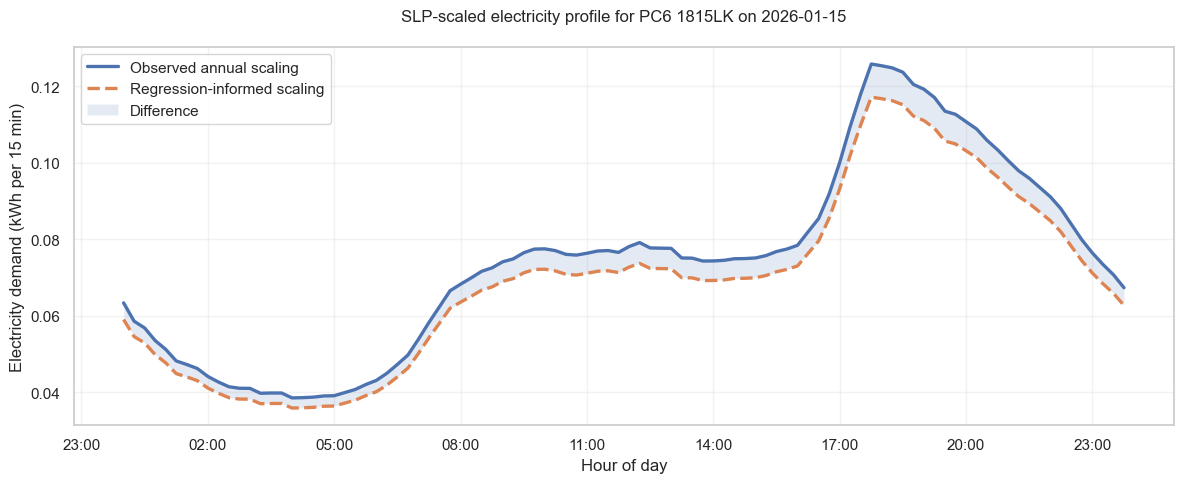

In [123]:
# ----------------------------
# 9.4 Compare reconstructed profiles
# ----------------------------

import matplotlib.dates as mdates

observed_annual = profile_df["observed_kwh"].sum()
predicted_annual = profile_df["predicted_kwh"].sum()

difference_pct = (
    100
    *
    (
        predicted_annual
        -
        observed_annual
    )
    /
    observed_annual
)

comparison = pd.DataFrame({

    "Metric": [
        "Observed annual kWh",
        "Predicted annual kWh",
        "Difference (%)"
    ],

    "Value": [
        observed_annual,
        predicted_annual,
        difference_pct
    ]

})

display(
    comparison.round(2)
)

# ----------------------------
# Daily comparison
# ----------------------------

plot_day = "2026-01-15"

temp = profile_df.loc[
    profile_df.index.date
    ==
    pd.to_datetime(plot_day).date()
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    temp.index,
    temp["observed_kwh"],
    linewidth=2.4,
    label="Observed annual scaling"
)

plt.plot(
    temp.index,
    temp["predicted_kwh"],
    linewidth=2.4,
    linestyle="--",
    label="Regression-informed scaling"
)

plt.fill_between(
    temp.index,
    temp["observed_kwh"],
    temp["predicted_kwh"],
    alpha=0.15,
    label="Difference"
)

plt.title(
    f"SLP-scaled electricity profile for PC6 {selected_pc6['postcode']} on {plot_day}\n"
)

plt.xlabel("Hour of day")

plt.ylabel(
    "Electricity demand (kWh per 15 min)"
)

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=3)
)

plt.grid(alpha=0.25)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()

### Interpretation of reconstructed profile comparison

For the selected representative Alkmaar postcode area, the observed annual electricity consumption is **2210 kWh per dwelling**, while the regression-informed estimate is **2058 kWh per dwelling**. This corresponds to a difference of approximately **−6.9%**.

Because both reconstructions use the same Standard Load Profile, the temporal shape of the two profiles is identical by construction. The regression-informed profile is therefore not a different demand shape, but a lower scaled version of the same profile.

The shaded area in the daily profile shows how the annual prediction difference propagates across all quarter-hour intervals. The difference is largest in absolute terms during periods of higher demand, especially around the evening peak, and smallest during low-demand night-time periods.

This comparison illustrates that, under SLP-based reconstruction, uncertainty in annual electricity estimation directly translates into proportional uncertainty in reconstructed quarter-hour demand.

## TO DO
1. Quantiles on model error and vizualisation.
2. Add gas into the analysis.
3. a Inspect why we have this error. Is it always overshooting or undershooting or is it random?
4. b Error distribution, location of the error, worst values, best values. 
5. c When is our prediction very accurate? 
6. 2 Branches one for socioeconomic and one for +gas.
7. Create a flowchart overview of the pipeline.
8. a !!!!!!!!! Change the normalization step!!!!!!!
8. b In chapter 5 remove share unoccupied by regressing on average energy consumption -> THEN do the normalization with the full set of variables. 

# ----------------------------NOT IN USE----------------------------

### 5.4B Association between PC6 composition and average energy

After applying the variable decisions from Diagnostic 5.4A, we compute the association between PC6 composition variables and average energy consumption per dwelling.

The composition variables include:

- postcode size:
  - `n_dwellings`

- structural averages:
  - `mean_floor_area`
  - `mean_building_year`

- structural shares:
  - `share_has_gas`
  - dwelling type shares
  - energy label shares

- CBS-derived variables:
  - `avg_woz_value_filled`
  - `avg_household_size_filled`
  - `avg_household_size_missing`
  - `share_population_on_benefits_filled`

Average energy indicators:

- `kwh_avg_per_dwelling_pc6`
- `gas_avg_per_dwelling_pc6`
- `pv_avg_per_dwelling_pc6`

Spearman correlation is used because the variables may be skewed and relationships are not necessarily linear. Including `n_dwellings` allows us to check whether average per-dwelling energy indicators remain associated with postcode size.

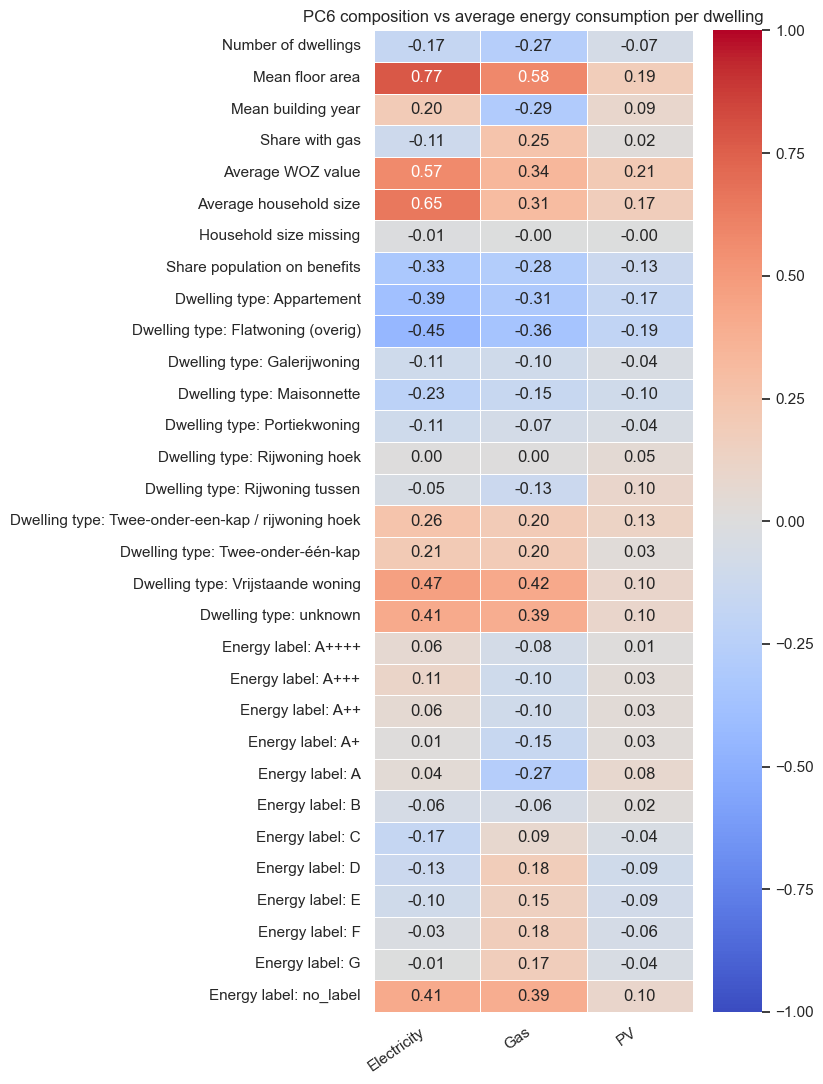

In [ ]:
# ----------------------------
# 5.4B PC6 composition vs average energy
# ----------------------------

energy_vars = [
    "kwh_avg_per_dwelling_pc6",
    "gas_avg_per_dwelling_pc6",
    "pv_avg_per_dwelling_pc6"
]

composition_vars = [
    "n_dwellings",
    "mean_floor_area",
    "mean_building_year",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# add dwelling type shares
composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_dwelling_type_")
]

# add energy label shares
composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_energy_label_")
]

# compute correlation block
corr_block = (
    pc6_analysis[composition_vars + energy_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_vars]
)

# readable labels
row_label_map = {
    "n_dwellings": "Number of dwellings",
    "mean_floor_area": "Mean floor area",
    "mean_building_year": "Mean building year",
    "share_has_gas": "Share with gas",
    "avg_woz_value_filled": "Average WOZ value",
    "avg_household_size_filled": "Average household size",
    "avg_household_size_missing": "Household size missing",
    "share_population_on_benefits_filled": "Share population on benefits"
}

corr_block_plot = corr_block.rename(index=row_label_map)

corr_block_plot.index = (
    corr_block_plot.index
    .str.replace("share_dwelling_type_", "Dwelling type: ", regex=False)
    .str.replace("share_energy_label_", "Energy label: ", regex=False)
)

corr_block_plot = corr_block_plot.rename(columns={
    "kwh_avg_per_dwelling_pc6": "Electricity",
    "gas_avg_per_dwelling_pc6": "Gas",
    "pv_avg_per_dwelling_pc6": "PV"
})

plt.figure(figsize=(8, 11))

ax = sns.heatmap(
    corr_block_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("PC6 composition vs average energy consumption per dwelling")
plt.tight_layout()
plt.show()

### Interpretation of Association between PC6 composition and average energy

The correlation matrix highlights how PC6 composition relates to average energy consumption per dwelling.

**Postcode size**

- `n_dwellings` shows weak correlations (electricity: -0.17, gas: -0.27), indicating that average energy largely removes the mechanical size effect.
- Larger postcode areas tend to have slightly lower consumption per dwelling, consistent with denser urban areas.

**Structural characteristics**

- `mean_floor_area` is the strongest driver (electricity: 0.77, gas: 0.58), indicating that larger dwellings consume more energy per unit.
- `mean_building_year` is negatively related to gas (-0.29), suggesting newer buildings rely less on gas.
- `share_has_gas` is positively related to gas consumption (0.25), reflecting heating system dependence.

**Socioeconomic characteristics**

- `avg_woz_value` (0.57 electricity, 0.34 gas) and `avg_household_size` (0.65 electricity, 0.31 gas) show strong positive associations with energy use.
- `share_population_on_benefits` is negatively related to energy (-0.33 electricity, -0.28 gas), indicating lower consumption in lower-income areas.
- The missing indicator has near-zero correlations, confirming its purely technical role.

**Dwelling type composition**

- High-density housing (e.g. apartments: -0.39 electricity, -0.31 gas) is associated with lower energy use.
- Low-density housing (e.g. detached: 0.47 electricity, 0.42 gas) is associated with higher energy use.
- This confirms that housing typology is a key determinant of energy intensity.

**Energy labels and PV**

- Energy label shares show relatively weak and mixed relationships.
- PV correlations are generally small, indicating weaker structural dependence.

**Conclusion**

Average energy consumption per dwelling is primarily driven by dwelling size, housing type, and household composition. Socioeconomic factors contribute, but less strongly. The weak correlation with postcode size confirms that average energy successfully captures structural variation rather than scale effects.

### 6.4.2 Breusch-Pagan (BP) test

The **Breusch-Pagan test** is used to detect whether the variance of regression residuals depends on the explanatory variables. It tests the key OLS assumption of **homoskedasticity**:

$$
Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
$$

where $X_1, X_2, \dots, X_k$ are all predictor variables in the model. If this assumption fails, standard errors computed by conventional OLS may be biased, which affects t-values, p-values, and confidence intervals.

The test is applied to the **preferred log-log specification**, estimated on the full dataset using the correctly specified set of explanatory variables (including logarithmic floor area and excluding redundant compositional categories).

#### Hypotheses

- **Null hypothesis ($H_0$):** Residual variance is constant across observations  
  $$
  H_0: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
  $$

- **Alternative hypothesis ($H_1$):** Residual variance depends on one or more predictors  
  $$
  H_1: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = f(X_1, X_2, \dots, X_k)
  $$

#### Breusch-Pagan statistics

1. **Lagrange Multiplier (LM) statistic:**  
   - Measures the overall deviation from constant variance by regressing squared residuals on all predictors.  
   - Large LM values indicate stronger evidence against $H_0$.

2. **LM p-value:**  
   - Probability of observing an LM statistic as extreme as the one calculated, **assuming $H_0$ is true**.  
   - A small LM p-value (e.g., < 0.05) indicates that residual variance likely depends on the predictors.

3. **F-value:**  
   - Obtained by running an auxiliary F-test using the same regression of squared residuals on predictors.  
   - Conceptually, it is another way to measure how strongly residual variance is explained by the predictors.  
   - Larger F-values signal stronger evidence of heteroskedasticity.

4. **F p-value:**  
   - Probability of observing the F-value under $H_0$.  
   - A small F p-value also indicates heteroskedasticity.

#### How to interpret

1. If **LM p-value or F p-value is very small**, we reject the null of homoskedasticity.  
2. This suggests that conventional OLS standard errors may be **underestimated or overestimated**, meaning t-values and confidence intervals could be misleading.  
3. In such a situation, heteroskedasticity-robust standard errors (HC3) are recommended to obtain **reliable inference** in the preferred regression model.

In [98]:
# ----------------------------
# 6.4.2 Breusch-Pagan test
# ----------------------------

from statsmodels.stats.diagnostic import het_breuschpagan

# Use residuals and predictors from preferred log-log model
residuals_pref = model_loglog.resid
exog_pref = model_loglog.model.exog

# Run Breusch-Pagan test
bp_test = het_breuschpagan(residuals_pref, exog_pref)

# Create a tidy DataFrame with LM and F statistics
bp_results = pd.DataFrame({
    "Statistic": [
        "Lagrange multiplier",
        "LM p-value",
        "F-value",
        "F p-value"
    ],
    "Value": bp_test
})

# Round for readability
bp_results["Value"] = bp_results["Value"].round(6)

# Display results
display(bp_results)

,Statistic,Value
0,Lagrange multiplier,16202.980532
1,LM p-value,0.000000
2,F-value,621.478163
3,F p-value,0.000000


### 6.4.2 Breusch-Pagan (BP) Test Interpretation

The Breusch-Pagan test evaluates whether the variance of residuals in the preferred log-log model depends on the explanatory variables. This directly tests the OLS assumption of homoskedasticity.

**BP test results:**

| Statistic               | Value      |
|------------------------|-----------|
| Lagrange multiplier    | 16202.98  |
| LM p-value             | 0.0000    |
| F-value                | 621.48    |
| F p-value              | 0.0000    |

#### Interpretation

1. **Strong rejection of homoskedasticity**

- The **LM p-value = 0.0000** and **F p-value = 0.0000** provide overwhelming evidence against the null hypothesis of constant residual variance.  
- This indicates that the variance of the residuals is systematically related to one or more explanatory variables in the model.

2. **Presence of heteroskedasticity**

- The very large values of the LM statistic and F-value indicate that heteroskedasticity is not a marginal issue, but a strong and systematic feature of the data.  
- This is consistent with earlier residual diagnostics, where variation in residual spread was observed across different levels of fitted electricity consumption.

3. **Implications for inference**

- Under heteroskedasticity, conventional OLS standard errors are no longer reliable.  
- As a result, t-statistics, p-values, and confidence intervals based on standard OLS assumptions may be misleading.  
- In particular, statistical significance may be overstated if standard errors are underestimated.

4. **Recommended correction**

- To obtain valid statistical inference, **heteroskedasticity-robust standard errors (HC3)** should be used.  
- These adjust the estimated standard errors without changing the coefficient estimates themselves, ensuring that inference remains reliable even when residual variance is not constant.

#### Conclusion

The Breusch-Pagan test confirms that heteroskedasticity is present in the preferred regression model. While this does not affect the consistency of coefficient estimates, it necessitates the use of robust standard errors for correct statistical inference. Consequently, all subsequent interpretation of coefficient significance is based on HC3-adjusted results.

### 6.4.3 HC3 Robust Standard Errors

HC3 robust standard errors are used to provide valid inference when residual variance is not constant (heteroskedasticity). They allow us to identify which predictors remain statistically reliable even when conventional OLS assumptions are violated.

Key points:

- Coefficients remain **unchanged**; only standard errors (SE), z-values, p-values, and confidence intervals are adjusted.  
- **z-values** replace OLS t-values under HC3:

$$
z_j = \frac{\hat{\beta}_j}{SE_j^{HC3}}
$$

- **SE increase:** If residual variance is not constant, HC3 SE will typically be larger than conventional OLS SE.  
- **Adjusted p-values:** Larger SEs yield more conservative p-values, ensuring reliable inference.

#### HC3 statistics explanation

1. **coef:** Estimated coefficient from the OLS regression (unchanged under HC3).  
2. **SE (OLS):** Standard error assuming homoskedasticity.  
3. **t-value (OLS):** OLS t-value (coef divided by SE).  
4. **SE (HC3):** Heteroskedasticity-robust standard error.  
5. **z-value (HC3):** Robust z-value (coef divided by SE_HC3), used to assess significance under heteroskedasticity.  
6. **p-values:** Probability of observing a coefficient as extreme as the one estimated under the null hypothesis. HC3 adjusts them to account for heteroskedasticity.

#### Why use HC3?

- Conventional OLS assumes constant residual variance. If this assumption is violated, standard errors may be underestimated, making coefficients appear more statistically significant than they really are.  
- HC3 adjusts the standard errors to provide **reliable inference** without changing the coefficient estimates themselves.  
- Particularly relevant after detecting heteroskedasticity with the Breusch-Pagan test (Section 6.4.2).

#### HC3 example:

| Variable | coef | SE (OLS) | z/t (OLS) | SE (HC3) | z (HC3) |
|----------|------|-----------|-----------|----------|---------|
| share_energy_label_B | -0.3233 | 0.0105 | -30.73 | 0.0158 | -20.51 |

In [99]:
# ----------------------------
# 6.4.3 HC3 robust standard errors
# ----------------------------

# Re-estimate the preferred log-log model with HC3 robust SE
model_loglog_robust = sm.OLS(y_loglog, X_loglog).fit(cov_type="HC3")

# Show full summary (optional)
print(model_loglog_robust.summary())

# Compare OLS vs HC3 SE and p-values
coef_comparison_hc3 = pd.DataFrame({
    "coef_OLS": model_loglog.params,
    "se_OLS": model_loglog.bse,
    "pval_OLS": model_loglog.pvalues,
    "coef_HC3": model_loglog_robust.params,
    "se_HC3": model_loglog_robust.bse,
    "pval_HC3": model_loglog_robust.pvalues
})

# Round numbers for readability
coef_comparison_hc3 = coef_comparison_hc3.round({
    "coef_OLS": 4,
    "se_OLS": 4,
    "coef_HC3": 4,
    "se_HC3": 4,
    "pval_OLS": 6,
    "pval_HC3": 6
})

# Optional: sort by HC3 SE descending
coef_comparison_hc3 = coef_comparison_hc3.sort_values("se_HC3", ascending=False)

display(coef_comparison_hc3)

                               OLS Regression Results                               
Dep. Variable:     kwh_avg_per_dwelling_pc6   R-squared:                       0.720
Model:                                  OLS   Adj. R-squared:                  0.720
Method:                       Least Squares   F-statistic:                 1.880e+04
Date:                      Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                              02:20:55   Log-Likelihood:                 89214.
No. Observations:                    234882   AIC:                        -1.784e+05
Df Residuals:                        234853   BIC:                        -1.781e+05
Df Model:                                28                                         
Covariance Type:                        HC3                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

,coef_OLS,se_OLS,pval_OLS,coef_HC3,se_HC3,pval_HC3
share_energy_label_no_label,-0.0068,0.0242,0.777375,-0.0068,0.0427,0.872546
share_dwelling_type_unknown,-0.0194,0.0233,0.404848,-0.0194,0.0418,0.642800
const,4.3554,0.0336,0.000000,4.3554,0.0406,0.000000
share_energy_label_A++++,-0.0955,0.0129,0.000000,-0.0955,0.0194,0.000001
share_energy_label_A++,-0.1164,0.0117,0.000000,-0.1164,0.0185,0.000000
share_energy_label_A+++,0.0149,0.0097,0.122858,0.0149,0.0133,0.263124
share_energy_label_F,-0.0225,0.0099,0.023403,-0.0225,0.0128,0.079491
share_dwelling_type_Portiekwoning,-0.0509,0.0113,0.000007,-0.0509,0.0126,0.000054
share_energy_label_A+,-0.2975,0.0090,0.000000,-0.2975,0.0114,0.000000
share_energy_label_E,-0.0360,0.0079,0.000005,-0.0360,0.0104,0.000514


### 6.4.3 Interpretation of HC3 Robust Estimation Results

This section compares the results of the **preferred log-log model** using standard OLS versus **HC3 robust standard errors**. The HC3 adjustment ensures that inference remains valid in the presence of heteroskedasticity.

#### 1. Stability of point estimates

The **coefficients (coef)** are identical between OLS and HC3 for all variables.  
- For example, `log_mean_floor_area = 0.4108` and `share_energy_label_B = -0.1858` remain unchanged.  

This confirms that heteroskedasticity affects the **uncertainty** of the estimates, but not the **estimated relationships themselves**.

#### 2. Standard error inflation and inference reliability

- Standard errors increase consistently across variables under HC3.  
- Typical increases range from **20% to 80%**, depending on the variable.  
  - `share_energy_label_no_label`: SE increases from 0.0242 → 0.0427  
  - `share_dwelling_type_unknown`: SE increases from 0.0233 → 0.0418  
  - `share_energy_label_A++++`: SE increases from 0.0129 → 0.0194  
  - `log_mean_floor_area`: SE increases from 0.0019 → 0.0023  

- These increases reflect the strong heteroskedasticity identified in Section 6.4.2.  
- As a result, HC3 provides **more conservative and reliable inference**.

#### 3. Changes in statistical significance

The HC3 adjustment reveals which variables are robust and which are sensitive to heteroskedasticity:

- **Remain strongly significant ($p < 0.001$):**  
  - Structural variables: `log_mean_floor_area`, `mean_building_year`, `share_has_gas`  
  - Socioeconomic variables: `avg_household_size_filled`, `avg_woz_value_filled`  
  - Most energy labels: A, A+, A++, A++++, B, C, D  
  - Most dwelling types  

- **Lose statistical significance under HC3:**  
  - `share_energy_label_F`: p-value increases from 0.023 → 0.079  
  - `share_energy_label_A+++`: p-value increases from 0.123 → 0.263  
  - `share_dwelling_type_Galerijwoning`: p-value increases from 0.077 → 0.177  

- **Remain non-significant:**  
  - `share_energy_label_no_label`  
  - `share_dwelling_type_unknown`  

This shows that HC3 primarily affects **borderline variables**, while core predictors remain stable.

#### 4. Interpretation of key drivers

The main drivers of electricity consumption remain robust after correcting for heteroskedasticity:

- **Floor area elasticity:**  
  `log_mean_floor_area = 0.4108`  
  → A 1% increase in average floor area is associated with a ~0.41% increase in electricity consumption per dwelling.

- **Gas connection:**  
  `share_has_gas = -0.1278`  
  → A 10 percentage point increase in gas-connected dwellings is associated with ~1.28% lower electricity consumption.

- **Household size:**  
  `avg_household_size_filled = 0.1589`  
  → Larger households are strongly associated with higher electricity demand.

- **Energy labels:**  
  Most energy labels remain negative and statistically significant, indicating that more efficient dwelling stocks are associated with lower electricity consumption relative to the reference category.

#### 5. Confidence intervals under HC3

For each coefficient $j$:

$$
CI_j = \hat{\beta}_j \pm 1.96 \cdot SE_j^{HC3}
$$

These intervals reflect **conservative uncertainty estimates**, accounting for the presence of heteroskedasticity in the data.

#### Conclusion

- The HC3 correction confirms the **robustness of the main relationships** identified in the regression model.  
- While standard errors increase, the **overall structure of the model remains stable**.  
- Only a small number of borderline variables lose statistical significance.  
- Consequently, all subsequent inference is based on **HC3-adjusted standard errors**, ensuring reliable statistical conclusions despite heteroskedasticity.